# BERTopic: HDBSCAN vs OPTICS

## Install Library

In [ ]:
# Jalankan sekali jika belum terinstall
!pip -q install bertopic sentence-transformers umap-learn hdbscan scikit-learn emoji plotly nltk gensim PySastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 21.6 MB/s eta 0:00:00


## Import Library

In [ ]:
import os
os.environ["PYTHONHASHSEED"] = "42"

import random
random.seed(42)

import numpy as np
np.random.seed(42)

In [ ]:
import re
import numpy as np
import pandas as pd
import emoji

from pathlib import Path
from collections import Counter

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

## Load Data

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Tugas Akhir/inset/data-bismillah.xlsx')

In [ ]:
TEXT_COL = "text"
LABEL_COL = "label"

In [ ]:
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower()
df[TEXT_COL]  = df[TEXT_COL].astype(str)

label_map = {'positive': 'positif', 'negative': 'negatif'}
df[LABEL_COL] = df[LABEL_COL].replace(label_map)

data = df[df[LABEL_COL].isin(['positif', 'negatif'])].copy().reset_index(drop=True)
data = data.dropna(subset=[TEXT_COL, LABEL_COL])

print(data[LABEL_COL].value_counts())

label
negatif    3480
positif    1138
Name: count, dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5457 entries, 0 to 5456
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             5457 non-null   int64 
 1   text           5457 non-null   object
 2   created_at     5457 non-null   object
 3   text_filtered  5457 non-null   object
 4   score          5457 non-null   int64 
 5   label          5457 non-null   object
 6   cek            5457 non-null   object
 7   id_str         5457 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 341.2+ KB


In [ ]:
df.head()

,id,text,created_at,text_filtered,score,label,cek,id_str
0,1,"Polisi tenan i kon niru kinerja ne polisi skena i lho, lugas dan tegas",2023-07-04,"['polisi', 'tenan', 'kon', 'meniru', 'kinerja', 'polisi', 'skena', 'lho', 'lugas']",10,negatif,valid,1676278088077046016
1,4,Semoga aplikasi pengaduan ini bisa menyempurnakan kinerja Polri.\n.\n#polripresisi #polisi #polri #PolisiBaik #Viral #fyp\n.\n.\n#DimanaNadia Di Ambang Kematian\nJackie Chan Mario Dandy https://t.co/JJ1QW1DWsi,2023-07-04,"['semoga', 'aplikasi', 'pengaduan', 'menyempurnakan', 'kinerja', 'polri', 'ambang', 'kematian', 'jackie', 'chan', 'mario', 'dandy']",-6,positif,valid,1676176799817170944
2,5,"@IUlilyy @bening_93 Semua orang yang pernah kehilangan motor gak bakal pernah ngakuin kinerja polisi 😂 kakak saya juga keilangan motor, mana motor baru lagi, lapor polisi? Gak guna wkwkwk",2023-07-04,"['semua', 'orang', 'yang', 'kehilangan', 'motor', 'enggak', 'ngakuin', 'kinerja', 'polisi', 'kakak', 'saya', 'keilangan', 'motor', 'motor', 'lagi', 'lapor', 'polisi', 'enggak', 'guna', 'wkwkwk']",-22,negatif,valid,1676167467327160064
3,6,@septjunior Kenapa polisi kita beda sm yg di 86 ya kinerja nya,2023-07-04,"['polisi', 'beda', 'sama', 'yang', 'ya', 'kinerja', 'orang-orangnya']",2,negatif,valid,1676153500517150976
4,7,setelah semua gak diterima beneran gak mau percaya sama polisi lagi. sorry but I really meragukan kinerja polisi sekarang. kalo emang gaada bukti nota sepeda yang nunjukin kepemilikan ya okay deh tapi at least dicatet kalo ada laporan kehilangan nah ini dicatet aja enggak..,2023-07-04,"['semua', 'enggak', 'diterima', 'beneran', 'enggak', 'mau', 'percaya', 'sama', 'polisi', 'lagi', 'sorry', 'but', 'really', 'meragukan', 'kinerja', 'polisi', 'kalo', 'memang', 'gaada', 'bukti', 'nota', 'sepeda', 'yang', 'nunjukin', 'kepemilikan', 'ya', 'okay', 'deh', 'at', 'least', 'dicatet', 'kalo', 'ada', 'laporan', 'kehilangan', 'dicatet', 'aja', 'enggak']",-26,negatif,valid,1676117351270600960


## Prepocessing

### Character Cleaning

In [ ]:
import re
import string

In [ ]:
def prepro(text):
    text = str(text)
    text = str(text).lower()

    # 2. Hapus tab, new line, backslash, dan karakter non-ASCII (emoji, dll)
    text = text.replace('\\t'," ").replace('\\n'," ").replace('\\u'," ").replace('\\',"")
    text = text.encode('ascii', 'replace').decode('ascii')

    # 3. Hapus "RT" (retweet sign)
    text = re.sub(r'\brt\b', '', text)

    # 4. Hapus URL (lengkap maupun tidak lengkap), Mention, dan Hashtag
    text = re.sub(r"([@#][A-Za-z0-9_]+)|(\w+:\/\/\S+)", " ", text)
    text = text.replace("http://", " ").replace("https://", " ")

    # 5. Hapus angka
    text = re.sub(r"\d+", "", text)

    # 7. Replace punctuation dengan spasi supaya kata tidak menempel
    text = re.sub(r'[^\w\s]', ' ', text)

    # 8. Hapus single character (huruf sendirian seperti 'a', 'y', 's')
    text = re.sub(r"\b[a-zA-Z]\b", "", text)

    # 9. Handle whitespace (hapus spasi berlebih dan trim kanan-kiri)
    text = re.sub('\\s+', ' ', text).strip()

    return text
data["post"] = data[TEXT_COL].apply(prepro)

display(data[[TEXT_COL, "post"]].head())

,text,post
0,"Polisi tenan i kon niru kinerja ne polisi skena i lho, lugas dan tegas",polisi tenan kon niru kinerja ne polisi skena lho lugas dan tegas
1,Semoga aplikasi pengaduan ini bisa menyempurnakan kinerja Polri.\n.\n#polripresisi #polisi #polri #PolisiBaik #Viral #fyp\n.\n.\n#DimanaNadia Di Ambang Kematian\nJackie Chan Mario Dandy https://t.co/JJ1QW1DWsi,semoga aplikasi pengaduan ini bisa menyempurnakan kinerja polri di ambang kematian jackie chan mario dandy
2,"@IUlilyy @bening_93 Semua orang yang pernah kehilangan motor gak bakal pernah ngakuin kinerja polisi 😂 kakak saya juga keilangan motor, mana motor baru lagi, lapor polisi? Gak guna wkwkwk",semua orang yang pernah kehilangan motor gak bakal pernah ngakuin kinerja polisi kakak saya juga keilangan motor mana motor baru lagi lapor polisi gak guna wkwkwk
3,@septjunior Kenapa polisi kita beda sm yg di 86 ya kinerja nya,kenapa polisi kita beda sm yg di ya kinerja nya
4,setelah semua gak diterima beneran gak mau percaya sama polisi lagi. sorry but I really meragukan kinerja polisi sekarang. kalo emang gaada bukti nota sepeda yang nunjukin kepemilikan ya okay deh tapi at least dicatet kalo ada laporan kehilangan nah ini dicatet aja enggak..,setelah semua gak diterima beneran gak mau percaya sama polisi lagi sorry but really meragukan kinerja polisi sekarang kalo emang gaada bukti nota sepeda yang nunjukin kepemilikan ya okay deh tapi at least dicatet kalo ada laporan kehilangan nah ini dicatet aja enggak


### Normalisasi

In [ ]:
import json
import pandas as pd
from pathlib import Path

base_dir = Path(r"/content/drive/MyDrive/Tugas Akhir/stopwords")
kamus_file = base_dir / "kamus_alay_bersih.json"

# 1. Load kamus bersih langsung ke struktur Dictionary
with open(kamus_file, "r", encoding="utf-8") as f:
    kamus_bersih = json.load(f)

# 2. Fungsi Normalisasi Ringkas
def normalize_slang(cell):
    if cell is None or pd.isna(cell):
        return ""

    if isinstance(cell, str):
        tokens = cell.strip().lower().split()
    elif isinstance(cell, list):
        tokens = [str(w).strip().lower() for w in cell if pd.notna(w) and str(w).strip()]
    else:
        tokens = [str(cell).strip().lower()]

    # Pemetaan cepat O(1) via list comprehension
    normalized = [kamus_bersih.get(w, w) for w in tokens if w]

    return " ".join(normalized)


# 3. Eksekusi ke DataFrame
data["post_clean"] = data["post"].apply(normalize_slang)

display(data[[TEXT_COL, "post_clean"]].head())

,text,post_clean
0,"Polisi tenan i kon niru kinerja ne polisi skena i lho, lugas dan tegas",polisi sungguh kon meniru kinerja ne polisi skena lho lugas dan tegas
1,Semoga aplikasi pengaduan ini bisa menyempurnakan kinerja Polri.\n.\n#polripresisi #polisi #polri #PolisiBaik #Viral #fyp\n.\n.\n#DimanaNadia Di Ambang Kematian\nJackie Chan Mario Dandy https://t.co/JJ1QW1DWsi,semoga aplikasi pengaduan ini bisa menyempurnakan kinerja polri di ambang kematian jackie chan mario dandy
2,"@IUlilyy @bening_93 Semua orang yang pernah kehilangan motor gak bakal pernah ngakuin kinerja polisi 😂 kakak saya juga keilangan motor, mana motor baru lagi, lapor polisi? Gak guna wkwkwk",semua orang yang pernah kehilangan motor gak bakal pernah ngakuin kinerja polisi kakak saya juga kehilangan motor mana motor baru lagi lapor polisi gak guna wkwkwk
3,@septjunior Kenapa polisi kita beda sm yg di 86 ya kinerja nya,kenapa polisi kita beda sm yg di ya kinerja nya
4,setelah semua gak diterima beneran gak mau percaya sama polisi lagi. sorry but I really meragukan kinerja polisi sekarang. kalo emang gaada bukti nota sepeda yang nunjukin kepemilikan ya okay deh tapi at least dicatet kalo ada laporan kehilangan nah ini dicatet aja enggak..,setelah semua gak diterima beneran gak mau percaya sama polisi lagi sorry but sangat meragukan kinerja polisi sekarang kalo emang enggak ada bukti nota sepeda yang nunjukin kepemilikan ya okay deh tapi at least dicatet kalo ada laporan kehilangan nah ini dicatet aja enggak


In [ ]:
import pandas as pd
from collections import Counter

# 1. Gabungkan semua baris teks di kolom post_clean menjadi satu string panjang, lalu pisahkan per kata
semua_kata = ' '.join(data['post_clean'].astype(str)).split()

# 2. Hitung frekuensi tiap kata
frekuensi_kata = Counter(semua_kata)

# 3. Ubah hasil perhitungan ke dalam bentuk DataFrame agar mudah dianalisis
df_kata = pd.DataFrame(frekuensi_kata.items(), columns=['word', 'frequency'])

# 4. Urutkan dari frekuensi TERENDAH ke TERTINGGI
df_kata_urut = df_kata.sort_values(by='frequency', ascending=True).reset_index(drop=True)

# Menampilkan 50 data teratas di Colab
display(df_kata_urut.head(50))

# 5. Tentukan path penyimpanan langsung ke folder Tugas Akhir di Google Drive
# Pastikan Google Drive sudah di-mount sebelumnya
path_simpan = '/content/drive/MyDrive/Tugas Akhir/frekuensi_kata_typo.xlsx'

# 6. Simpan DataFrame ke dalam format Excel
df_kata_urut.to_excel(path_simpan, index=False)

print(f"File Excel berhasil disimpan secara permanen di: {path_simpan}")

,word,frequency
0,siklus,1
1,didiskriminasi,1
2,kepanasan,1
3,ngang,1
4,ngong,1
5,tersebar,1
6,tragedi,1
7,kelanjutannya,1
8,postingnya,1
9,girl,1


File Excel berhasil disimpan secara permanen di: /content/drive/MyDrive/Tugas Akhir/frekuensi_kata_typo.xlsx


## Split Dokumen

In [ ]:
data_pos = data[data[LABEL_COL] == 'positif'].reset_index(drop=True)
data_neg = data[data[LABEL_COL] == 'negatif'].reset_index(drop=True)

docs_pos = data_pos['post_clean'].tolist()
docs_neg = data_neg['post_clean'].tolist()

print(f'Dokumen positif : {len(docs_pos)}')
print(f'Dokumen negatif : {len(docs_neg)}')

Dokumen positif : 1138
Dokumen negatif : 3480


## Embedding

In [ ]:
import umap, hdbscan, bertopic, numpy
import importlib.metadata

print("umap:", umap.__version__)
print("hdbscan:", importlib.metadata.version("hdbscan"))
print("bertopic:", bertopic.__version__)
print("numpy:", numpy.__version__)

umap: 0.5.12
hdbscan: 0.8.44
bertopic: 0.17.4
numpy: 2.0.2


In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('denaya/indoSBERT-large')

embeddings_pos = embedding_model.encode(docs_pos, show_progress_bar=True, batch_size=64)
embeddings_neg = embedding_model.encode(docs_neg, show_progress_bar=True, batch_size=64)

print(f'Shape embeddings positif : {embeddings_pos.shape}')
print(f'Shape embeddings negatif : {embeddings_neg.shape}')

modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.23k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

...

2_Dense/pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.05MB            

2_Dense/pytorch_model.bin: downloading bytes:           |  0.00B            

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

Shape embeddings positif : (1138, 256)
Shape embeddings negatif : (3480, 256)


In [ ]:
import numba, pynndescent, importlib.metadata
print("numba:", numba.__version__)
print("pynndescent:", importlib.metadata.version("pynndescent"))
print("sentence_transformers:", importlib.metadata.version("sentence-transformers"))

numba: 0.60.0
pynndescent: 0.6.0
sentence_transformers: 5.6.0


In [ ]:
import numpy as np
from transformers import AutoTokenizer

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained('denaya/indoSBERT-large')

# Ambil satu contoh dokumen
contoh_teks = docs_pos[0]

# Tokenisasi
encoded   = tokenizer(contoh_teks, truncation=True, return_tensors='pt')
tokens    = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])
token_ids = encoded['input_ids'][0].tolist()
attn_mask = encoded['attention_mask'][0].tolist()
n_token   = len(tokens)

# Sentence embedding
sentence_vec = embeddings_pos[0]  # shape (768,)

# Simulasi token embedding N×256
np.random.seed(42)
emb = sentence_vec + np.random.normal(0, 0.01, (n_token, len(sentence_vec)))
emb = emb.astype(np.float32)

# Format matriks
def f_val(val):
    return f"{val:9.6f}".replace('.', ',')

mat_str = (
    f"({f_val(emb[0,0])}  {f_val(emb[0,1])}  ⋯  {f_val(emb[0,-2])}  {f_val(emb[0,-1])} \n"
    f" {f_val(emb[1,0])}  {f_val(emb[1,1])}  ⋯  {f_val(emb[1,-2])}  {f_val(emb[1,-1])} \n"
    f"        ⋮                ⋮         ⋱         ⋮                ⋮       \n"
    f" {f_val(emb[-2,0])}  {f_val(emb[-2,1])}  ⋯  {f_val(emb[-2,-2])}  {f_val(emb[-2,-1])} \n"
    f" {f_val(emb[-1,0])}  {f_val(emb[-1,1])}  ⋯  {f_val(emb[-1,-2])}  {f_val(emb[-1,-1])} ) {n_token}×256"
)

# Ringkas helper
MAX_SHOW = 6
def ringkas(lst):
    if len(lst) <= MAX_SHOW * 2:
        return str(lst)
    head = str(lst[:MAX_SHOW])[:-1]
    tail = str(lst[-2:])[1:]
    return f"{head}, ..., {tail}"

vec_preview = sentence_vec[:4].tolist() + ['...'] + sentence_vec[-2:].tolist()
vec_str = '[' + ', '.join(f'{v:.6f}' if isinstance(v, float) else str(v) for v in vec_preview) + f']  1×{sentence_vec.shape[0]}'

# Susun tabel
rows = [
    ('Preprocessed post',    contoh_teks),
    ('Tokenisasi',           ringkas(tokens)),
    ('Token ID',             ringkas(token_ids) + f'  1×{n_token}'),
    ('Attention Mask',       ringkas(attn_mask) + f'  1×{n_token}'),
    ('Token Embedding',      mat_str),
    ('Mean Pooling (1×768)', vec_str),
]

df_display = pd.DataFrame(rows, columns=['Tahap', 'Hasil'])

display(df_display.style
    .set_properties(**{
        'text-align'  : 'left',
        'white-space' : 'pre-wrap',
        'max-width'   : '800px',
        'font-size'   : '12px',
        'font-family' : 'monospace',
    })
    .set_table_styles([{
        'selector': 'th',
        'props'   : [('text-align', 'left'), ('background-color', '#1F4E78'),
                     ('color', 'white'), ('font-size', '12px')]
    }])
    .hide(axis='index')
)

Tahap,Hasil
Preprocessed post,semoga aplikasi pengaduan ini bisa menyempurnakan kinerja polri di ambang kematian jackie chan mario dandy
Tokenisasi,"['[CLS]', 'semoga', 'aplikasi', 'pengaduan', 'ini', 'bisa', ..., '##y', '[SEP]']"
Token ID,"[2, 1671, 1339, 16307, 92, 166, ..., 30371, 3] 1×19"
Attention Mask,"[1, 1, 1, 1, 1, 1, ..., 1, 1] 1×19"
Token Embedding,"(-0,088734 0,027322 ⋯ -0,434276 0,340239 -0,081032 0,021628 ⋯ -0,416377 0,344579 ⋮ ⋮ ⋱ ⋮ ⋮ -0,096192 0,011976 ⋯ -0,422534 0,349974 -0,086838 0,020316 ⋯ -0,425952 0,331576 ) 19×256"
Mean Pooling (1×768),"[-0.093701, 0.028705, 0.436918, -0.036061, ..., -0.419082, 0.345081] 1×256"


## Functions BERTopic


### HDBSCAN

In [ ]:
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.cluster import OPTICS
from sklearn.feature_extraction.text import CountVectorizer

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer

In [ ]:
def make_bertopic_hdbscan(
    min_cluster_size,
    min_samples,
    n_neighbors,
    n_components,
):
    # UMAP
    umap_model = UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=0.0,
        metric="cosine",
        random_state=42,
        n_jobs=1
    )

    # Cluster
    cluster_model = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
        gen_min_span_tree=True
    )

    # Vectorizer
    vectorizer_model = CountVectorizer(
        stop_words=list(stopwords_final),
        ngram_range=(1, 1),
    )

    # c-TF-IDF
    ctfidf_model = ClassTfidfTransformer()

    return BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=cluster_model,
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        calculate_probabilities=True,
        top_n_words=5,
        verbose=True
    )

### Optics

In [ ]:
def make_bertopic_optics(
    min_cluster_size,
    min_samples,
    xi,
    n_neighbors,
    n_components,
):
    # UMAP
    umap_model = UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=0.0,
        metric="cosine",
        random_state=42,
        n_jobs=1
    )

    # Cluster
    cluster_model = OPTICS(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        xi=xi,
        metric="euclidean",
        cluster_method="xi"
    )

    # Vectorizer
    vectorizer_model = CountVectorizer(
        stop_words=list(stopwords_final),
        ngram_range=(1, 1),
    )

    # c-TF-IDF
    ctfidf_model = ClassTfidfTransformer()

    return BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=cluster_model,
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        calculate_probabilities=False,
        top_n_words=5,
        verbose=True
    )

## Stopwords

In [ ]:
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

nltk.download("stopwords", quiet=True)

True

In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import nltk
from nltk.corpus import stopwords as nltk_stopwords

nltk_sw     = set(nltk_stopwords.words('indonesian'))
sastrawi_sw = set(StopWordRemoverFactory().get_stop_words())
domain_sw = {
    'kinerja', 'polisi',
    'prabowo', 'subianto', 'jokowi', 'gibran', 'anies', 'mahfud', 'ganjar',
    'sahroni', 'ahmad', 'habiburokhman', 'firli', 'purbaya', 'presiden',
    'istana', 'negara', 'nasional', 'indonesia', 'cagub', 'cagubnya',

    # ── 2. INSTITUSI POLRI, STRUKTUR & PANGKAT ──────────────────────────────────
    'polri', 'kepolisian', 'polda', 'polres', 'kapolri', 'kapolda',
    'personel', 'jajarannya', 'satlantas', 'itwasum', 'div', 'humas', 'tribrata',
    'brata', 'jenderal', 'jendral', 'irjen', 'brigadir', 'mayor', 'letnan',
    'komandan', 'petugas', 'tppo', 'satuan', 'polantas', 'institusi', 'tni', 'sppg',
    'kapolres',

    # ── 3. TOKOH POLRI & PENGAMAT/KATA UTAMA KASUS ──────────────────────────────
    'listyo', 'sigit', 'hoegeng', 'susno', 'duaji', 'fadil', 'imran', 'sambo',
    'richard', 'poengky', 'indarti', 'khairul', 'deolipa', 'hotman', 'paris',
    'rocky', 'drs', 'tri',

    # ── 4. ENTITAS KASUS VIRAL & TOKOH TERKAIT ──────────────────────────────────
    'vina', 'eky', 'pegi', 'setiawan', 'nia', 'niakurniasari', 'indraseptriaman',
    'septriaman', 'dante', 'tamara', 'arya', 'daru', 'david', 'gamma', 'reza',
    'apri', 'devi', 'vincent', 'soleman', 'idris', 'sopir', 'nenek', 'gama',
    'egi', 'bilqis', 'padjalangi', 'chassot', 'yumara', 'pangeran', 'yunlong',
    'einstein', 'bjorka', 'kurir', 'ganja', 'rempang', 'bima', 'gorengan',

    # ── 5. WILAYAH GEOGRAFIS & LOKASI ───────────────────────────────────────────
    'jakarta', 'yogyakarta', 'jogja', 'jateng', 'jumat', 'medan', 'sulut',
    'sulsel', 'sumsel', 'sumbar', 'palembang', 'lampung', 'aceh', 'cirebon',
    'pasuruan', 'lumajang', 'bondowoso', 'banyuasin', 'bungo', 'fakfak',
    'kepanjen', 'pati', 'berau', 'sumetra', 'sumatera', 'utara', 'selatan',
    'darmawangsa', 'jalintim', 'oku', 'kab', 'prancis', 'india', 'sukabumi', 'pertahanannya',

    # ── 6. ORGANISASI LAIN, PROFESI & PUBLIK ────────────────────────────────────
    'kpk', 'kpi', 'bulog', 'mui', 'psis', 'netizen', 'jurnalis', 'responden',
    'rakyat', 'masyarakat', 'tokoh', 'penonton', 'penjual', 'kuli', 'ustadz',
    'kepseknya', 'masnya', 'anaknya', 'mbak', 'mbayu', 'gadis', 'eko', 'cahyono',

    # ── 8. SLANG, PRONOMINA & PARTIKEL SOSMED (NOISE) ───────────────────────────
    'saya', 'aku', 'gue', 'gua', 'gw', 'lo', 'kau', 'beliau', 'orangnya',
    'si', 'tuh', 'nih', 'deh', 'sih', 'mah', 'dong', 'yuk', 'ayo', 'ayok',
    'mari', 'nder', 'ente', 'banget', 'sangat', 'sekali', 'agak', 'lumayan',
    'memang', 'selalu', 'pasti', 'kagak', 'tidak', 'sekedar', 'ecek', 'mabok',
    'gendeng', 'wereng', 'wkwkwk', 'wkwkwkkk', 'kwkwkkwkwk', 'wkwkwkwk',
    'wow', 'aduh', 'duh', 'oh', 'thx', 'bravo', 'sippp', 'alhamdulillah', 'bla',
    'yg', 'lu', 'sih', 'aja', 'gak', 'ga', 'dengan', 'udh', 'bgt', 'dgn', 'gk', 'no',
    'krn', 'utk', 'kn', 'to', 'tdk', 'sdh', 'jg', 'md', 'tau', 'kalo', 'emang', 'juara',
    'top', 'hrs', 'udah', 'dah', 'gini', 'bikin', 'harap', 'kepala', 'pangan',
    'patut', 'contoh', 'penghargaan', 'ketik', 'skenario', 'issue', 'bahasa', 'terima', 'heran',
    'menerima', 'selamat', 'awards', 'terimakasih', 'the', 'mantap', 'kasih', 'keren',
    'pengacara', 'keluarga', 'kedaulatan', 'hati', 'republik', 'pas', 'tangani', 'nggak', 'kah',"kepercayannya",'dipercaya', 'apel',
    'apresiasi', 'tingkat', 'berprestasi', 'prestasi', 'mengaku', "nakal", 'barat', 'dpr'

}
# Gabungkan semua set stopword
stopwords_final = sorted(
    domain_sw |
    nltk_sw |
    sastrawi_sw
)

print(f'Total stopwords final yang digunakan: {len(stopwords_final)}')


Total stopwords final yang digunakan: 1086


## GridSearch

In [ ]:
import random, numpy as np
random.seed(42)
np.random.seed(42)

In [ ]:
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

def get_topic_words(topic_model, top_n=5):
    result = []
    for topic_id in sorted(topic_model.get_topics().keys()):
        if topic_id == -1:
            continue
        words = [w for w, _ in topic_model.get_topic(topic_id)[:top_n]]
        if len(words) >= 2:
            result.append(words)
    return result


def compute_diversity(topic_words):
    if not topic_words:
        return np.nan
    all_words = [w for tw in topic_words for w in tw]
    return len(set(all_words)) / len(all_words)


# ── FUNGSI BARU UNTUK METRIK c_v ──────────────────────────────────────────────
def compute_c_v(topic_model, docs, vectorizer_model, top_n=5):
    analyzer       = vectorizer_model.build_analyzer()
    tokenized_docs = [analyzer(str(doc)) for doc in docs]
    dictionary     = Dictionary(tokenized_docs)

    topic_words = []
    for topic_id in topic_model.get_topics():
        if topic_id == -1:
            continue
        words = [w for w, _ in topic_model.get_topic(topic_id)[:top_n]
                 if w in dictionary.token2id]
        if len(words) >= 2:
            topic_words.append(words)

    if not topic_words:
        return np.nan

    cm = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    return cm.get_coherence()


# ── EVALUATE BERTOPIC (Sudah disuntikkan c_v) ─────────────────────────────────
def evaluate_bertopic(topic_model, topics, docs, model_name):
    topic_words  = get_topic_words(topic_model)
    n_topics     = len(topic_words)
    n_outlier    = int(np.sum(np.array(topics) == -1))
    pct_outlier  = round(n_outlier / len(topics) * 100, 2)

    vm           = topic_model.vectorizer_model
    cv           = compute_c_v(topic_model, docs, vm)       # <── Eksekusi c_v
    diversity    = compute_diversity(topic_words)

    row = {
        'Model'          : model_name,
        'Jumlah Topik'   : n_topics,
        'Outlier (n)'    : n_outlier,
        'Outlier (%)'    : pct_outlier,
        'c_v'            : round(float(cv),        4) if not np.isnan(cv)        else np.nan,  # <── Masuk dict
        'Diversity'      : round(float(diversity), 4) if not np.isnan(diversity) else np.nan,
    }

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    for k, v in row.items():
        if k != 'Model':
            print(f"  {k:<20} : {v}")

    return row

In [ ]:
import itertools
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

def jalankan_grid_search_final(
    docs,
    embeddings,
    fungsi_maker,
    nama_algo,
    label_sentimen,
    xi_list=None,
):
    mcs_list = [30, 40, 50]
    ms_list = [10, 15]
    nn_list = [15, 25]
    nc_list = [5, 10]

    if xi_list is None:
        xi_list = [None]

    grid = list(itertools.product(
        mcs_list,
        ms_list,
        nn_list,
        nc_list,
        xi_list
    ))

    hasil = []

    pbar = tqdm(
        total=len(grid),
        desc=f"{nama_algo} ({label_sentimen})"
    )

    for mcs, ms, nn, nc, xi in grid:

        try:

            kwargs = dict(
                min_cluster_size=mcs,
                min_samples=ms,
                n_neighbors=nn,
                n_components=nc
            )

            if xi is not None:
                kwargs["xi"] = xi

            tm = fungsi_maker(**kwargs)

            topics, _ = tm.fit_transform(
                docs,
                embeddings
            )

            n_out = int(np.sum(np.array(topics) == -1))
            pct_out = round(n_out / len(topics) * 100, 2)

            topic_words = get_topic_words(tm)

            n_topics = len(topic_words)

            cv_score = compute_c_v(
                tm,
                docs,
                tm.vectorizer_model
            )

            div_score = compute_diversity(topic_words)

            hasil.append({
                "Sentimen": label_sentimen,
                "Algoritma": nama_algo,
                "min_cluster_size": mcs,
                "min_samples": ms,
                "n_neighbors": nn,
                "n_components": nc,
                "xi": xi,
                "Jumlah Topik": n_topics,
                "Outlier (n)": n_out,
                "Outlier (%)": pct_out,
                "c_v": round(float(cv_score), 4)
                if not np.isnan(cv_score) else np.nan,
                "Diversity": round(float(div_score), 4)
                if not np.isnan(div_score) else np.nan
            })

        except Exception as e:

            print(
                f"Crash pada "
                f"mcs={mcs}, "
                f"ms={ms}, "
                f"nn={nn}, "
                f"nc={nc}, "
                f"xi={xi} | {e}"
            )

            hasil.append({
                "Sentimen": label_sentimen,
                "Algoritma": nama_algo,
                "min_cluster_size": mcs,
                "min_samples": ms,
                "n_neighbors": nn,
                "n_components": nc,
                "xi": xi,
                "Jumlah Topik": np.nan,
                "Outlier (n)": np.nan,
                "Outlier (%)": np.nan,
                "c_v": np.nan,
                "Diversity": np.nan
            })

        pbar.update(1)

    pbar.close()

    df = pd.DataFrame(hasil)

    return df.sort_values(
        "c_v",
        ascending=False,
        na_position="last"
    ).reset_index(drop=True)

In [ ]:
import itertools
import pandas as pd
import numpy as np

from tqdm.auto import tqdm

from sklearn.feature_extraction.text import CountVectorizer

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

In [ ]:
df_hdbscan_pos = jalankan_grid_search_final(
    docs_pos,
    embeddings_pos,
    make_bertopic_hdbscan,
    "HDBSCAN",
    "Positif"
)
df_hdbscan_neg = jalankan_grid_search_final(
    docs_neg,
    embeddings_neg,
    make_bertopic_hdbscan,
    "HDBSCAN",
    "Negatif"
)
df_optics_pos = jalankan_grid_search_final(
    docs_pos,
    embeddings_pos,
    make_bertopic_optics,
    "OPTICS",
    "Positif",
    xi_list=[0.03, 0.05]
)
df_optics_neg = jalankan_grid_search_final(
    docs_neg,
    embeddings_neg,
    make_bertopic_optics,
    "OPTICS",
    "Negatif",
    xi_list=[0.03, 0.05]
)

HDBSCAN (Positif):   0%|          | 0/24 [00:00<?, ?it/s]

2026-07-09 05:17:52,135 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-09 05:17:55,905 - BERTopic - Dimensionality - Completed ✓
2026-07-09 05:17:55,906 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-09 05:17:55,962 - BERTopic - Cluster - Completed ✓
2026-07-09 05:17:55,965 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-09 05:17:55,993 - BERTopic - Representation - Completed ✓
2026-07-09 05:17:56,466 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-09 05:18:00,865 - BERTopic - Dimensionality - Completed ✓
2026-07-09 05:18:00,867 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-09 05:18:00,936 - BERTopic - Cluster - Completed ✓
2026-07-09 05:18:00,939 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-09 05:18:00,965 - BERTopic - Representation - Completed ✓
2026-07-09 05:18:01,442 - BERTopic - D

HDBSCAN (Negatif):   0%|          | 0/24 [00:00<?, ?it/s]

2026-07-09 05:19:51,799 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-09 05:20:12,805 - BERTopic - Dimensionality - Completed ✓
2026-07-09 05:20:12,806 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-09 05:20:13,109 - BERTopic - Cluster - Completed ✓
2026-07-09 05:20:13,112 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-09 05:20:13,193 - BERTopic - Representation - Completed ✓
2026-07-09 05:20:13,913 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-09 05:20:36,697 - BERTopic - Dimensionality - Completed ✓
2026-07-09 05:20:36,699 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-09 05:20:37,070 - BERTopic - Cluster - Completed ✓
2026-07-09 05:20:37,074 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-09 05:20:37,154 - BERTopic - Representation - Completed ✓
2026-07-09 05:20:37,871 - BERTopic - D

OPTICS (Positif):   0%|          | 0/48 [00:00<?, ?it/s]

2026-07-09 05:29:22,776 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-09 05:29:26,551 - BERTopic - Dimensionality - Completed ✓
2026-07-09 05:29:26,552 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-09 05:29:27,666 - BERTopic - Cluster - Completed ✓
2026-07-09 05:29:27,670 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-09 05:29:27,702 - BERTopic - Representation - Completed ✓
2026-07-09 05:29:28,236 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-09 05:29:32,022 - BERTopic - Dimensionality - Completed ✓
2026-07-09 05:29:32,023 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-09 05:29:33,136 - BERTopic - Cluster - Completed ✓
2026-07-09 05:29:33,140 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-09 05:29:33,169 - BERTopic - Representation - Completed ✓
2026-07-09 05:29:33,685 - BERTopic - D

OPTICS (Negatif):   0%|          | 0/48 [00:00<?, ?it/s]

2026-07-09 05:34:12,981 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-09 05:34:33,822 - BERTopic - Dimensionality - Completed ✓
2026-07-09 05:34:33,823 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-09 05:34:37,551 - BERTopic - Cluster - Completed ✓
2026-07-09 05:34:37,555 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-09 05:34:37,634 - BERTopic - Representation - Completed ✓
2026-07-09 05:34:38,350 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-09 05:34:59,277 - BERTopic - Dimensionality - Completed ✓
2026-07-09 05:34:59,278 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-09 05:35:03,058 - BERTopic - Cluster - Completed ✓
2026-07-09 05:35:03,061 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-09 05:35:03,138 - BERTopic - Representation - Completed ✓
2026-07-09 05:35:03,822 - BERTopic - D

In [ ]:
import pandas as pd
from pathlib import Path
from openpyxl import load_workbook

save_dir = Path("/content/drive/MyDrive/Tugas Akhir/bertopic")
save_dir.mkdir(parents=True, exist_ok=True)

file_path = save_dir / "hasil_gridsearch.xlsx"

def prepare_df(df):
    return (
        df.drop(columns=["Stopwords"], errors="ignore")
          .sort_values("c_v", ascending=False)
          .reset_index(drop=True)
    )

with pd.ExcelWriter(file_path, engine="openpyxl") as writer:
    prepare_df(df_hdbscan_pos).to_excel(writer, sheet_name="HDBSCAN_Pos", index=False)
    prepare_df(df_hdbscan_neg).to_excel(writer, sheet_name="HDBSCAN_Neg", index=False)
    prepare_df(df_optics_pos).to_excel(writer, sheet_name="OPTICS_Pos", index=False)
    prepare_df(df_optics_neg).to_excel(writer, sheet_name="OPTICS_Neg", index=False)

# Format kolom c_v menjadi 4 desimal
wb = load_workbook(file_path)

for ws in wb.worksheets:
    headers = [cell.value for cell in ws[1]]
    if "c_v" in headers:
        col_idx = headers.index("c_v") + 1
        for row in range(2, ws.max_row + 1):
            ws.cell(row=row, column=col_idx).number_format = "0.0000"

wb.save(file_path)

print(f"✅ Berhasil disimpan ke:\n{file_path}")

✅ Berhasil disimpan ke:
/content/drive/MyDrive/Tugas Akhir/bertopic/hasil_gridsearch.xlsx


In [ ]:
import pandas as pd

# Biar Colab nampilin semua kolom
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

def tampilkan_top3(df, judul):
    top3 = (
        df.sort_values('c_v', ascending=False)
          .head(20)
          .reset_index(drop=True)
    )

    print(f"\n{'='*80}")
    print(f"  {judul} — TOP 3 Berdasarkan Nilai c_v")
    print(f"{'='*80}")
    display(top3)

tampilkan_top3(df_hdbscan_pos, "HDBSCAN — Positif")
tampilkan_top3(df_hdbscan_neg, "HDBSCAN — Negatif")
tampilkan_top3(df_optics_pos, "OPTICS — Positif")
tampilkan_top3(df_optics_neg, "OPTICS — Negatif")



  HDBSCAN — Positif — TOP 3 Berdasarkan Nilai c_v


,Sentimen,Algoritma,min_cluster_size,min_samples,n_neighbors,n_components,xi,Jumlah Topik,Outlier (n),Outlier (%),c_v,Diversity
0,Positif,HDBSCAN,30,10,15,5,None,2,7,0.62,0.6661,1.0000
1,Positif,HDBSCAN,30,10,15,10,None,2,24,2.11,0.6661,1.0000
2,Positif,HDBSCAN,30,15,15,10,None,2,24,2.11,0.6661,1.0000
3,Positif,HDBSCAN,40,10,15,10,None,2,24,2.11,0.6661,1.0000
4,Positif,HDBSCAN,30,15,15,5,None,7,327,28.73,0.5461,0.9714
5,Positif,HDBSCAN,40,15,25,10,None,7,350,30.76,0.5182,1.0000
6,Positif,HDBSCAN,50,15,15,5,None,6,366,32.16,0.4753,0.9667
7,Positif,HDBSCAN,40,15,15,5,None,6,366,32.16,0.4753,0.9667
8,Positif,HDBSCAN,40,15,25,5,None,7,356,31.28,0.4708,1.0000
9,Positif,HDBSCAN,30,15,25,5,None,7,356,31.28,0.4708,1.0000



  HDBSCAN — Negatif — TOP 3 Berdasarkan Nilai c_v


,Sentimen,Algoritma,min_cluster_size,min_samples,n_neighbors,n_components,xi,Jumlah Topik,Outlier (n),Outlier (%),c_v,Diversity
0,Negatif,HDBSCAN,30,15,15,10,None,13,2256,64.83,0.5370,0.8923
1,Negatif,HDBSCAN,40,15,15,10,None,10,2286,65.69,0.4998,0.9000
2,Negatif,HDBSCAN,30,10,25,10,None,17,2379,68.36,0.4959,0.8353
3,Negatif,HDBSCAN,30,10,15,10,None,17,2033,58.42,0.4914,0.8824
4,Negatif,HDBSCAN,40,10,15,5,None,14,2246,64.54,0.4901,0.8857
5,Negatif,HDBSCAN,50,15,15,10,None,8,2170,62.36,0.4884,0.9000
6,Negatif,HDBSCAN,30,15,25,10,None,13,2466,70.86,0.4875,0.9385
7,Negatif,HDBSCAN,30,10,15,5,None,19,2154,61.90,0.4786,0.8737
8,Negatif,HDBSCAN,40,15,25,10,None,11,2398,68.91,0.4784,0.9636
9,Negatif,HDBSCAN,30,15,15,5,None,14,2300,66.09,0.4600,0.8714



  OPTICS — Positif — TOP 3 Berdasarkan Nilai c_v


,Sentimen,Algoritma,min_cluster_size,min_samples,n_neighbors,n_components,xi,Jumlah Topik,Outlier (n),Outlier (%),c_v,Diversity
0,Positif,OPTICS,40,10,25,5,0.05,3,978,85.94,0.6651,1.0000
1,Positif,OPTICS,30,15,25,5,0.05,6,826,72.58,0.6306,1.0000
2,Positif,OPTICS,30,10,15,10,0.03,10,603,52.99,0.6182,0.9800
3,Positif,OPTICS,40,15,25,10,0.05,4,899,79.00,0.5854,1.0000
4,Positif,OPTICS,30,10,15,10,0.05,7,726,63.80,0.5803,1.0000
5,Positif,OPTICS,40,15,25,5,0.05,5,860,75.57,0.5786,1.0000
6,Positif,OPTICS,30,15,15,5,0.05,7,677,59.49,0.5782,0.9714
7,Positif,OPTICS,30,10,15,5,0.05,7,854,75.04,0.5398,0.9714
8,Positif,OPTICS,30,15,15,10,0.05,7,660,58.00,0.5324,0.9714
9,Positif,OPTICS,40,15,25,10,0.03,6,778,68.37,0.5296,1.0000



  OPTICS — Negatif — TOP 3 Berdasarkan Nilai c_v


,Sentimen,Algoritma,min_cluster_size,min_samples,n_neighbors,n_components,xi,Jumlah Topik,Outlier (n),Outlier (%),c_v,Diversity
0,Negatif,OPTICS,50,15,15,10,0.05,8,2980,85.63,0.5373,0.9750
1,Negatif,OPTICS,30,10,25,10,0.03,16,2730,78.45,0.5136,0.9125
2,Negatif,OPTICS,40,10,15,10,0.05,13,2824,81.15,0.5111,0.8923
3,Negatif,OPTICS,50,10,15,10,0.05,10,2827,81.24,0.5082,0.8800
4,Negatif,OPTICS,50,10,15,10,0.03,10,2868,82.41,0.5003,0.9000
5,Negatif,OPTICS,40,15,25,5,0.05,7,3108,89.31,0.5000,0.9714
6,Negatif,OPTICS,40,15,15,10,0.05,10,2932,84.25,0.4972,0.9800
7,Negatif,OPTICS,30,10,25,5,0.05,11,3022,86.84,0.4969,0.9455
8,Negatif,OPTICS,40,10,25,10,0.03,14,2645,76.01,0.4936,0.9286
9,Negatif,OPTICS,50,10,15,5,0.05,7,2976,85.52,0.4935,1.0000


In [ ]:
print(embeddings_pos.shape)

(1138, 256)


## Fit Bertopic

### Parameter

In [ ]:
PARAMS_POS_HDB = dict(
    min_cluster_size = 30,
    min_samples      = 15,
    n_neighbors      = 15,
    n_components     = 5,
)

PARAMS_NEG_HDB = dict(
    min_cluster_size = 50,
    min_samples      = 15,
    n_neighbors      = 15,
    n_components     = 10,
)
PARAMS_POS_OPT = dict(
    min_cluster_size = 40,
    min_samples      = 10,
    xi               = 0.05,
    n_neighbors      = 25,
    n_components     = 5,
)

PARAMS_NEG_OPT = dict(
    min_cluster_size = 50,
    min_samples      = 15,
    xi               = 0.05,
    n_neighbors      = 15,
    n_components     = 10,
)

### Positif

#### HDBSCAN

In [ ]:
print('\n[1/4] Positif — HDBSCAN ...')
topic_model_pos_hdbscan = make_bertopic_hdbscan(**PARAMS_POS_HDB)
topics_pos_hdb, probs_pos_hdb = topic_model_pos_hdbscan.fit_transform(
    docs_pos, embeddings=embeddings_pos
)
display(topic_model_pos_hdbscan.get_topic_info())

2026-07-22 18:03:53,236 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



[1/4] Positif — HDBSCAN ...


2026-07-22 18:04:05,295 - BERTopic - Dimensionality - Completed ✓
2026-07-22 18:04:05,296 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-22 18:04:05,362 - BERTopic - Cluster - Completed ✓
2026-07-22 18:04:05,365 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-22 18:04:05,400 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,327,-1_cepat_anggota_bangga_aman,"[cepat, anggota, bangga, aman, bagus]","[jakarta sebanyak responden menyatakan puas atas kinerja polri memberantas tindak pidana perdagangan orang tppo melalui satuan tugas khusus satgasus bentukan kapolri jenderal polisi drs listyo sigit prabowo kepuasan itu diumumkan lembaga lsi, jakarta sebanyak responden menyatakan puas atas kinerja polri memberantas tindak pidana perdagangan orang tppo melalui satuan tugas khusus bentukan kapolri jenderal polisi drs listyo sigit prabowo kepuasan itu diumumkan lembaga survei indonesia lsi atas responden, jakarta sebanyak responden menyatakan puas atas kinerja polri memberantas tindak pidana perdagangan orang tppo melalui satuan tugas khusus satgasus bentukan kapolri jenderal polisi drs listyo sigit prabowo kepuasan itu diumumkan lembaga survei indonesia lsi atas]"
1,0,207,0_semoga_menjaga_keamanan_percaya,"[semoga, menjaga, keamanan, percaya, semangat]","[semoga dengan adanya ini bisa membuat kinerja polisi semakin baik dan totalitas karena polri sigap untuk menjaga keamanan negeri kita ini, apresiasi untuk kinerja polri dalam menjaga keamanan polisi hadir jam untuk memastikan jakarta aman perkuat pendekatan humanis, bangga dengan kinerja para jajaran polisi yg siap siaga menjaga dan melindungi masyarakat dirempang semoga jaya selalu]"
2,1,197,1_viral_oknum_positif_bagus,"[viral, oknum, positif, bagus, salah]","[mikirnya viral dulu baru di usut sama polisi padahal ga viral pun kasusnya tetap diusut dan selesai kinerja polisi itu disaat positif ga pernah di pandang tapi salah sedikit langsung dihujat, lah masih ada orang yang pikirannya negatif mulu kinerja polisi tuh ngga nunggu viral dulu gara kasus viral aja jadi jelek padahal ngga bener tuh contohnya yang di medan aja mereka berhasil bongkar lab narkoba rahasia, sebenarnya kinerja positif polisi gak nunggu viral dulu deh buat melakukan tindakan tuh yang di medan kemaren bukti nyata kalo polisi kerja bener polisi bongkar lab rahasia narkoba tanpa heboh dulu nggak cuma gerak pas viral aja]"
3,2,147,2_pelaku_narkoba_berhasil_kriminalitas,"[pelaku, narkoba, berhasil, kriminalitas, menangkap]","[sangat baik dah kinerja polisi yang berhasil amankan kurir ganja kg di padangsidimpuan mari kita dan bersama lawan kriminalitas agar kita bisa hidup damai dan tentram, wah kinerja yang luar biasa polisi medan mari kita dukung kerja kepolisian yang sudah berhasil mengungkap dan menangkap pelaku pembuatan narkoba di medan, patut diapresiasi atas kinerja polisi yang gercep menangkap pengedar narkoba bersama berantas kriminalitas]"
4,3,95,3_suka_bener_diapresiasi_hebat,"[suka, bener, diapresiasi, hebat, salut]","[nah ini kinerja polisi yang saya suka, suka bgt liat kinerja polisi yg sekarang, bravo polisi kinerja anda hebat luar biasa saya suka saya suka]"
5,4,73,4_bencana_tanggap_warga_salut,"[bencana, tanggap, warga, salut, banjir]","[objektifnya kinerja lapangan sangat terlihat bagaimana polisi tanggap bencana berjuang keras membantu warga menghadapi bencana ini terimakasih polri, terlepas dari berbagai kritik yang ada kinerja polisi tanggap bencana dalam bencana ini patut diakui secara objektif terimakasih polri, kinerja mereka pantas diapresiasi polisi tanggap bencana terimakasih polri]"
6,5,53,5_adat_ketegasan_pelayanan_damai,"[adat, ketegasan, pelayanan, damai, perwira]","[komisioner komisi kepolisian nasional kompolnas poengky indarti mengaku tidak menyangka tingkat kepercayaan masyarakat terhadap kinerja polri semakin meningkat signifikan poengky mengatakan hal itu tidak terlepas dari ketegasan kapolri polisi melayani, poengky indarti mengaku tidak menyangka tingkat kepercayaan masyarakat terhadap kinerja polri semakin meningkat signifikan hal itu tidak terlepas dari ketegasan kapolri jenderal listyo sigit prabowo melakukan bersih di lingkup internal polri polisi melayani, komisioner kompolnas poengky indarti mengaku tdk menyangka tingkat kepercayaan masy

In [ ]:
tree_df = topic_model_pos_hdbscan.hdbscan_model.condensed_tree_.to_pandas()

# cluster_id di HDBSCAN dimulai dari jumlah_titik, jadi baris "cluster"
# adalah yang child_size > 1 dan child bukan index titik data asli
cluster_rows = tree_df[tree_df["child_size"] > 1]
cluster_rows[["parent", "child", "lambda_val", "child_size"]].sort_values("lambda_val")

,parent,child,lambda_val,child_size
23,1138,1139,1.220306,40
24,1138,1140,1.220306,1075
343,1140,1141,1.788383,258
344,1140,1142,1.788383,539
452,1142,1146,1.846178,53
451,1142,1145,1.846178,429
515,1145,1148,1.874318,350
514,1145,1147,1.874318,64
425,1141,1143,1.889153,127
426,1141,1144,1.889153,100


#### Optics

In [ ]:
topic_model_pos_optics = make_bertopic_optics(**PARAMS_POS_OPT)
topics_pos_opt, probs_pos_opt = topic_model_pos_optics.fit_transform(
    docs_pos, embeddings=embeddings_pos
)
display(topic_model_pos_optics.get_topic_info())


2026-07-22 18:04:37,988 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-22 18:04:42,214 - BERTopic - Dimensionality - Completed ✓
2026-07-22 18:04:42,215 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-22 18:04:43,368 - BERTopic - Cluster - Completed ✓
2026-07-22 18:04:43,372 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-22 18:04:43,399 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,978,-1_semoga_bagus_pelaku_salut,"[semoga, bagus, pelaku, salut, berhasil]","[patut diapresiasi atas kinerja polisi yang gercep menangkap pengedar narkoba bersama berantas kriminalitas, mantep banget kinerja polisi semakin bagus aja keren sih polisi berhasil amankan kurir ganja kg luar biasa semoga kedepannya lebih baik lagi semangat pak polisi, keren pak polisi semoga makin bagus kinerja kedepannya terutama untuk berantas narkoba]"
1,0,59,0_adat_pelayanan_damai_menyentuh,"[adat, pelayanan, damai, menyentuh, ketegasan]","[polres bangka selatan terima piagam penghargaan dari kapolri sebagai unit pelayanan publik hasil pemantauan evaluasi kinerja pelenggaraan pelayanan publik mandiri tingkat polri tahun kategori pelayanan prima, poengky indarti mengaku tidak menyangka tingkat kepercayaan masyarakat terhadap kinerja polri semakin meningkat signifikan hal itu tidak terlepas dari ketegasan kapolri jenderal listyo sigit prabowo melakukan bersih di lingkup internal polri polisi melayani, komisioner kompolnas poengky indarti mengaku tdk menyangka tingkat kepercayaan masyarakat terhadap kinerja polri semakin meningkat signifikan poengky mengatakan hal itu tidak terlepas dari ketegasan kapolri melakukan di lingkup internal polri polisi melayani]"
2,1,55,1_bencana_tanggap_warga_banjir,"[bencana, tanggap, warga, banjir, mengabdi]","[objektifnya kinerja lapangan sangat terlihat bagaimana polisi tanggap bencana berjuang keras membantu warga menghadapi bencana ini terimakasih polri, terlepas dari berbagai kritik yang ada kinerja polisi tanggap bencana dalam bencana ini patut diakui secara objektif terimakasih polri, kinerja mereka pantas diapresiasi polisi tanggap bencana terimakasih polri]"
3,2,46,2_mudik_lebaran_survei_arus,"[mudik, lebaran, survei, arus, lintas]","[jakarta lembaga survei kedaikopi merilis survei perilaku dan kebiasaan mudik lebaran salah satu hasilnya persen lebih pemudik puas dengan kinerja polisi lalu lintas dalam pelaksanaan mudik tahun ini, survei indikator menyatakan responden puas dengan kinerja polantas selama mudik lebaran kepuasan ini juga berkat adanya informasi publik terkait arus mudik dan arus balik lebaran, sebagian besar pemudik mengaku puas dengan kinerja polisi lalu lintas polantas selama arus mudik dan balik lebaran]"


In [ ]:
topic_model_pos_optics.visualize_hierarchy()

### Negatif

#### HDBSCAN

In [ ]:
print('\n[3/4] Negatif — HDBSCAN ...')
topic_model_neg_hdbscan = make_bertopic_hdbscan(**PARAMS_NEG_HDB)
topics_neg_hdb, probs_neg_hdb = topic_model_neg_hdbscan.fit_transform(
    docs_neg, embeddings=embeddings_neg
)
display(topic_model_neg_hdbscan.get_topic_info())

2026-07-22 18:04:55,035 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



[3/4] Negatif — HDBSCAN ...


2026-07-22 18:05:17,797 - BERTopic - Dimensionality - Completed ✓
2026-07-22 18:05:17,798 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-22 18:05:18,140 - BERTopic - Cluster - Completed ✓
2026-07-22 18:05:18,144 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-22 18:05:18,221 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2170,-1_buruk_salah_hukum_oknum,"[buruk, salah, hukum, oknum, lapor]","[udh ada brp kasus polisi salah tembak mas itu bukti klo kinerja aparat kita masih ga bagus opini sperti diatas ya bentuk kekecewaan publik terhadap kinerja mereka terima evaluasi berbenah udah, kekerasan dampak dari kekecewaan masyarakat dari aparat penegak hukum di negeri nya sendiri yg gak profesional kinerja yg sangat buruk dari pimpinan polisi pun gak pernah di evaluasi oleh presiden perlakuan hukum rakyat yg sama ke koruptor tinggal menunggu waktunya, maaf kak itu bener pelakunya atau hanya mencari korban untuk dijadikan pelaku karena tau sendiri kinerja polisi konoha gimana kalo memang benar pelaku asli semoga dapat hukuman setimpal]"
1,0,286,0_perbaiki_hukum_reformasi_citra,"[perbaiki, hukum, reformasi, citra, buruk]","[antisipasi oknum nakal demokrat dorong reformulasi sistem kinerja polisi sistem pengawasan yang efektif perlu diterapkan untuk memantau kinerja dalam mengidentifikasi potensi penyalahgunaan kekuasaan atau pelanggaran etika, dpr dan pemerintah evaluasi polisi sebagai penegakan hukum jika kinerja mereka buruk bubarkan saja robah uu bentuklah polisi suwasta utk penegakan hukum brimob tetap dengan tugasnya, antisipasi oknum yang nakal demokrat dorong reformulasi sistem kinerja polisi saya pikir perlu ada reformasi pada sistem kinerja pengawasan dan pembinaan sdm anggota kepolisian sistem pengawasan yang efektif perlu diterapkan untuk memantau kinerja dalam mengidentifikasi]"
2,1,283,1_jepang_bandingkan_revolusi_bagus,"[jepang, bandingkan, revolusi, bagus, indo]","[bandingkan jg kinerja polisi di jepang sma di indonesia, harusnya ada berita masyarakat bandingkan kinerja polisi di jepang dengan di indonesia, bandingkan sama yang di jepang kalau gitu kinerja polisi indo harus kayak polisi jepang juga dong]"
3,2,207,2_anggaran_pajak_gaji_bayar,"[anggaran, pajak, gaji, bayar, uang]","[tak pantas polisi mendapatkan anggaran yg sangat besar tanpa kinerja yg baik, secara ga langsung rakyat juga bayar polisi lewat pajak cuma kinerja nya tau sendiri lah, gw bayar pajak bukan untuk kinerja polisi yang begini]"
4,3,169,3_percaya_kepercayaan_hancur_kepercayaannya,"[percaya, kepercayaan, hancur, kepercayaannya, mulu]","[masih ada yg percaya sama kinerja polisi, siapa yang masih percaya kinerja polisi, kami tidak percaya lagi kinerja polisi]"
5,4,147,4_buruk_jelek_parah_gagal,"[buruk, jelek, parah, gagal, memalukan]","[kinerja polisi buruk, juga kinerja polisi setempat yg buruk, contoh buruk kinerja polisi]"
6,5,107,5_viral_percaya_korban_bukti,"[viral, percaya, korban, bukti, pelaku]","[gimana sih pakkkk haduuuhhhhhh jangan nunggu viral mulu laahh plis lah ini kinerja polisi diperbaiki pak jgn nunggu viral dulu atau nunggu korban jadi mayat baru diselidiki, harus viral dulu baru polisi kerja kok skrng kayak jd motto polisi ya utk kerja gimana pak kok ga ada perubahan dr kinerja polisi nich masak kasus pelecehan gini nunggu sampai viral masalah personal bgt buat si anak sampai hrs konsumsi publik, polisinya galak setelah viral belum viral lembek kaya tape begitu lah kinerja polisi cuek jika tak ada uang walau korban bonyok viral gerak cepet bagai pahlawan gmna mw msyarakat respek sama polisi cc]"
7,6,57,6_pelaku_pembunuhan_korban_kejanggalan,"[pelaku, pembunuhan, korban, kejanggalan, film]","[maling ketangkap warga dibawa ke polsek malah disuruh dilepas oleh pakpol viral di sosial media oknum polisi diduga minta pelaku pencurian motor dilepas di cikarang utara ramai di instagram wanita penggiat medsos cikarang utara kabupaten bekasi adanya unggahan video via, jakarta cnn indonesia polsek muara batang gadis di kabupaten mandailing natal madina sumatera utara sumut hangus dibakar warga sabtu peristiwa ini terjadi karena warga kecewa dengan kinerja polisi yang diduga melepas seorang pengedar narkoba dalam video yang, publik sorot kinerja polisi usai tiga pelaku pembunuhan vina cirebon buron tahun b

In [ ]:
topic_model_neg_hdbscan.visualize_hierarchy()

#### OPTICS

In [ ]:
print('\n[4/4] Negatif — OPTICS ...')
topic_model_neg_optics = make_bertopic_optics(**PARAMS_NEG_OPT)
topics_neg_opt, probs_neg_opt = topic_model_neg_optics.fit_transform(
    docs_neg, embeddings=embeddings_neg
)
display(topic_model_neg_optics.get_topic_info())

2026-07-22 18:06:06,372 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



[4/4] Negatif — OPTICS ...


2026-07-22 18:06:29,130 - BERTopic - Dimensionality - Completed ✓
2026-07-22 18:06:29,131 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-22 18:06:33,109 - BERTopic - Cluster - Completed ✓
2026-07-22 18:06:33,113 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-22 18:06:33,185 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2980,-1_buruk_hukum_percaya_salah,"[buruk, hukum, percaya, salah, oknum]","[reformasi hukum transparansi kinerja penegak hukum hakim jaksa polisi sanksi hukum bagi penegak hukum yang melanggar hukum harus lebih berat maksimal independensi aparat hukum dari lembaga eksekutif mulai dari situ aja dulu, kekerasan dampak dari kekecewaan masyarakat dari aparat penegak hukum di negeri nya sendiri yg gak profesional kinerja yg sangat buruk dari pimpinan polisi pun gak pernah di evaluasi oleh presiden perlakuan hukum rakyat yg sama ke koruptor tinggal menunggu waktunya, salah platform kalian warga disini gak goblok mau bikin akun konten pencitraan tiap hari citra kalian ya bakal tetep buruk sampe kapanpun mending waktunya dipake buat evaluasi perbaiki kinerja rakyat gabutuh polisi baik cuma butuh polisi yg melakukan tugasnya]"
1,0,92,0_anggaran_apbn_gede_dana,"[anggaran, apbn, gede, dana, efisiensi]","[jika anggaran polisi tinggi yang jelas kinerja polri belum baik karena banyak menghabiskan anggaran, begini kinerja polisi padahal anggaran naik jadi besar, tak pantas polisi mendapatkan anggaran yg sangat besar tanpa kinerja yg baik]"
2,1,78,1_percaya_kepercayaannya_lapor_publik,"[percaya, kepercayaannya, lapor, publik, vote]","[dari dulu udh ga percaya sama kinerja polisi, makin ga percaya sama kinerja polisi, kami tidak percaya lagi kinerja polisi]"
3,2,63,2_pelaku_pembunuhan_korban_kecewa,"[pelaku, pembunuhan, korban, kecewa, kejanggalan]","[puluhan mahasiswa geruduk mapolda jabar soroti kinerja polisi dalam penanganan kasus vina cirebon dan noven bogor sejumlah mahasiswa di bandung raya melakukan aksi unjuk rasa terhadap kinerja polda jawa barat terkait pengungkapan kasus pembunuhan vina, hingga hari ke pembunuhan anty inawade belum terungkap keluarga berharap pelaku segera ditangkap, publik sorot kinerja polisi usai tiga pelaku pembunuhan vina cirebon buron tahun bareskrim polri bilang begini tabir misteri kasus pembunuhan vina dan eky di kota cirebon jawa barat belakangan kembali menjadi perhatian publik]"
4,3,59,3_survey_puas_survei_kepuasan,"[survey, puas, survei, kepuasan, hasil]","[katanya hasil survei rakyat puas dengan kinerja polisi ini katanya lembaga survei lho, kompas survey kinerja polisi dalam sorotan hasil survey puas kenerja pemerintah ini juga artinya kompas survey nya buzzerp, hasil survey puas dgn kinerja polisi survey ke polisi nya sendiri]"
5,4,54,4_revolusi_bagus_cepat_suka,"[revolusi, bagus, cepat, suka, bangga]","[wah bagus banget ya animasinya aku suka konten divisi humas polri yang keren banget visualnya bagus banget seperti kinerja polisi di indonesia semoga animator div humas polri bisa menjadi panutan seluruh animator di indonesia keren banget aku suka btw ini tentang apa ya, kata kinerja polisi bagus, dirgahayu indonesia terimakasih polisi kinerja kalian sangat bagus revolusi revolusi revolusi revolusi revolusi revolusi revolusi revolusi revolusi revolusi revolusi revolusi revolusi revolusi revolusi revolusi revolusi revolusi]"
6,5,52,5_lapor_motor_kehilangan_laporan,"[lapor, motor, kehilangan, laporan, surat]","[apakah kinerja para polisi di indonesia sdh di luar nalar semua lapor kehilangan sepeda diminta kwitansi adakah org bawa kwitansi sehari kalo lapor kend motor mobil diminta stnk wajar, untuk formalitas lapor polisi dan bikin surat kehilangan terus cari tuh motor di grup fb jual beli motor bekas upayakan untuk tatap ikhlas dan tidak disarankan berharap dgn kinerja pak pulici karena gak bakalan dicari berdasarkan pengalaman pribadi, semua orang yang pernah kehilangan motor gak bakal pernah ngakuin kinerja polisi kakak saya juga kehilangan motor mana motor baru lagi lapor polisi gak guna wkwkwk]"
7,6,52,6_jepang_bandingkan_indo_membandingkan,"[jepang, bandingkan, indo, membandingkan, sim]","[bandingkan jg kinerja polisi di jepang sma di indonesia, harusnya ada berita masyarakat bandingkan kinerja polisi di jepang dengan di indonesia, bandin

In [ ]:
topic_model_neg_optics.visualize_hierarchy()

In [ ]:
import numpy as np

# Save embeddings
np.save("drive/MyDrive/Tugas Akhir/bertopic/embeddings_pos.npy", embeddings_pos)
np.save("drive/MyDrive/Tugas Akhir/bertopic/embeddings_neg.npy", embeddings_neg)

# Save semua model
topic_model_pos_hdbscan.save("drive/MyDrive/Tugas Akhir/bertopic/pos_hdbscan_FINAL")
topic_model_neg_hdbscan.save("drive/MyDrive/Tugas Akhir/bertopic/neg_hdbscan_FINAL")
topic_model_pos_optics.save("drive/MyDrive/Tugas Akhir/bertopic/pos_optics_FINAL")
topic_model_neg_optics.save("drive/MyDrive/Tugas Akhir/bertopic/neg_optics_FINAL")

# Save topics array
np.save("drive/MyDrive/Tugas Akhir/bertopic/topics_pos_hdb.npy", topics_pos_hdb)
np.save("drive/MyDrive/Tugas Akhir/bertopic/topics_neg_hdb.npy", topics_neg_hdb)
np.save("drive/MyDrive/Tugas Akhir/bertopic/topics_pos_opt.npy", topics_pos_opt)
np.save("drive/MyDrive/Tugas Akhir/bertopic/topics_neg_opt.npy", topics_neg_opt)

print("Semua tersave!")

2026-07-22 18:09:06,495 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2026-07-22 18:09:10,194 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2026-07-22 18:09:15,874 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2026-07-22 18:09:21,879 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the mo

Semua tersave!


## 8. Evaluasi Model

In [ ]:
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

def get_topic_words(topic_model, top_n=5):
    result = []
    for topic_id in sorted(topic_model.get_topics().keys()):
        if topic_id == -1:
            continue
        words = [w for w, _ in topic_model.get_topic(topic_id)[:top_n]]
        if len(words) >= 2:
            result.append(words)
    return result


def compute_diversity(topic_words):
    if not topic_words:
        return np.nan
    all_words = [w for tw in topic_words for w in tw]
    return len(set(all_words)) / len(all_words)


# ── FUNGSI BARU UNTUK METRIK c_v ──────────────────────────────────────────────
def compute_c_v(topic_model, docs, vectorizer_model, top_n=5):
    analyzer       = vectorizer_model.build_analyzer()
    tokenized_docs = [analyzer(str(doc)) for doc in docs]
    dictionary     = Dictionary(tokenized_docs)

    topic_words = []
    for topic_id in topic_model.get_topics():
        if topic_id == -1:
            continue
        words = [w for w, _ in topic_model.get_topic(topic_id)[:top_n]
                 if w in dictionary.token2id]
        if len(words) >= 2:
            topic_words.append(words)

    if not topic_words:
        return np.nan

    cm = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    return cm.get_coherence()


# ── EVALUATE BERTOPIC (Sudah disuntikkan c_v) ─────────────────────────────────
def evaluate_bertopic(topic_model, topics, docs, model_name):
    topic_words  = get_topic_words(topic_model)
    n_topics     = len(topic_words)
    n_outlier    = int(np.sum(np.array(topics) == -1))
    pct_outlier  = round(n_outlier / len(topics) * 100, 2)

    vm           = topic_model.vectorizer_model
    cv           = compute_c_v(topic_model, docs, vm)       # <── Eksekusi c_v
    diversity    = compute_diversity(topic_words)

    row = {
        'Model'          : model_name,
        'Jumlah Topik'   : n_topics,
        'Outlier (n)'    : n_outlier,
        'Outlier (%)'    : pct_outlier,
        'c_v'            : round(float(cv),        4) if not np.isnan(cv)        else np.nan,  # <── Masuk dict
        'Diversity'      : round(float(diversity), 4) if not np.isnan(diversity) else np.nan,
    }

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    for k, v in row.items():
        if k != 'Model':
            print(f"  {k:<20} : {v}")

    return row

In [ ]:
eval_results = []

eval_results.append(evaluate_bertopic(
    topic_model_pos_hdbscan, topics_pos_hdb, docs_pos, 'Positif — HDBSCAN'
))
eval_results.append(evaluate_bertopic(
    topic_model_pos_optics,  topics_pos_opt, docs_pos, 'Positif — OPTICS'
))
eval_results.append(evaluate_bertopic(
    topic_model_neg_hdbscan, topics_neg_hdb, docs_neg, 'Negatif — HDBSCAN'
))
eval_results.append(evaluate_bertopic(
    topic_model_neg_optics,  topics_neg_opt, docs_neg, 'Negatif — OPTICS'
))

eval_df = pd.DataFrame(eval_results)

print('\n\n===== REKAP EVALUASI SEMUA MODEL =====')
display(eval_df)


  Positif — HDBSCAN
  Jumlah Topik         : 7
  Outlier (n)          : 327
  Outlier (%)          : 28.73
  c_v                  : 0.5461
  Diversity            : 0.9714

  Positif — OPTICS
  Jumlah Topik         : 3
  Outlier (n)          : 978
  Outlier (%)          : 85.94
  c_v                  : 0.6651
  Diversity            : 1.0

  Negatif — HDBSCAN
  Jumlah Topik         : 8
  Outlier (n)          : 2170
  Outlier (%)          : 62.36
  c_v                  : 0.4884
  Diversity            : 0.9

  Negatif — OPTICS
  Jumlah Topik         : 8
  Outlier (n)          : 2980
  Outlier (%)          : 85.63
  c_v                  : 0.5373
  Diversity            : 0.975


===== REKAP EVALUASI SEMUA MODEL =====


,Model,Jumlah Topik,Outlier (n),Outlier (%),c_v,Diversity
0,Positif — HDBSCAN,7,327,28.73,0.5461,0.9714
1,Positif — OPTICS,3,978,85.94,0.6651,1.0000
2,Negatif — HDBSCAN,8,2170,62.36,0.4884,0.9000
3,Negatif — OPTICS,8,2980,85.63,0.5373,0.9750


count    646953.000000
mean          0.562409
std           0.115470
min           0.024586
25%           0.483874
50%           0.563509
75%           0.642219
max           0.998482
dtype: float64


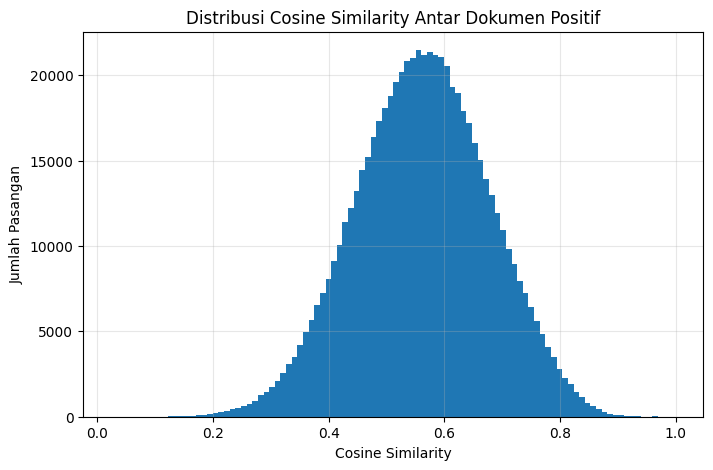

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Cosine similarity matrix
sim_matrix = cosine_similarity(embeddings_pos)

# Ambil hanya segitiga atas (tanpa diagonal)
similarities = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]

# Statistik
print(pd.Series(similarities).describe())

# Histogram
plt.figure(figsize=(8,5))
plt.hist(similarities, bins=100)
plt.xlabel("Cosine Similarity")
plt.ylabel("Jumlah Pasangan")
plt.title("Distribusi Cosine Similarity Antar Dokumen Positif")
plt.grid(alpha=0.3)
plt.show()

## 9. Visualisasi

### Intertopic

In [ ]:
import numpy as np

# ============================================================
# Definisi parameter untuk 4 kelompok (masing-masing 10 kombinasi)
# ============================================================

# HDBSCAN Positif — mulai dari rank 4 (skip 4 rank teratas yang cuma 2 topik trivial)
params_hdb_pos = [
    dict(min_cluster_size=30, min_samples=15, n_neighbors=15, n_components=5),   # rank 4
    dict(min_cluster_size=40, min_samples=15, n_neighbors=25, n_components=10),  # rank 5
    dict(min_cluster_size=50, min_samples=15, n_neighbors=15, n_components=5),   # rank 6
    dict(min_cluster_size=40, min_samples=15, n_neighbors=15, n_components=5),   # rank 7
    dict(min_cluster_size=40, min_samples=15, n_neighbors=25, n_components=5),   # rank 8
    dict(min_cluster_size=30, min_samples=15, n_neighbors=25, n_components=5),   # rank 9
    dict(min_cluster_size=50, min_samples=15, n_neighbors=25, n_components=10),  # rank 10
    dict(min_cluster_size=30, min_samples=10, n_neighbors=25, n_components=10),  # rank 11
    dict(min_cluster_size=40, min_samples=10, n_neighbors=25, n_components=10),  # rank 12
    dict(min_cluster_size=30, min_samples=15, n_neighbors=25, n_components=10),  # rank 13
]

# HDBSCAN Negatif — rank 0-9
params_hdb_neg = [
    dict(min_cluster_size=30, min_samples=15, n_neighbors=15, n_components=10),  # rank 0
    dict(min_cluster_size=40, min_samples=15, n_neighbors=15, n_components=10),  # rank 1
    dict(min_cluster_size=30, min_samples=10, n_neighbors=25, n_components=10),  # rank 2
    dict(min_cluster_size=30, min_samples=10, n_neighbors=15, n_components=10),  # rank 3
    dict(min_cluster_size=40, min_samples=10, n_neighbors=15, n_components=5),   # rank 4
    dict(min_cluster_size=50, min_samples=15, n_neighbors=15, n_components=10),  # rank 5
    dict(min_cluster_size=30, min_samples=15, n_neighbors=25, n_components=10),  # rank 6
    dict(min_cluster_size=30, min_samples=10, n_neighbors=15, n_components=5),   # rank 7
    dict(min_cluster_size=40, min_samples=15, n_neighbors=25, n_components=10),  # rank 8
    dict(min_cluster_size=30, min_samples=15, n_neighbors=15, n_components=5),   # rank 9
]

# OPTICS Positif — rank 0-9
params_opt_pos = [
    dict(min_cluster_size=40, min_samples=10, n_neighbors=25, n_components=5,  xi=0.05),  # rank 0
    dict(min_cluster_size=30, min_samples=15, n_neighbors=25, n_components=5,  xi=0.05),  # rank 1
    dict(min_cluster_size=30, min_samples=10, n_neighbors=15, n_components=10, xi=0.03),  # rank 2
    dict(min_cluster_size=40, min_samples=15, n_neighbors=25, n_components=10, xi=0.05),  # rank 3
    dict(min_cluster_size=30, min_samples=10, n_neighbors=15, n_components=10, xi=0.05),  # rank 4
    dict(min_cluster_size=40, min_samples=15, n_neighbors=25, n_components=5,  xi=0.05),  # rank 5
    dict(min_cluster_size=30, min_samples=15, n_neighbors=15, n_components=5,  xi=0.05),  # rank 6
    dict(min_cluster_size=30, min_samples=10, n_neighbors=15, n_components=5,  xi=0.05),  # rank 7
    dict(min_cluster_size=30, min_samples=15, n_neighbors=15, n_components=10, xi=0.05),  # rank 8
    dict(min_cluster_size=40, min_samples=15, n_neighbors=25, n_components=10, xi=0.03),  # rank 9
]

# OPTICS Negatif — rank 0-9
params_opt_neg = [
    dict(min_cluster_size=50, min_samples=15, n_neighbors=15, n_components=10, xi=0.05),  # rank 0
    dict(min_cluster_size=30, min_samples=10, n_neighbors=25, n_components=10, xi=0.03),  # rank 1
    dict(min_cluster_size=40, min_samples=10, n_neighbors=15, n_components=10, xi=0.05),  # rank 2
    dict(min_cluster_size=50, min_samples=10, n_neighbors=15, n_components=10, xi=0.05),  # rank 3
    dict(min_cluster_size=50, min_samples=10, n_neighbors=15, n_components=10, xi=0.03),  # rank 4
    dict(min_cluster_size=40, min_samples=15, n_neighbors=25, n_components=5,  xi=0.05),  # rank 5
    dict(min_cluster_size=40, min_samples=15, n_neighbors=15, n_components=10, xi=0.05),  # rank 6
    dict(min_cluster_size=30, min_samples=10, n_neighbors=25, n_components=5,  xi=0.05),  # rank 7
    dict(min_cluster_size=40, min_samples=10, n_neighbors=25, n_components=10, xi=0.03),  # rank 8
    dict(min_cluster_size=50, min_samples=10, n_neighbors=15, n_components=5,  xi=0.05),  # rank 9
]


# ============================================================
# Fungsi generic untuk generate & visualisasi
# ============================================================

def generate_intertopic_batch(params_list, fungsi_maker, docs, embeddings, label, start_rank=0):
    """
    Menjalankan fungsi_maker untuk tiap kombinasi parameter,
    lalu menampilkan intertopic distance map masing-masing.
    """
    hasil = {}

    for i, params in enumerate(params_list, start=start_rank):
        print(f"\n{'='*60}")
        print(f"Parameter ke-{i} — [{label}]")
        print(f"{'='*60}")
        print(f"min_cluster_size={params['min_cluster_size']}, "
              f"min_samples={params['min_samples']}, "
              f"n_neighbors={params['n_neighbors']}, "
              f"n_components={params['n_components']}"
              + (f", xi={params['xi']}" if 'xi' in params else ""))

        tm = fungsi_maker(**params)
        topics, _ = tm.fit_transform(docs, embeddings)

        n_out = int(np.sum(np.array(topics) == -1))
        pct_out = round(n_out / len(topics) * 100, 2)
        topic_words = get_topic_words(tm)
        n_topics = len(topic_words)
        cv_score = compute_c_v(tm, docs, tm.vectorizer_model)
        div_score = compute_diversity(topic_words)

        print(f"Hasil: Topik={n_topics}, Outlier={n_out} ({pct_out}%), "
              f"c_v={cv_score:.4f}, diversity={div_score:.4f}")

        hasil[f"rank_{i}"] = {
            "params": params,
            "model": tm,
            "topics": topics,
            "n_topics": n_topics,
            "outlier_pct": pct_out,
            "c_v": cv_score,
            "diversity": div_score,
        }

        print(f"\n>>> Visualisasi Parameter ke-{i} <<<")
        fig = tm.visualize_topics()
        fig.update_layout(
            title=f"{label} — Parameter ke-{i} | {n_topics} topik, outlier {pct_out}%, c_v={cv_score:.4f}"
        )
        fig.show()

        # opsional simpan ke file (butuh: pip install -U kaleido)
        # fig.write_image(f"intertopic_{label.replace(' ', '_')}_parameter{i}.png")

    return hasil


# ============================================================
# Jalankan untuk keempat kelompok
# ============================================================

results_hdb_pos = generate_intertopic_batch(
    params_hdb_pos, make_bertopic_hdbscan, docs_pos, embeddings_pos,
    label="HDBSCAN Positif", start_rank=4
)

results_hdb_neg = generate_intertopic_batch(
    params_hdb_neg, make_bertopic_hdbscan, docs_neg, embeddings_neg,
    label="HDBSCAN Negatif", start_rank=0
)

results_opt_pos = generate_intertopic_batch(
    params_opt_pos, make_bertopic_optics, docs_pos, embeddings_pos,
    label="OPTICS Positif", start_rank=0
)

results_opt_neg = generate_intertopic_batch(
    params_opt_neg, make_bertopic_optics, docs_neg, embeddings_neg,
    label="OPTICS Negatif", start_rank=0
)

2026-07-09 21:34:23,921 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



Parameter ke-4 — [HDBSCAN Positif]
min_cluster_size=30, min_samples=15, n_neighbors=15, n_components=5


2026-07-09 21:34:27,766 - BERTopic - Dimensionality - Completed ✓
2026-07-09 21:34:27,767 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-09 21:34:27,832 - BERTopic - Cluster - Completed ✓
2026-07-09 21:34:27,835 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-09 21:34:27,866 - BERTopic - Representation - Completed ✓


Hasil: Topik=7, Outlier=327 (28.73%), c_v=0.5461, diversity=0.9714

>>> Visualisasi Parameter ke-4 <<<


2026-07-09 21:34:28,479 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


...

Hasil: Topik=14, Outlier=2645 (76.01%), c_v=0.4936, diversity=0.9286

>>> Visualisasi Parameter ke-8 <<<


2026-07-09 21:44:37,145 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



Parameter ke-9 — [OPTICS Negatif]
min_cluster_size=50, min_samples=10, n_neighbors=15, n_components=5, xi=0.05


2026-07-09 21:44:58,595 - BERTopic - Dimensionality - Completed ✓
2026-07-09 21:44:58,597 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-09 21:45:02,447 - BERTopic - Cluster - Completed ✓
2026-07-09 21:45:02,452 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-09 21:45:02,532 - BERTopic - Representation - Completed ✓


Hasil: Topik=7, Outlier=2976 (85.52%), c_v=0.4935, diversity=1.0000

>>> Visualisasi Parameter ke-9 <<<


### HDBSCAN Positif

#### Intertopic

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Ambil figure Intertopic Distance Map bawaan BERTopic
fig_map = topic_model_pos_hdbscan.visualize_topics()

# 2. Ambil SELURUH data info topik (termasuk Outlier -1)
df_info = topic_model_pos_hdbscan.get_topic_info()

# Pisahkan topik resmi khusus untuk menghitung palet warna peta kiri
df_resmi = (
    df_info[df_info["Topic"] != -1].sort_values("Topic").reset_index(drop=True)
)
jumlah_resmi = len(df_resmi)

# 3. Siapkan palet warna topik resmi
palet_warna = px.colors.qualitative.Alphabet + px.colors.qualitative.Set1
warna_resmi = (palet_warna * (jumlah_resmi // len(palet_warna) + 1))[
    :jumlah_resmi
]

# Kamus pemetaan warna {ID_Topik: Warna}. Khusus Topik -1 dikunci warna Abu-abu
map_warna = dict(zip(df_resmi["Topic"], warna_resmi))
map_warna[-1] = "#808080"

# 4. Buat kanvas 1 Baris, 2 Kolom
fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.55, 0.45],
    horizontal_spacing=0.08,
)

# 5. Pindahkan komponen peta Intertopic ke kolom kiri (col=1)
for trace in fig_map.data:
    fig.add_trace(trace, row=1, col=1)

# Suntikkan warna hanya ke marker lingkaran resmi
fig.data[0].marker.color = warna_resmi

# 6. Siapkan data Barchart Frekuensi (Semua topik ikut terangkut)
df_bar = df_info.sort_values("Count", ascending=True)
warna_bar = [map_warna[t] for t in df_bar["Topic"]]

# Ubah teks label "-1" menjadi "Outlier (-1)"
label_y = [
    "Outlier (-1)" if t == -1 else f"Topik {t}" for t in df_bar["Topic"]
]

trace_bar = go.Bar(
    x=df_bar["Count"],
    y=label_y,
    orientation="h",
    marker=dict(color=warna_bar),
    text=df_bar["Count"],
    textposition="auto",
    hoverinfo="x+y",
)
fig.add_trace(trace_bar, row=1, col=2)

# --- BAGIAN KUADRAN DI TENGAH PETA INTERTOPIC ---
x_coords = fig.data[0].x
y_coords = fig.data[0].y

tengah_x = (max(x_coords) + min(x_coords)) / 2
tengah_y = (max(y_coords) + min(y_coords)) / 2

# Garis Kuadran Vertikal
fig.add_shape(
    type="line",
    x0=tengah_x, x1=tengah_x,
    y0=min(y_coords), y1=max(y_coords),
    line=dict(color="lightgrey", width=1.5),
    row=1, col=1,
)

# Garis Kuadran Horizontal
fig.add_shape(
    type="line",
    x0=min(x_coords), x1=max(x_coords),
    y0=tengah_y, y1=tengah_y,
    line=dict(color="lightgrey", width=1.5),
    row=1, col=1,
)

# --- PENAMBAHAN TEKS D1, D2, D3, D4 DI POJOK UJUNG GARIS ---
font_kuadran = dict(size=13, color="#606060", family="Arial")

# Ujung Atas -> D1
fig.add_annotation(
    x=tengah_x, y=max(y_coords), text="<b>D1</b>",
    showarrow=False, xanchor="center", yanchor="bottom",
    yshift=8, font=font_kuadran, row=1, col=1
)

# Ujung Kiri -> D4
fig.add_annotation(
    x=min(x_coords), y=tengah_y, text="<b>D2</b>",
    showarrow=False, xanchor="right", yanchor="middle",
    xshift=-8, font=font_kuadran, row=1, col=1
)

# 7. Pengaturan Layout Umum
fig.update_layout(
    title_text="",
    height=600,
    width=1100,
    template="plotly_white",
    showlegend=False,
)

fig.update_xaxes(
    showgrid=False, zeroline=False, showticklabels=False, row=1, col=1
)
fig.update_yaxes(
    showgrid=False, zeroline=False, showticklabels=False, row=1, col=1
)

fig.update_xaxes(title_text="frequency", row=1, col=2)

fig.show()

In [ ]:
import bertopic
print(bertopic.__version__)

0.17.4


#### WC

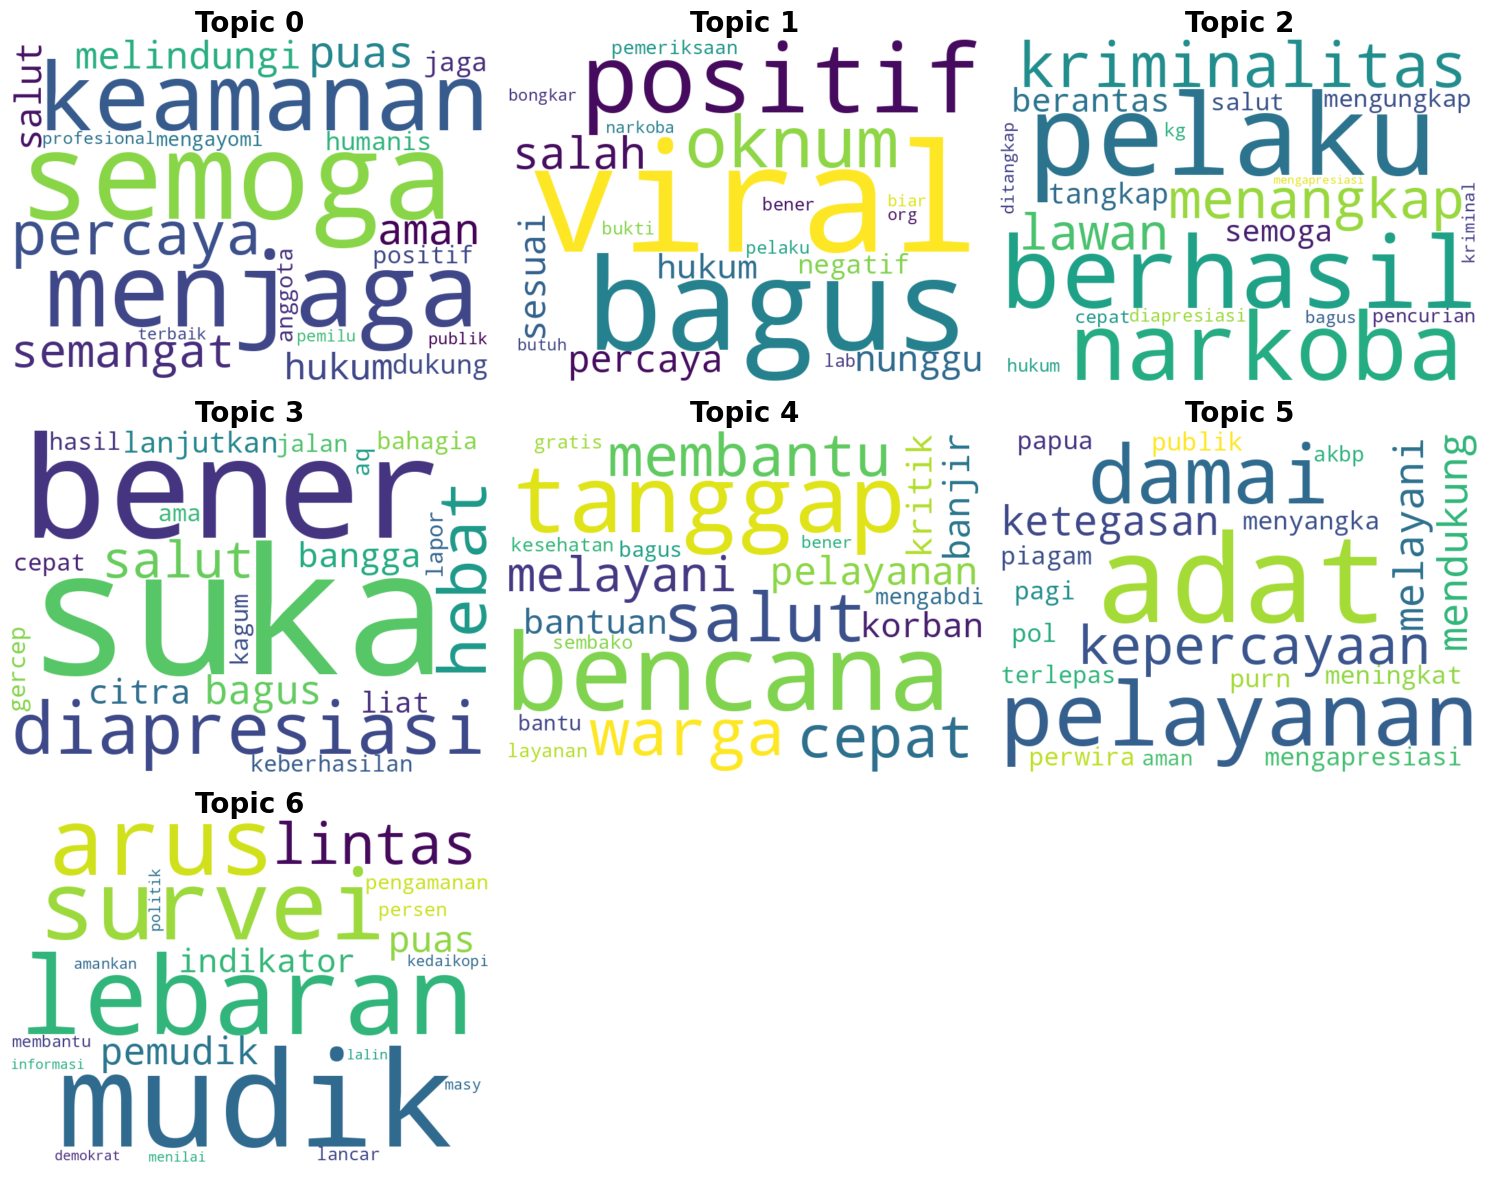

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import math

tm = topic_model_pos_hdbscan
docs = docs_pos
topics = topics_pos_hdb
n_words = 20

# CountVectorizer yang digunakan BERTopic
vectorizer = tm.vectorizer_model
vocab = vectorizer.get_feature_names_out()

# Daftar topik (tanpa outlier)
topic_info = tm.get_topic_info()
topic_ids = topic_info.loc[topic_info["Topic"] != -1, "Topic"].tolist()

n_cols = 3
n_rows = math.ceil(len(topic_ids) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)

if len(topic_ids) == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, tid in enumerate(topic_ids):

    # Ambil seluruh dokumen pada topik tersebut
    topic_docs = [
        doc for doc, topic in zip(docs, topics)
        if topic == tid
    ]

    if len(topic_docs) == 0:
        axes[i].axis("off")
        continue

    # Hitung frekuensi menggunakan CountVectorizer asli BERTopic
    X = vectorizer.transform(topic_docs)
    counts = X.sum(axis=0).A1

    # Dictionary kata -> frekuensi
    freq = dict(zip(vocab, counts))

    # Hapus kata dengan frekuensi 0
    freq = {k: v for k, v in freq.items() if v > 0}

    # Ambil n kata dengan frekuensi tertinggi
    freq = dict(
        sorted(freq.items(), key=lambda x: x[1], reverse=True)[:n_words]
    )

    wc = WordCloud(
        width=700,
        height=500,
        background_color="white",
        colormap="viridis",
        max_words=n_words,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(freq)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(
        f"Topic {tid}",
        fontsize=20,
        fontweight="bold"
    )
    axes[i].axis("off")

# Matikan subplot yang tidak terpakai
for j in range(len(topic_ids), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

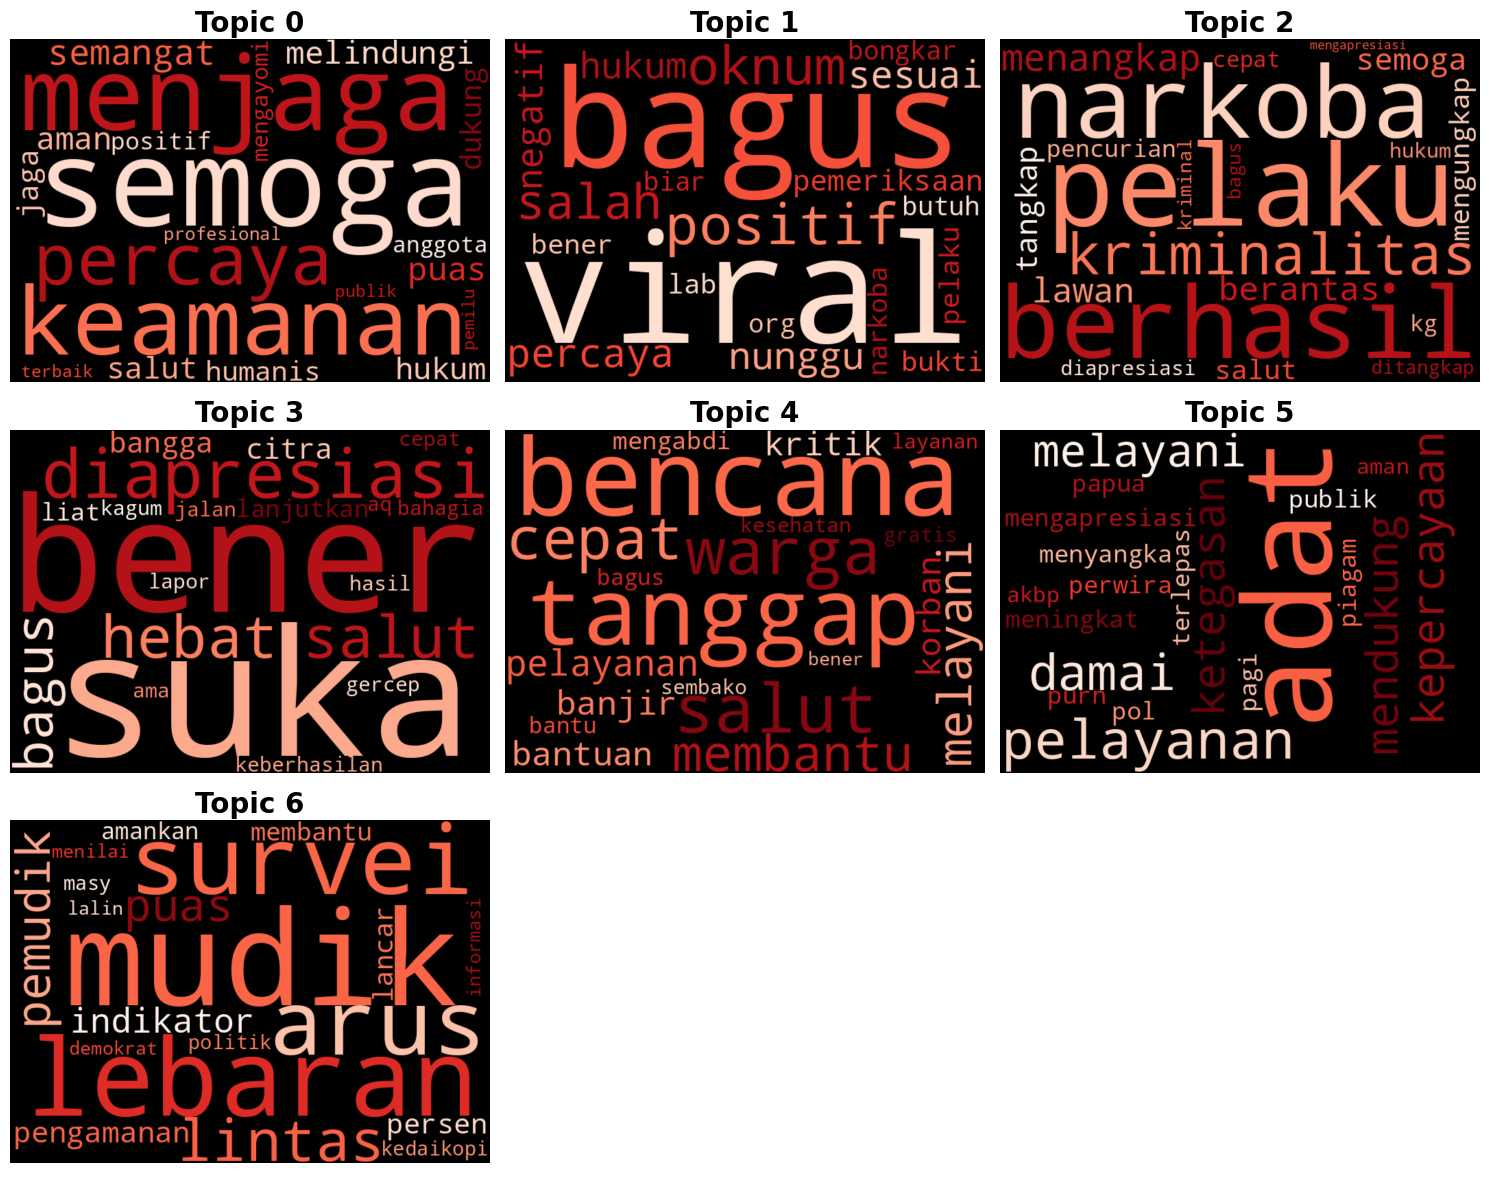

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import math

tm = topic_model_pos_hdbscan
docs = docs_pos
topics = topics_pos_hdb
n_words = 20

# CountVectorizer yang digunakan BERTopic
vectorizer = tm.vectorizer_model
vocab = vectorizer.get_feature_names_out()

# Daftar topik (tanpa outlier)
topic_info = tm.get_topic_info()
topic_ids = topic_info.loc[topic_info["Topic"] != -1, "Topic"].tolist()

n_cols = 3
n_rows = math.ceil(len(topic_ids) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)
fig.patch.set_facecolor("white")

if len(topic_ids) == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, tid in enumerate(topic_ids):

    axes[i].set_facecolor("white")

    # Ambil seluruh dokumen pada topik tersebut
    topic_docs = [
        doc for doc, topic in zip(docs, topics)
        if topic == tid
    ]

    if len(topic_docs) == 0:
        axes[i].axis("off")
        continue

    # Hitung frekuensi menggunakan CountVectorizer asli BERTopic
    X = vectorizer.transform(topic_docs)
    counts = X.sum(axis=0).A1

    # Dictionary kata -> frekuensi
    freq = dict(zip(vocab, counts))

    # Hapus kata dengan frekuensi 0
    freq = {k: v for k, v in freq.items() if v > 0}

    # Ambil n kata dengan frekuensi tertinggi
    freq = dict(
        sorted(freq.items(), key=lambda x: x[1], reverse=True)[:n_words]
    )

    wc = WordCloud(
        width=700,
        height=500,
        background_color="black",
        colormap="Reds",
        max_words=n_words,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(freq)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(
        f"Topic {tid}",
        fontsize=20,
        fontweight="bold",
        color="black"
    )
    axes[i].axis("off")

# Matikan subplot yang tidak terpakai
for j in range(len(topic_ids), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from bertopic import BERTopic

# Load model
topic_model_pos_hdbscan = BERTopic.load("drive/MyDrive/Tugas Akhir/bertopic/pos_hdbscan")
topic_model_neg_hdbscan = BERTopic.load("drive/MyDrive/Tugas Akhir/bertopic/neg_hdbscan")

# Cek
print(topic_model_pos_hdbscan.get_topic_info())

2026-07-22 17:04:27,741 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.
2026-07-22 17:04:31,844 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.


   Topic  Count                                    Name  \
0     -1    269      -1_polisi_kinerja_polri_masyarakat   
1      0    224    0_kinerja_polisi_bencana_terimakasih   
2      1    159       1_polisi_kinerja_narkoba_berantas   
3      2    158             2_polisi_kinerja_viral_kalo   
4      3    126       3_masyarakat_kinerja_polisi_polri   
5      4     74            4_polisi_kinerja_percaya_tau   
6      5     50  5_penghargaan_prabowo_kapolri_jenderal   
7      6     39           6_mudik_survei_lebaran_lintas   

                                                                                   Representation  \
0    [polisi, kinerja, polri, masyarakat, apresiasi, banget, orangnya, kepolisian, bagus, semoga]   
1            [kinerja, polisi, bencana, terimakasih, tanggap, polri, cepat, salut, banget, kasih]   
2  [polisi, kinerja, narkoba, berantas, pelaku, kriminalitas, berhasil, lawan, apresiasi, mantap]   
3              [polisi, kinerja, viral, kalo, oknum, positif, or

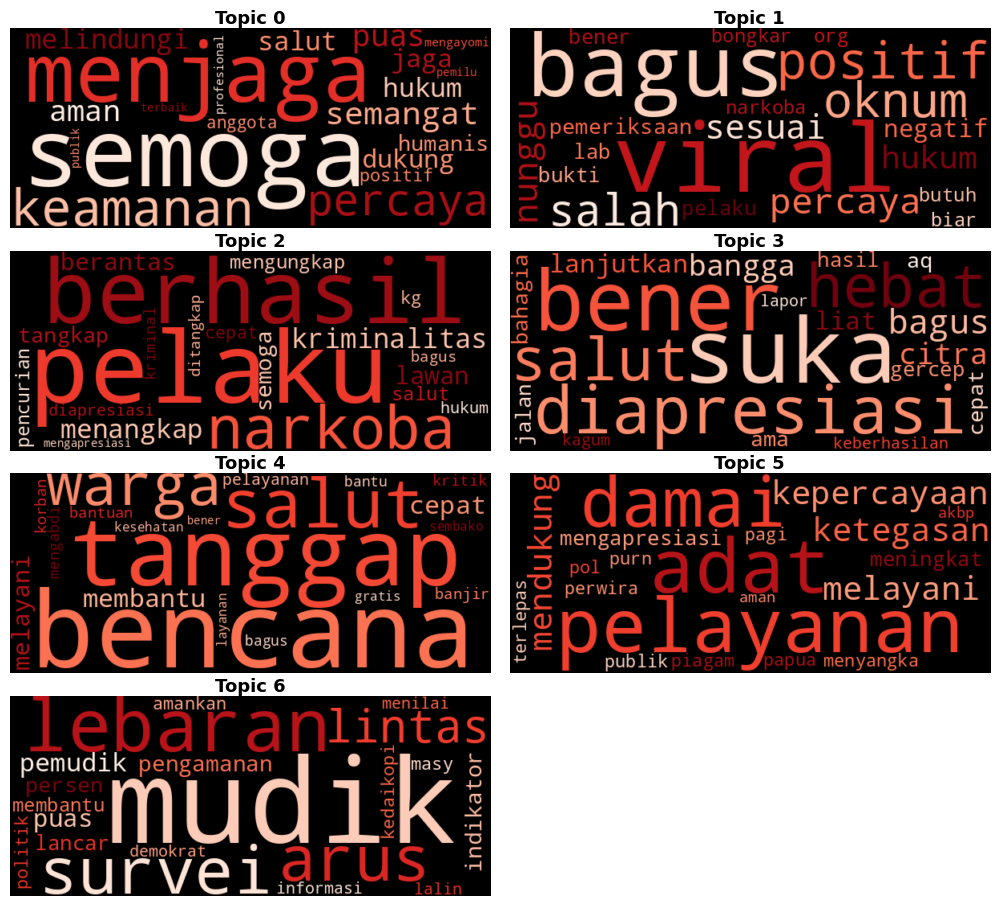

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math

tm = topic_model_pos_hdbscan
docs = docs_pos
topics = topics_pos_hdb
n_words = 20

vectorizer = tm.vectorizer_model
vocab = vectorizer.get_feature_names_out()

topic_info = tm.get_topic_info()
topic_ids = topic_info.loc[topic_info["Topic"] != -1, "Topic"].tolist()

n_cols = 2
n_rows = math.ceil(len(topic_ids) / n_cols)

fig = plt.figure(figsize=(10, 2.3 * n_rows), facecolor="white")
gs = gridspec.GridSpec(
    n_rows, n_cols,
    figure=fig,
    hspace=0.08,
    wspace=0.04,
    top=0.96,
    bottom=0.01,
    left=0.01,
    right=0.99
)

for i, tid in enumerate(topic_ids):
    row, col = divmod(i, n_cols)
    ax = fig.add_subplot(gs[row, col])
    ax.set_facecolor("black")

    topic_docs = [
        doc for doc, topic in zip(docs, topics)
        if topic == tid
    ]

    if len(topic_docs) == 0:
        ax.axis("off")
        continue

    X = vectorizer.transform(topic_docs)
    counts = X.sum(axis=0).A1
    freq = dict(zip(vocab, counts))
    freq = {k: v for k, v in freq.items() if v > 0}
    freq = dict(
        sorted(freq.items(), key=lambda x: x[1], reverse=True)[:n_words]
    )

    wc = WordCloud(
        width=600,
        height=250,
        background_color="black",
        colormap="Reds",
        max_words=n_words,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(freq)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(
        f"Topic {tid}",
        fontsize=13,
        fontweight="bold",
        color="black",
        pad=3
    )
    ax.axis("off")

plt.savefig(
    "wordcloud_pos_hdbscan.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

#### Hierarchy

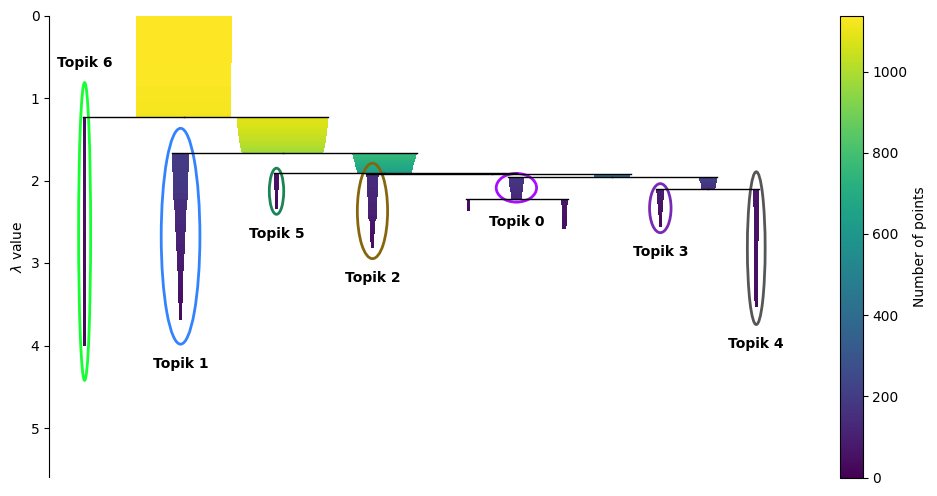

In [ ]:
import re
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import plotly.express as px

df_info = topic_model_pos_hdbscan.get_topic_info()
df_resmi = (
    df_info[df_info["Topic"] != -1].sort_values("Topic").reset_index(drop=True)
)
jumlah_resmi = len(df_resmi)

palet_raw = px.colors.qualitative.Alphabet + px.colors.qualitative.Set1
warna_resmi = (palet_raw * (jumlah_resmi // len(palet_raw) + 1))[
    :jumlah_resmi
]

map_warna_bertopic = dict(zip(df_resmi["Topic"], warna_resmi))

hdb_labels = topic_model_pos_hdbscan.hdbscan_model.labels_
ber_labels = topic_model_pos_hdbscan.topics_

map_hdb_ke_ber = dict(zip(hdb_labels, ber_labels))

if -1 in map_hdb_ke_ber:
    del map_hdb_ke_ber[-1]


def konversi_ke_rgb(c):
    if str(c).startswith("rgb"):
        return tuple(int(x) / 255.0 for x in re.findall(r"\d+", str(c))[:3])
    return mcolors.to_rgb(c)


urutan_hdb = sorted(map_hdb_ke_ber.keys())
palet_hdbscan = [
    konversi_ke_rgb(map_warna_bertopic[map_hdb_ke_ber[h]]) for h in urutan_hdb
]

mesin_hdbscan = topic_model_pos_hdbscan.hdbscan_model

fig, ax = plt.subplots(figsize=(12, 6))

mesin_hdbscan.condensed_tree_.plot(
    select_clusters=True,
    label_clusters=False,
    selection_palette=palet_hdbscan,
    axis=ax,
)

ellipses = [p for p in ax.patches if isinstance(p, Ellipse)]

for i, el in enumerate(ellipses):
    if i < len(urutan_hdb):
        id_bertopic = map_hdb_ke_ber[urutan_hdb[i]]
        warna_topik = map_warna_bertopic[id_bertopic]
        el.set_width(el.width + 65)
        el.set_height(el.height * 1.08)

        cx, cy = el.center

        if id_bertopic == 6:
            y_teks = cy - (el.height / 2.0)
            jarak_dorong = 9
            posisi_jangkar = "bottom"
        else:
            y_teks = cy + (el.height / 2.0)
            jarak_dorong = -9
            posisi_jangkar = "top"

        ax.annotate(
            f"Topik {id_bertopic}",
            xy=(cx, y_teks),
            xytext=(0, jarak_dorong),
            textcoords="offset points",
            ha="center",
            va=posisi_jangkar,
            fontsize=10,
            fontweight="bold",
            color="#000000",
            bbox=dict(
                boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85
            )
        )

ax.set_ylim(bottom=5.6)

plt.show()

#### UMAP

In [ ]:
def plot_bertopic_docs(tm, docs, embeddings, label):
    reduced = UMAP(
        n_neighbors=15, n_components=5,
        min_dist=0.05, metric='cosine',
        random_state=42, n_jobs=1
    ).fit_transform(embeddings)

    topic_ids = [tid for tid in tm.get_topics().keys()]
    custom_labels = {tid: ("Outlier" if tid == -1 else str(tid)) for tid in topic_ids}
    tm.set_topic_labels(custom_labels)

    df_info = tm.get_topic_info()
    df_resmi = df_info[df_info["Topic"] != -1].sort_values("Topic").reset_index(drop=True)
    jumlah_resmi = len(df_resmi)

    palet_warna = px.colors.qualitative.Alphabet + px.colors.qualitative.Set1
    warna_resmi = (palet_warna * (jumlah_resmi // len(palet_warna) + 1))[:jumlah_resmi]

    map_warna = dict(zip(df_resmi["Topic"], warna_resmi))
    map_warna[-1] = "#808080"

    if 8 in map_warna:
        map_warna[8] = "#FF00FF"

    fig = tm.visualize_documents(
        docs,
        reduced_embeddings=reduced,
        custom_labels=True,
        hide_annotations=True,
        title=label,
    )

    for trace in fig.data:
        tid_str = trace.name
        try:
            tid = -1 if tid_str == "Outlier" else int(tid_str)
        except (ValueError, TypeError):
            continue
        warna = map_warna.get(tid)
        if warna:
            trace.marker.color = warna
        trace.showlegend = True

    fig.update_layout(
        legend=dict(font=dict(size=18)),
        font=dict(size=14),
    )

    fig.show()


plot_bertopic_docs(topic_model_pos_hdbscan, docs_pos, embeddings_pos, "Positif — HDBSCAN")

#### CTF-IDF

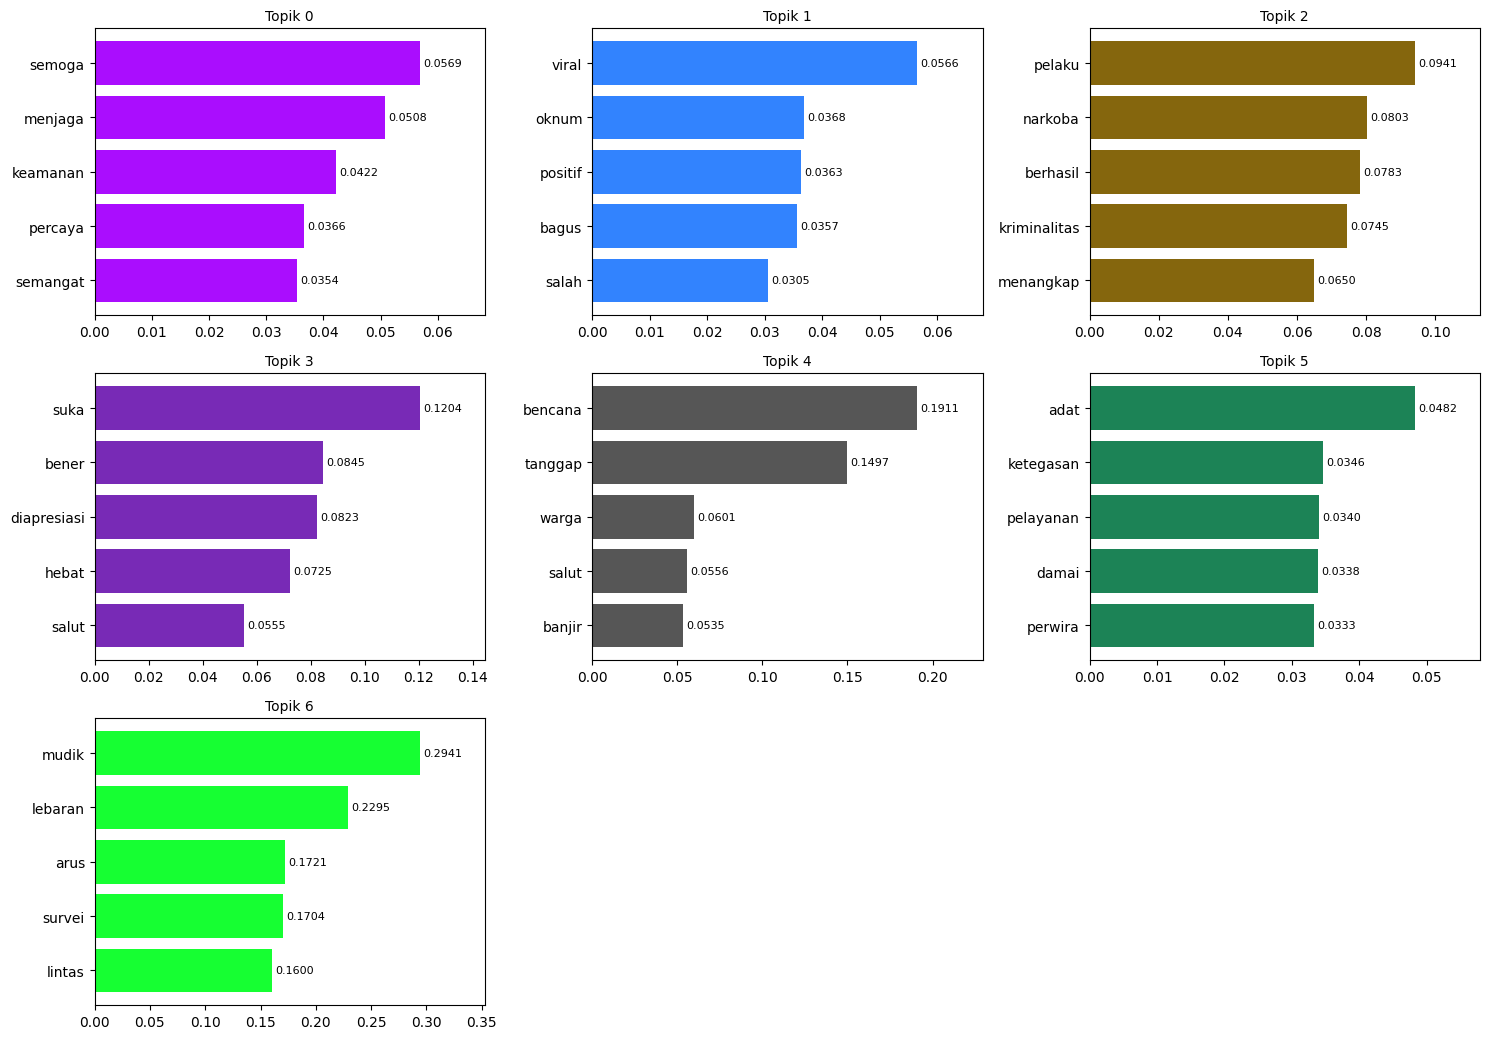

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px

topic_model = topic_model_pos_hdbscan
top_n = 5

df_info = topic_model.get_topic_info()
df_resmi = df_info[df_info["Topic"] != -1].sort_values("Topic").reset_index(drop=True)
jumlah_resmi = len(df_resmi)

palet_warna = px.colors.qualitative.Alphabet + px.colors.qualitative.Set1
warna_resmi = (palet_warna * (jumlah_resmi // len(palet_warna) + 1))[:jumlah_resmi]

map_warna = dict(zip(df_resmi["Topic"], warna_resmi))
map_warna[-1] = "#808080"

topic_ids = [tid for tid in sorted(topic_model.get_topics().keys()) if tid != -1]
n = len(topic_ids)
ncols = 3
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
axes = axes.flatten()

for ax, tid in zip(axes, topic_ids):
    words_scores = topic_model.get_topic(tid)[:top_n]
    words  = [w for w, _ in words_scores][::-1]
    scores = [s for _, s in words_scores][::-1]

    warna_topik = map_warna[tid]
    bars = ax.barh(words, scores, color=warna_topik)
    for bar, score in zip(bars, scores):
        ax.text(
            bar.get_width() + max(scores) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.4f}",
            va="center", ha="left", fontsize=8
        )
    ax.set_title(f"Topik {tid}", fontsize=10)
    ax.set_xlim(0, max(scores) * 1.2)

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("ctfidf_semua_topik.png", dpi=300, bbox_inches="tight")
plt.show()

#### Topic Overtime

In [ ]:
import pandas as pd

data_pos["created_at"] = pd.to_datetime(data_pos["created_at"], format="%Y-%m-%d")
data_neg["created_at"] = pd.to_datetime(data_neg["created_at"], format="%Y-%m-%d")

# Bulatkan tanggal ke awal bulan (misal 2023-07-15 -> 2023-07-01)
data_pos["year_month"] = data_pos["created_at"].dt.to_period("M").dt.to_timestamp()
data_neg["year_month"] = data_neg["created_at"].dt.to_period("M").dt.to_timestamp()

assert len(docs_pos) == len(data_pos) == len(topics_pos_hdb), "Panjang data positif tidak cocok!"
assert len(docs_neg) == len(data_neg) == len(topics_neg_hdb), "Panjang data negatif tidak cocok!"


topics_over_time_pos_full = topic_model_pos_hdbscan.topics_over_time(
    docs=docs_pos,
    timestamps=data_pos["year_month"].tolist()
)

tot_pos_p1 = topics_over_time_pos_full[
    (topics_over_time_pos_full["Timestamp"] >= "2023-07-01") &
    (topics_over_time_pos_full["Timestamp"] <= "2024-09-30")
].reset_index(drop=True)

tot_pos_p2 = topics_over_time_pos_full[
    topics_over_time_pos_full["Timestamp"] >= "2024-10-01"
].reset_index(drop=True)

print(f"Positif periode 1: {tot_pos_p1.shape[0]} baris | rentang bulan: {tot_pos_p1['Timestamp'].min()} - {tot_pos_p1['Timestamp'].max()}")
print(f"Positif periode 2: {tot_pos_p2.shape[0]} baris | rentang bulan: {tot_pos_p2['Timestamp'].min()} - {tot_pos_p2['Timestamp'].max()}")

fig_pos_p1 = topic_model_pos_hdbscan.visualize_topics_over_time(tot_pos_p1, top_n_topics=9)
fig_pos_p1.show()

fig_pos_p2 = topic_model_pos_hdbscan.visualize_topics_over_time(tot_pos_p2, top_n_topics=9)
fig_pos_p2.show()


topics_over_time_neg_full = topic_model_neg_hdbscan.topics_over_time(
    docs=docs_neg,
    timestamps=data_neg["year_month"].tolist()
)

tot_neg_p1 = topics_over_time_neg_full[
    (topics_over_time_neg_full["Timestamp"] >= "2023-07-01") &
    (topics_over_time_neg_full["Timestamp"] <= "2024-09-30")
].reset_index(drop=True)

tot_neg_p2 = topics_over_time_neg_full[
    topics_over_time_neg_full["Timestamp"] >= "2024-10-01"
].reset_index(drop=True)

print(f"Negatif periode 1: {tot_neg_p1.shape[0]} baris | rentang bulan: {tot_neg_p1['Timestamp'].min()} - {tot_neg_p1['Timestamp'].max()}")
print(f"Negatif periode 2: {tot_neg_p2.shape[0]} baris | rentang bulan: {tot_neg_p2['Timestamp'].min()} - {tot_neg_p2['Timestamp'].max()}")

fig_neg_p1 = topic_model_neg_hdbscan.visualize_topics_over_time(tot_neg_p1, top_n_topics=10)
fig_neg_p1.show()

fig_neg_p2 = topic_model_neg_hdbscan.visualize_topics_over_time(tot_neg_p2, top_n_topics=10)
fig_neg_p2.show()

30it [00:00, 71.12it/s]

Positif periode 1: 91 baris | rentang bulan: 2023-07-01 00:00:00 - 2024-09-01 00:00:00
Positif periode 2: 100 baris | rentang bulan: 2024-10-01 00:00:00 - 2025-12-01 00:00:00


30it [00:00, 37.70it/s]


Negatif periode 1: 116 baris | rentang bulan: 2023-07-01 00:00:00 - 2024-09-01 00:00:00
Negatif periode 2: 125 baris | rentang bulan: 2024-10-01 00:00:00 - 2025-12-01 00:00:00


In [ ]:
import pandas as pd
import plotly.graph_objects as go

data_pos["created_at"] = pd.to_datetime(data_pos["created_at"], format="%Y-%m-%d")
data_neg["created_at"] = pd.to_datetime(data_neg["created_at"], format="%Y-%m-%d")

data_pos["year_month"] = data_pos["created_at"].dt.to_period("M").dt.to_timestamp()
data_neg["year_month"] = data_neg["created_at"].dt.to_period("M").dt.to_timestamp()

assert len(docs_pos) == len(data_pos) == len(topics_pos_hdb), "Panjang data positif tidak cocok!"
assert len(docs_neg) == len(data_neg) == len(topics_neg_hdb), "Panjang data negatif tidak cocok!"

pos_labels = topic_model_pos_hdbscan.generate_topic_labels(nr_words=5, topic_prefix=True, separator=" - ")
topic_model_pos_hdbscan.set_topic_labels(pos_labels)

neg_labels = topic_model_neg_hdbscan.generate_topic_labels(nr_words=5, topic_prefix=True, separator=" - ")
topic_model_neg_hdbscan.set_topic_labels(neg_labels)

tgl_pelantikan = "2024-10-20"

# --- Positif ---
topics_over_time_pos = topic_model_pos_hdbscan.topics_over_time(
    docs=docs_pos,
    timestamps=data_pos["year_month"].tolist()
)

fig_pos = topic_model_pos_hdbscan.visualize_topics_over_time(
    topics_over_time_pos, top_n_topics=9, custom_labels=True
)

fig_pos.update_layout(legend_title_text="")

for trace in fig_pos.data:
    if trace.hovertemplate:
        trace.hovertemplate = trace.hovertemplate.replace("Global Topic Representation<br>", "")
    if trace.name:
        trace.name = trace.name.replace("Global Topic Representation<br>", "")

fig_pos.add_vline(
    x=tgl_pelantikan,
    line_width=3, line_dash="dash", line_color="black"
)
fig_pos.add_trace(go.Scatter(
    x=[None], y=[None],
    mode="lines",
    line=dict(color="black", width=3, dash="dash"),
    name="Pelantikan Prabowo",
    showlegend=True
))

fig_pos.show()

# --- Negatif ---
topics_over_time_neg = topic_model_neg_hdbscan.topics_over_time(
    docs=docs_neg,
    timestamps=data_neg["year_month"].tolist()
)

fig_neg = topic_model_neg_hdbscan.visualize_topics_over_time(
    topics_over_time_neg, top_n_topics=10, custom_labels=True
)

fig_neg.update_layout(legend_title_text="")

for trace in fig_neg.data:
    if trace.hovertemplate:
        trace.hovertemplate = trace.hovertemplate.replace("Global Topic Representation<br>", "")
    if trace.name:
        trace.name = trace.name.replace("Global Topic Representation<br>", "")

fig_neg.add_vline(
    x=tgl_pelantikan,
    line_width=3, line_dash="dash", line_color="black"
)
fig_neg.add_trace(go.Scatter(
    x=[None], y=[None],
    mode="lines",
    line=dict(color="black", width=3, dash="dash"),
    name="Pelantikan Prabowo",
    showlegend=True
))

fig_neg.show()

30it [00:00, 70.20it/s]


30it [00:00, 37.37it/s]


In [ ]:
import pandas as pd

data_pos["created_at"] = pd.to_datetime(data_pos["created_at"], format="%Y-%m-%d")
data_neg["created_at"] = pd.to_datetime(data_neg["created_at"], format="%Y-%m-%d")

# Bulatkan tanggal ke awal bulan (misal 2023-07-15 -> 2023-07-01)
data_pos["year_month"] = data_pos["created_at"].dt.to_period("M").dt.to_timestamp()
data_neg["year_month"] = data_neg["created_at"].dt.to_period("M").dt.to_timestamp()

assert len(docs_pos) == len(data_pos) == len(topics_pos_hdb), "Panjang data positif tidak cocok!"
assert len(docs_neg) == len(data_neg) == len(topics_neg_hdb), "Panjang data negatif tidak cocok!"

# ===== CUSTOM LABELS INTERPRETASI =====
# Dictionary untuk mapping Topic ID ke teks Interpretasi Topik
custom_labels_pos = {
    0: "0_Doa dan dukungan publik agar polisi menjaga keamanan",
    1: "1_Kinerja kepolisian tanpa harus menunggu kasus viral",
    2: "2_Keberhasilan menangkap pengedar narkoba & lawan kriminalitas",
    3: "3_Apresiasi dan kekaguman umum atas kinerja polisi",
    4: "4_Tanggap darurat membantu warga terdampak bencana",
    5: "5_Penghargaan adat dan ketegasan kepemimpinan Polri",
    6: "6_Survei pemudik puas dengan kinerja Polisi Lalu Lintas"
}

custom_labels_neg = {
    0: "0_Tuntutan reformasi hukum dan perbaikan citra institusi",
    1: "1_Membandingkan kepolisian Indonesia dengan negara lain",
    2: "2_Kritik anggaran dan gaji polisi dari pajak masyarakat",
    3: "3_Hancurnya kepercayaan publik terhadap kinerja kepolisian",
    4: "4_Kinerja polisi buruk dan memalukan secara general",
    5: "5_Kritik penanganan kasus yang baru bergerak setelah viral",
    6: "6_Sorotan kejanggalan penanganan kasus pembunuhan",
    7: "7_Skeptisisme validitas survei kepuasan kinerja polisi"
}

topic_model_pos_hdbscan.set_topic_labels(custom_labels_pos)
topic_model_neg_hdbscan.set_topic_labels(custom_labels_neg)

tgl_pelantikan = "2024-10-20"


topics_over_time_pos = topic_model_pos_hdbscan.topics_over_time(
    docs=docs_pos,
    timestamps=data_pos["year_month"].tolist()
)

fig_pos = topic_model_pos_hdbscan.visualize_topics_over_time(
    topics_over_time_pos, top_n_topics=7, custom_labels=True
)

fig_pos.update_layout(legend_title_text="")

for trace in fig_pos.data:
    if trace.hovertemplate:
        trace.hovertemplate = trace.hovertemplate.replace("Global Topic Representation<br>", "")
    if trace.name:
        trace.name = trace.name.replace("Global Topic Representation<br>", "")

fig_pos.add_vline(
    x=tgl_pelantikan,
    line_width=3,
    line_dash="dash",
    line_color="black"
)
fig_pos.add_annotation(
    x=tgl_pelantikan,
    y=1.0,
    yref="paper",
    text="Pelantikan Prabowo",
    showarrow=False,
    textangle=-90,
    xanchor="right",
    font=dict(color="black", size=11)
)

fig_pos.show()

topics_over_time_neg = topic_model_neg_hdbscan.topics_over_time(
    docs=docs_neg,
    timestamps=data_neg["year_month"].tolist()
)

fig_neg = topic_model_neg_hdbscan.visualize_topics_over_time(
    topics_over_time_neg, top_n_topics=8, custom_labels=True
)

fig_neg.update_layout(legend_title_text="")

for trace in fig_neg.data:
    if trace.hovertemplate:
        trace.hovertemplate = trace.hovertemplate.replace("Global Topic Representation<br>", "")
    if trace.name:
        trace.name = trace.name.replace("Global Topic Representation<br>", "")

fig_neg.add_vline(
    x=tgl_pelantikan,
    line_width=3,
    line_dash="dash",
    line_color="black"
)
fig_neg.add_annotation(
    x=tgl_pelantikan,
    y=1.0,
    yref="paper",
    text="Pelantikan Prabowo",
    showarrow=False,
    textangle=-90,
    xanchor="right",
    font=dict(color="black", size=11)
)

fig_neg.show()

30it [00:00, 75.22it/s]


30it [00:00, 38.14it/s]


### HDBSCAN Negatif

#### Intertopic

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Ambil figure Intertopic Distance Map bawaan BERTopic
fig_map = topic_model_neg_hdbscan.visualize_topics()

# 2. Ambil SELURUH data info topik (termasuk Outlier -1)
df_info = topic_model_neg_hdbscan.get_topic_info()

# Pisahkan topik resmi khusus untuk menghitung palet warna peta kiri
df_resmi = (
    df_info[df_info["Topic"] != -1].sort_values("Topic").reset_index(drop=True)
)
jumlah_resmi = len(df_resmi)

# 3. Siapkan palet warna topik resmi
palet_warna = px.colors.qualitative.Alphabet + px.colors.qualitative.Set1
warna_resmi = (palet_warna * (jumlah_resmi // len(palet_warna) + 1))[
    :jumlah_resmi
]

# Kamus pemetaan warna {ID_Topik: Warna}. Khusus Topik -1 dikunci warna Abu-abu
map_warna = dict(zip(df_resmi["Topic"], warna_resmi))
map_warna[-1] = "#808080"

# 4. Buat kanvas 1 Baris, 2 Kolom
fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.55, 0.45],
    horizontal_spacing=0.08,
)

# 5. Pindahkan komponen peta Intertopic ke kolom kiri (col=1)
for trace in fig_map.data:
    fig.add_trace(trace, row=1, col=1)

# Suntikkan warna hanya ke marker lingkaran resmi
fig.data[0].marker.color = warna_resmi

# 6. Siapkan data Barchart Frekuensi (Semua topik ikut terangkut)
df_bar = df_info.sort_values("Count", ascending=True)
warna_bar = [map_warna[t] for t in df_bar["Topic"]]

# Ubah teks label "-1" menjadi "Outlier (-1)"
label_y = [
    "Outlier (-1)" if t == -1 else f"Topik {t}" for t in df_bar["Topic"]
]

trace_bar = go.Bar(
    x=df_bar["Count"],
    y=label_y,
    orientation="h",
    marker=dict(color=warna_bar),
    text=df_bar["Count"],
    textposition="auto",
    hoverinfo="x+y",
)
fig.add_trace(trace_bar, row=1, col=2)

# --- BAGIAN KUADRAN DI TENGAH PETA INTERTOPIC ---
x_coords = fig.data[0].x
y_coords = fig.data[0].y

tengah_x = (max(x_coords) + min(x_coords)) / 2
tengah_y = (max(y_coords) + min(y_coords)) / 2

# Garis Kuadran Vertikal
fig.add_shape(
    type="line",
    x0=tengah_x, x1=tengah_x,
    y0=min(y_coords), y1=max(y_coords),
    line=dict(color="lightgrey", width=1.5),
    row=1, col=1,
)

# Garis Kuadran Horizontal
fig.add_shape(
    type="line",
    x0=min(x_coords), x1=max(x_coords),
    y0=tengah_y, y1=tengah_y,
    line=dict(color="lightgrey", width=1.5),
    row=1, col=1,
)

# --- PENAMBAHAN TEKS D1, D2, D3, D4 DI POJOK UJUNG GARIS ---
font_kuadran = dict(size=13, color="#606060", family="Arial")

# Ujung Atas -> D1
fig.add_annotation(
    x=tengah_x, y=max(y_coords), text="<b>D1</b>",
    showarrow=False, xanchor="center", yanchor="bottom",
    yshift=8, font=font_kuadran, row=1, col=1
)

# Ujung Kiri -> D4
fig.add_annotation(
    x=min(x_coords), y=tengah_y, text="<b>D2</b>",
    showarrow=False, xanchor="right", yanchor="middle",
    xshift=-8, font=font_kuadran, row=1, col=1
)

# 7. Pengaturan Layout Umum
fig.update_layout(
    title_text="",
    height=600,
    width=1100,
    template="plotly_white",
    showlegend=False,
)

fig.update_xaxes(
    showgrid=False, zeroline=False, showticklabels=False, row=1, col=1
)
fig.update_yaxes(
    showgrid=False, zeroline=False, showticklabels=False, row=1, col=1
)

fig.update_xaxes(title_text="frequency", row=1, col=2)

fig.show()

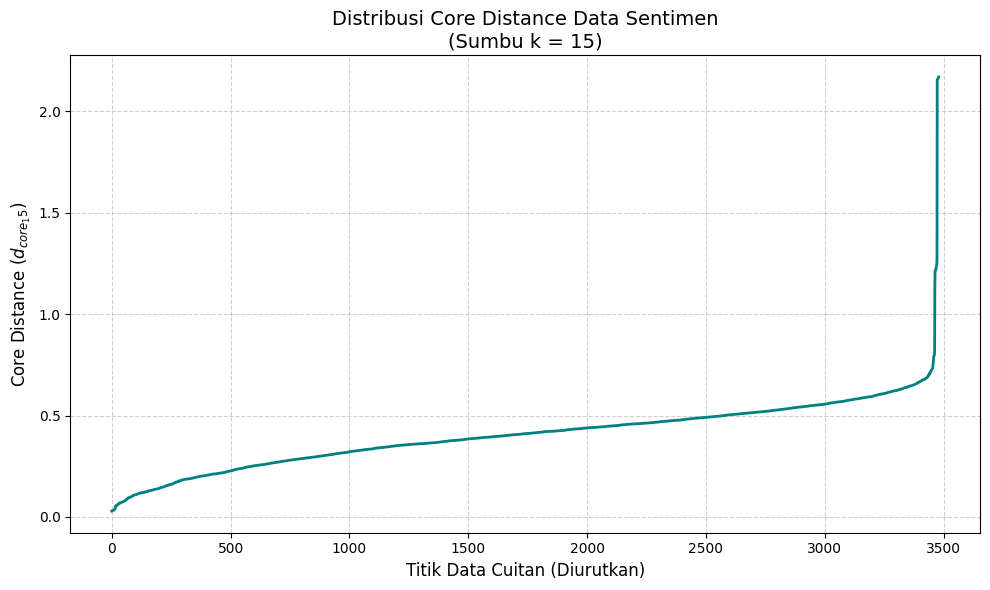

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# 1. Transformasi embedding asli melewati UMAP
# Karena HDBSCAN menghitung jarak dari output UMAP, bukan dari raw embedding
umap_embeddings_neg_hdbscan = topic_model_neg_hdbscan.umap_model.transform(embeddings_neg)

# 2. Definisikan nilai K sesuai dengan min_samples di konfigurasi Anda
# Asumsi parameter ini tersimpan di dictionary PARAMS_POS_HDB
k = PARAMS_NEG_HDB['min_samples']

# 3. Hitung jarak titik ke tetangga menggunakan metrik Euclidean
nn = NearestNeighbors(n_neighbors=k, metric='euclidean')
nn.fit(umap_embeddings_neg_hdbscan)
distances, indices = nn.kneighbors(umap_embeddings_neg_hdbscan)

# 4. Ambil jarak ke tetangga yang ke-K (Core Distance) dan urutkan
# Jarak ke tetangga ke-K berada di kolom terakhir dari matriks distances
core_distances = distances[:, -1]
core_distances_sorted = np.sort(core_distances)

# 5. Visualisasi K-Distance Plot
plt.figure(figsize=(10, 6))
plt.plot(core_distances_sorted, color='teal', linewidth=2)
plt.title(f"Distribusi Core Distance Data Sentimen\n(Sumbu k = {k})", fontsize=14)
plt.xlabel("Titik Data Cuitan (Diurutkan)", fontsize=12)
plt.ylabel(f"Core Distance ($d_{{core_{k}}}$)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### WC

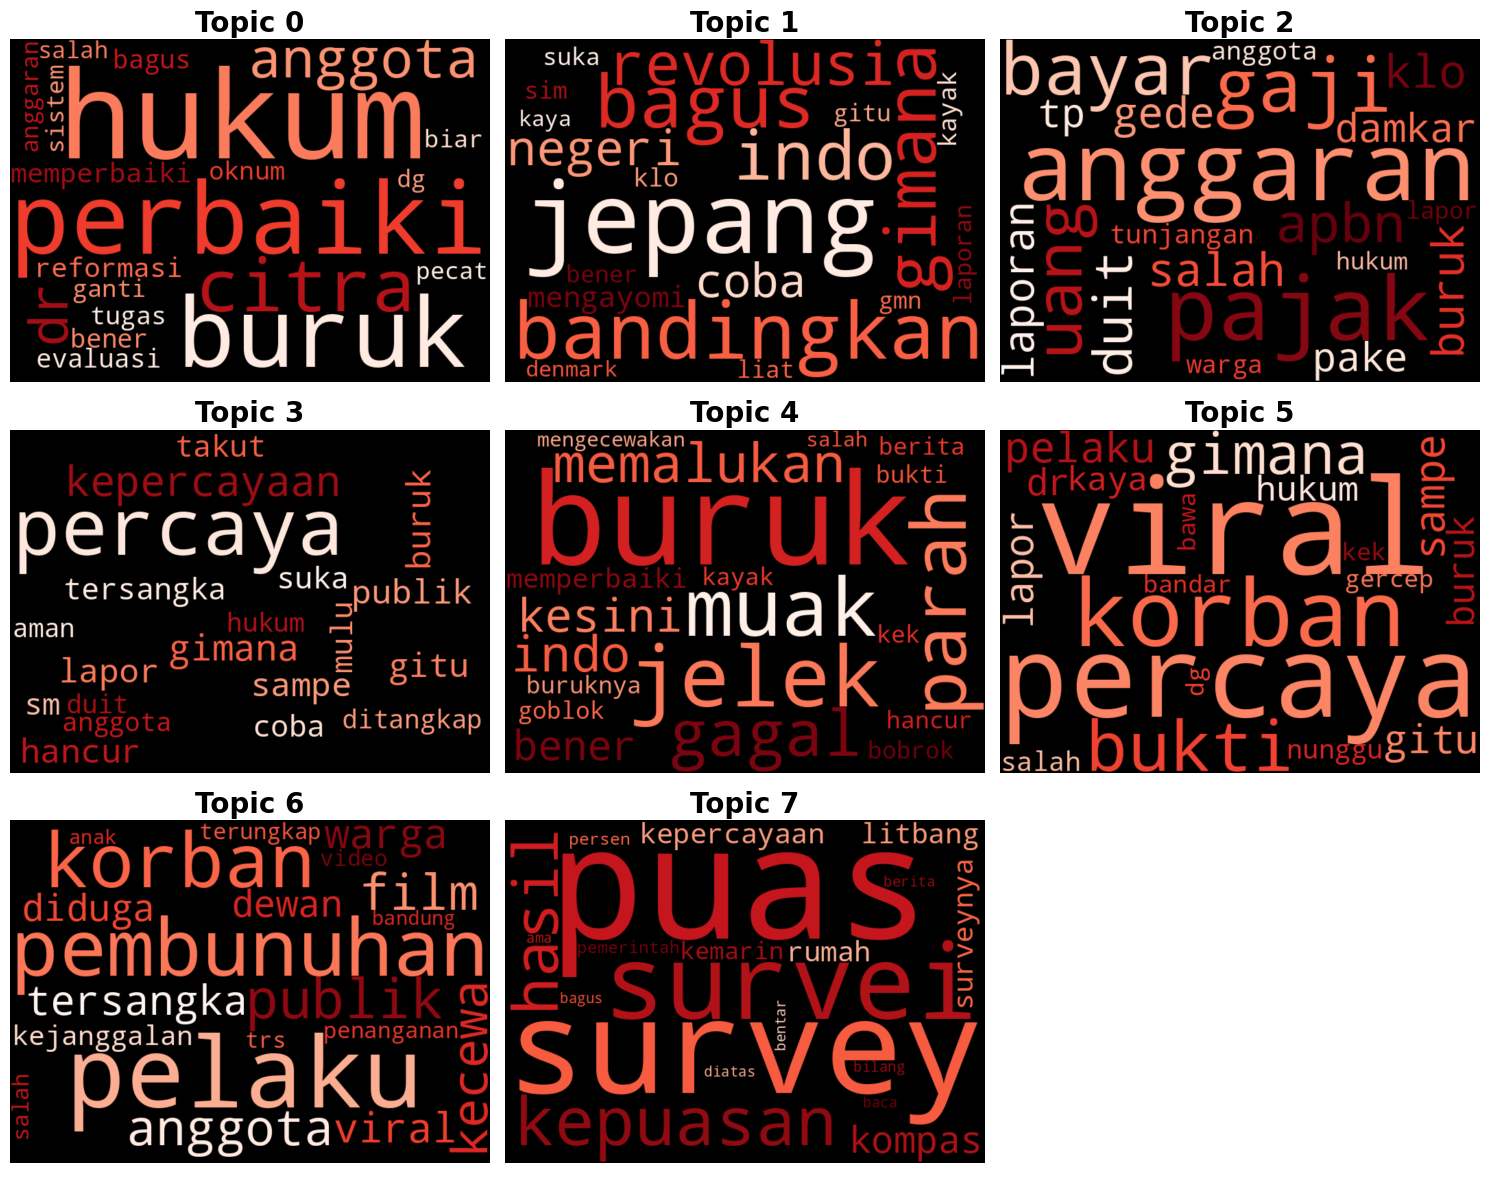

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import math

tm = topic_model_neg_hdbscan
docs = docs_neg
topics = topics_neg_hdb
n_words = 20

# CountVectorizer yang digunakan BERTopic
vectorizer = tm.vectorizer_model
vocab = vectorizer.get_feature_names_out()

# Daftar topik (tanpa outlier)
topic_info = tm.get_topic_info()
topic_ids = topic_info.loc[topic_info["Topic"] != -1, "Topic"].tolist()

n_cols = 3
n_rows = math.ceil(len(topic_ids) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)
fig.patch.set_facecolor("white")

if len(topic_ids) == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, tid in enumerate(topic_ids):

    axes[i].set_facecolor("white")

    topic_docs = [
        doc for doc, topic in zip(docs, topics)
        if topic == tid
    ]

    if len(topic_docs) == 0:
        axes[i].axis("off")
        continue
    X = vectorizer.transform(topic_docs)
    counts = X.sum(axis=0).A1

    freq = dict(zip(vocab, counts))

    freq = {k: v for k, v in freq.items() if v > 0}

    freq = dict(
        sorted(freq.items(), key=lambda x: x[1], reverse=True)[:n_words]
    )

    wc = WordCloud(
        width=700,
        height=500,
        background_color="black",
        colormap="Reds",
        max_words=n_words,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(freq)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(
        f"Topic {tid}",
        fontsize=20,
        fontweight="bold",
        color="black"
    )
    axes[i].axis("off")

for j in range(len(topic_ids), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

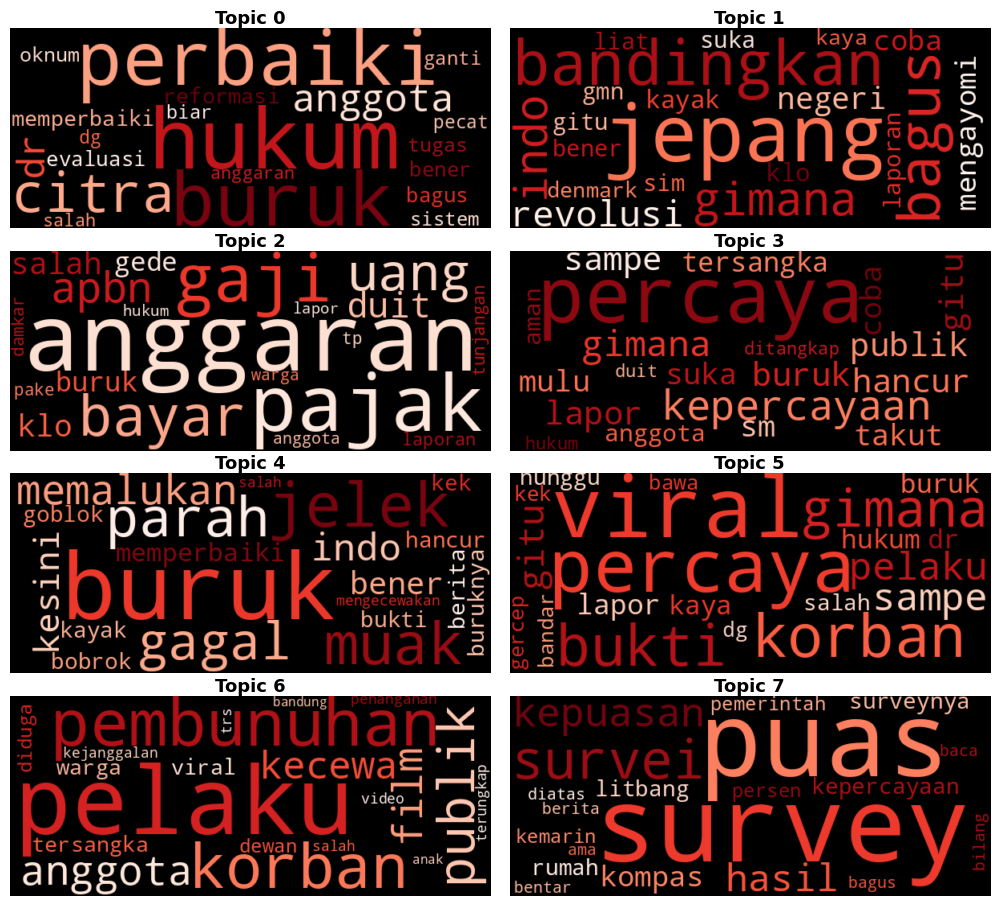

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math

tm = topic_model_neg_hdbscan
docs = docs_neg
topics = topics_neg_hdb
n_words = 20

vectorizer = tm.vectorizer_model
vocab = vectorizer.get_feature_names_out()

topic_info = tm.get_topic_info()
topic_ids = topic_info.loc[topic_info["Topic"] != -1, "Topic"].tolist()

n_cols = 2
n_rows = math.ceil(len(topic_ids) / n_cols)

fig = plt.figure(figsize=(10, 2.3 * n_rows), facecolor="white")
gs = gridspec.GridSpec(
    n_rows, n_cols,
    figure=fig,
    hspace=0.08,
    wspace=0.04,
    top=0.96,
    bottom=0.01,
    left=0.01,
    right=0.99
)

for i, tid in enumerate(topic_ids):
    row, col = divmod(i, n_cols)
    ax = fig.add_subplot(gs[row, col])
    ax.set_facecolor("black")

    topic_docs = [
        doc for doc, topic in zip(docs, topics)
        if topic == tid
    ]

    if len(topic_docs) == 0:
        ax.axis("off")
        continue

    X = vectorizer.transform(topic_docs)
    counts = X.sum(axis=0).A1
    freq = dict(zip(vocab, counts))
    freq = {k: v for k, v in freq.items() if v > 0}
    freq = dict(
        sorted(freq.items(), key=lambda x: x[1], reverse=True)[:n_words]
    )

    wc = WordCloud(
        width=600,
        height=250,
        background_color="black",
        colormap="Reds",
        max_words=n_words,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(freq)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(
        f"Topic {tid}",
        fontsize=13,
        fontweight="bold",
        color="black",
        pad=3
    )
    ax.axis("off")

plt.savefig(
    "wordcloud_pos_hdbscan.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

#### Hierarchy

<>:104: SyntaxWarning:

invalid escape sequence '\l'

<>:104: SyntaxWarning:

invalid escape sequence '\l'

/tmp/ipykernel_3580/755660235.py:104: SyntaxWarning:

invalid escape sequence '\l'



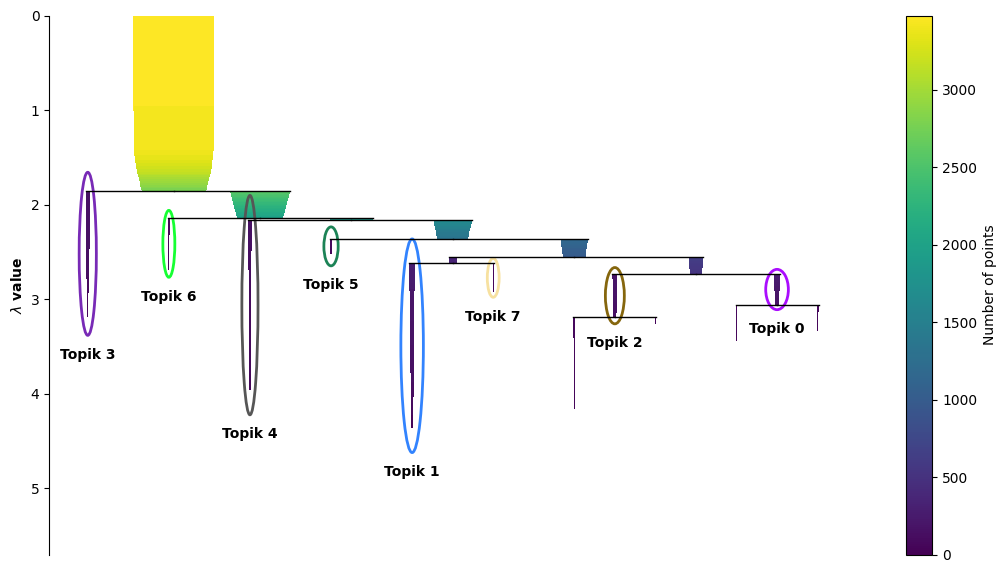

In [ ]:
import re
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import plotly.express as px

# 1. Ambil urutan warna resmi BERTopic {ID_Topik : Warna}
# PASTIKAN INI MEMANGGIL OBJEK NEGATIF (misal: topic_model_neg_hdbscan)
df_info = topic_model_neg_hdbscan.get_topic_info()
df_resmi = (
    df_info[df_info["Topic"] != -1].sort_values("Topic").reset_index(drop=True)
)
jumlah_resmi = len(df_resmi)

palet_raw = px.colors.qualitative.Alphabet + px.colors.qualitative.Set1
warna_resmi = (palet_raw * (jumlah_resmi // len(palet_raw) + 1))[
    :jumlah_resmi
]

map_warna_bertopic = dict(zip(df_resmi["Topic"], warna_resmi))

# 2. Buat jembatan pelacak: ID_HDBSCAN -> ID_BERTopic
hdb_labels = topic_model_neg_hdbscan.hdbscan_model.labels_
ber_labels = topic_model_neg_hdbscan.topics_

map_hdb_ke_ber = dict(zip(hdb_labels, ber_labels))

if -1 in map_hdb_ke_ber:
    del map_hdb_ke_ber[-1]


def konversi_ke_rgb(c):
    if str(c).startswith("rgb"):
        return tuple(int(x) / 255.0 for x in re.findall(r"\d+", str(c))[:3])
    return mcolors.to_rgb(c)


urutan_hdb = sorted(map_hdb_ke_ber.keys())
palet_hdbscan = [
    konversi_ke_rgb(map_warna_bertopic[map_hdb_ke_ber[h]]) for h in urutan_hdb
]

# 3. Gambar Condensed Tree
mesin_hdbscan = topic_model_neg_hdbscan.hdbscan_model

fig, ax = plt.subplots(figsize=(13, 7))

mesin_hdbscan.condensed_tree_.plot(
    select_clusters=True,
    label_clusters=False,
    selection_palette=palet_hdbscan,
    axis=ax,
)

# KUNCI 1: Paksa kamera melihat dari lambda 0 sampai lantai 5.7
ax.set_ylim(0, 5.7)
if not ax.yaxis_inverted():
    ax.invert_yaxis()

# --- 4. PEMBAJAKAN OBJEK OVAL (VERSI AUTO-CRASH DETECTOR) ---
ellipses = [p for p in ax.patches if isinstance(p, Ellipse)]

for i, el in enumerate(ellipses):
    if i < len(urutan_hdb):
        id_bertopic = map_hdb_ke_ber[urutan_hdb[i]]

        # A. Perbesar bunderan (Gunakan +65 konstan)
        el.set_width(el.width + 400)
        el.set_height(el.height * 1.08)

        cx, cy = el.center
        y_bawah = cy + (el.height / 2.0)

        # B. DETEKTOR TABRAKAN LANTAI
        # Jika pantat bunderan menembus atau mepet batas kanvas bawah (> 5.45)
        if y_bawah > 5.45:
            y_teks = cy - (el.height / 2.0)
            jarak_dorong = 9  # Dorong ke atas
            posisi_jangkar = "bottom"
        else:
            y_teks = y_bawah
            jarak_dorong = -9  # Dorong ke bawah
            posisi_jangkar = "top"

        ax.annotate(
            f"Topik {id_bertopic}",
            xy=(cx, y_teks),
            xytext=(0, jarak_dorong),
            textcoords="offset points",
            ha="center",
            va=posisi_jangkar,
            fontsize=10,
            fontweight="bold",
            color="#000000",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="none",
                alpha=0.85,
            ),
        )

# Kosmetik Final
ax.set_ylabel("$\lambda$ value", fontweight="bold")

plt.show()

#### Visualisasi

In [ ]:
# ── Helper: visualize documents BERTopic ──────────────────────────
def plot_bertopic_docs(tm, docs, embeddings, label):
    reduced = UMAP(
        n_neighbors=15, n_components=5,
        min_dist=0.05, metric='cosine',
        random_state=42, n_jobs=1
    ).fit_transform(embeddings)

    # Set label custom supaya legend cuma nampilin Topic ID, bukan nama topik
    topic_ids = [tid for tid in tm.get_topics().keys()]
    custom_labels = {tid: ("Outlier" if tid == -1 else str(tid)) for tid in topic_ids}
    tm.set_topic_labels(custom_labels)

    # Bangun palet warna sama seperti Intertopic Distance Map
    df_info = tm.get_topic_info()
    df_resmi = df_info[df_info["Topic"] != -1].sort_values("Topic").reset_index(drop=True)
    jumlah_resmi = len(df_resmi)

    palet_warna = px.colors.qualitative.Alphabet + px.colors.qualitative.Set1
    warna_resmi = (palet_warna * (jumlah_resmi // len(palet_warna) + 1))[:jumlah_resmi]

    map_warna = dict(zip(df_resmi["Topic"], warna_resmi))
    map_warna[-1] = "#808080"

    # Ganti warna khusus Topik 8 (sesuaikan warna hex sesukamu)
    if 8 in map_warna:
        map_warna[8] = "#FF00FF"

    fig = tm.visualize_documents(
        docs,
        reduced_embeddings=reduced,
        custom_labels=True,
        hide_annotations=True,
        title=label,
    )

    # Sesuaikan warna tiap trace topik dengan palet Intertopic Distance Map
    for trace in fig.data:
        tid_str = trace.name
        try:
            tid = -1 if tid_str == "Outlier" else int(tid_str)
        except (ValueError, TypeError):
            continue
        warna = map_warna.get(tid)
        if warna:
            trace.marker.color = warna
        # Pastikan Outlier ikut muncul di legend (kadang disembunyikan BERTopic secara default)
        trace.showlegend = True

    # Perbesar font legend
    fig.update_layout(
        legend=dict(font=dict(size=18)),
        font=dict(size=14),
    )

    fig.show()


plot_bertopic_docs(topic_model_neg_hdbscan, docs_neg, embeddings_neg, "Negatif — HDBSCAN")

#### CTFIDF

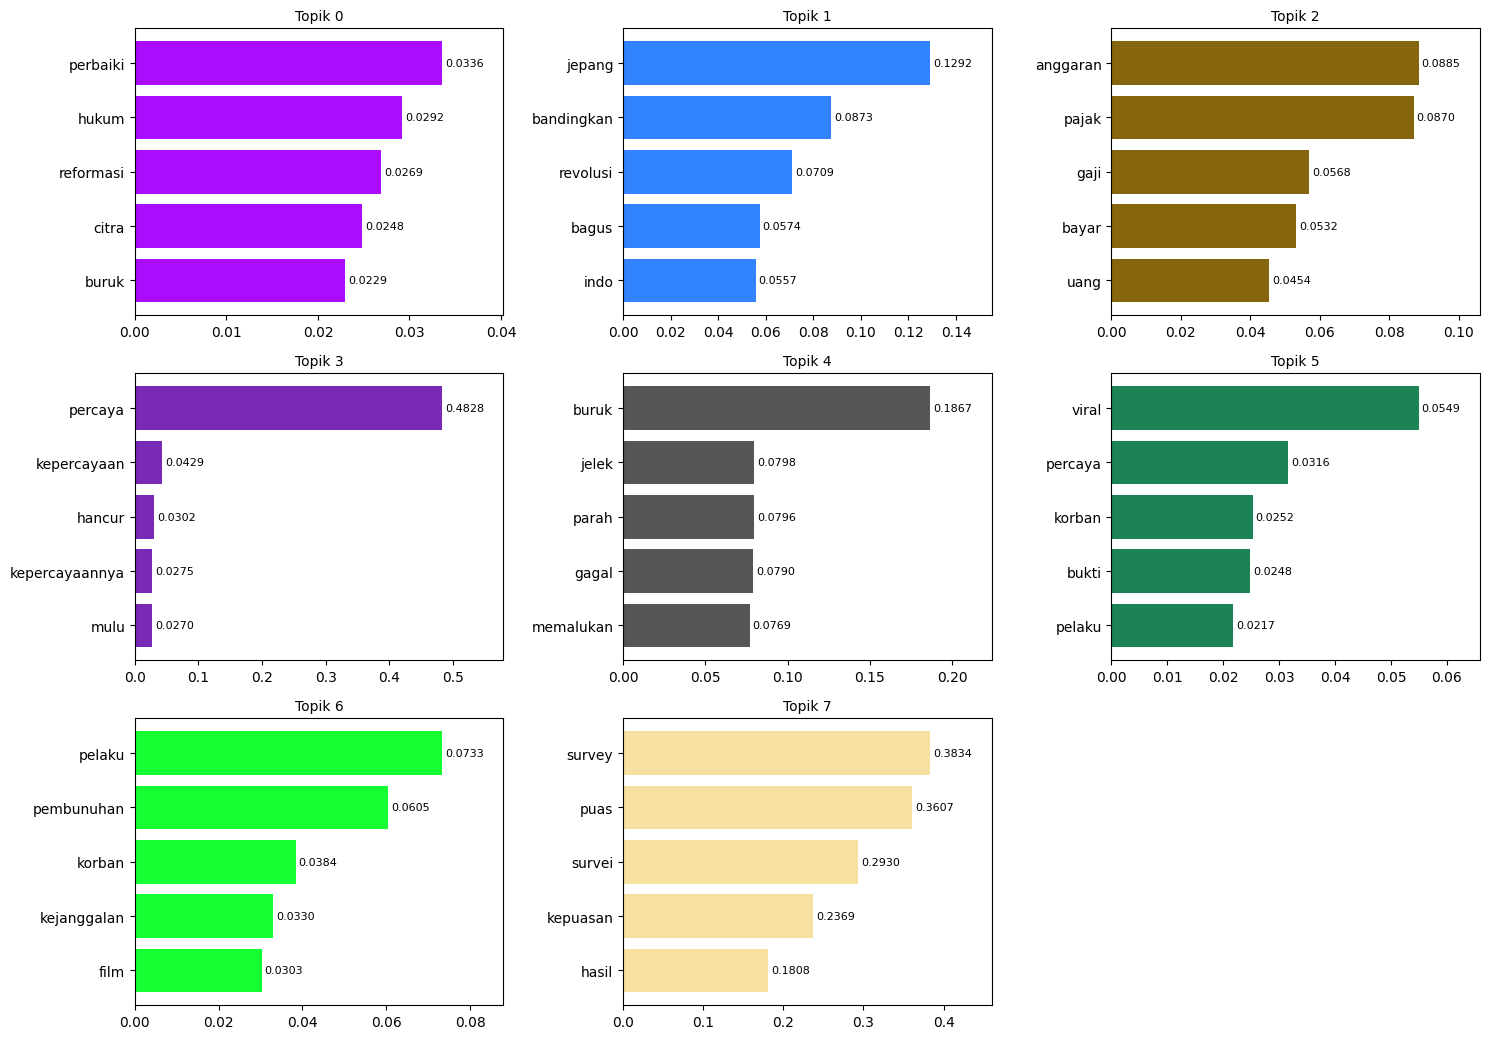

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px

# Ganti tm_hdb_pos sesuai model yang mau ditampilkan
topic_model = topic_model_neg_hdbscan
top_n = 5

# --- Bangun palet warna sama seperti Intertopic Distance Map ---
df_info = topic_model.get_topic_info()
df_resmi = df_info[df_info["Topic"] != -1].sort_values("Topic").reset_index(drop=True)
jumlah_resmi = len(df_resmi)

palet_warna = px.colors.qualitative.Alphabet + px.colors.qualitative.Set1
warna_resmi = (palet_warna * (jumlah_resmi // len(palet_warna) + 1))[:jumlah_resmi]

map_warna = dict(zip(df_resmi["Topic"], warna_resmi))
map_warna[-1] = "#808080"

# --- Barchart c-TF-IDF semua topik, warna mengikuti map_warna ---
topic_ids = [tid for tid in sorted(topic_model.get_topics().keys()) if tid != -1]
n = len(topic_ids)
ncols = 3
nrows = -(-n // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
axes = axes.flatten()

for ax, tid in zip(axes, topic_ids):
    words_scores = topic_model.get_topic(tid)[:top_n]
    words  = [w for w, _ in words_scores][::-1]
    scores = [s for _, s in words_scores][::-1]

    warna_topik = map_warna[tid]
    bars = ax.barh(words, scores, color=warna_topik)
    for bar, score in zip(bars, scores):
        ax.text(
            bar.get_width() + max(scores) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.4f}",
            va="center", ha="left", fontsize=8
        )
    ax.set_title(f"Topik {tid}", fontsize=10)
    ax.set_xlim(0, max(scores) * 1.2)

# Matikan axes kosong kalau jumlah topik tidak pas dengan grid
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("ctfidf_semua_topik.png", dpi=300, bbox_inches="tight")
plt.show()

### OPTICS Positif

In [ ]:
###

#### Intertopic Distance

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Ambil figure Intertopic Distance Map bawaan BERTopic
fig_map = topic_model_pos_optics.visualize_topics()

# 2. Ambil SELURUH data info topik (termasuk Outlier -1)
df_info = topic_model_pos_optics.get_topic_info()

# Pisahkan topik resmi khusus untuk menghitung palet warna peta kiri
df_resmi = (
    df_info[df_info["Topic"] != -1].sort_values("Topic").reset_index(drop=True)
)
jumlah_resmi = len(df_resmi)

# 3. Siapkan palet warna topik resmi
palet_warna = px.colors.qualitative.Alphabet + px.colors.qualitative.Set1
warna_resmi = (palet_warna * (jumlah_resmi // len(palet_warna) + 1))[
    :jumlah_resmi
]

# Kamus pemetaan warna {ID_Topik: Warna}. Khusus Topik -1 dikunci warna Abu-abu
map_warna = dict(zip(df_resmi["Topic"], warna_resmi))
map_warna[-1] = "#808080"

# 4. Buat kanvas 1 Baris, 2 Kolom
fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.55, 0.45],
    horizontal_spacing=0.08,
)

# 5. Pindahkan komponen peta Intertopic ke kolom kiri (col=1)
for trace in fig_map.data:
    fig.add_trace(trace, row=1, col=1)

# Suntikkan warna hanya ke marker lingkaran resmi
fig.data[0].marker.color = warna_resmi

# 6. Siapkan data Barchart Frekuensi (Semua topik ikut terangkut)
df_bar = df_info.sort_values("Count", ascending=True)
warna_bar = [map_warna[t] for t in df_bar["Topic"]]

# Ubah teks label "-1" menjadi "Outlier (-1)"
label_y = [
    "Outlier (-1)" if t == -1 else f"Topik {t}" for t in df_bar["Topic"]
]

trace_bar = go.Bar(
    x=df_bar["Count"],
    y=label_y,
    orientation="h",
    marker=dict(color=warna_bar),
    text=df_bar["Count"],
    textposition="auto",
    hoverinfo="x+y",
)
fig.add_trace(trace_bar, row=1, col=2)

# --- BAGIAN KUADRAN DI TENGAH PETA INTERTOPIC ---
x_coords = fig.data[0].x
y_coords = fig.data[0].y

tengah_x = (max(x_coords) + min(x_coords)) / 2
tengah_y = (max(y_coords) + min(y_coords)) / 2

# Garis Kuadran Vertikal
fig.add_shape(
    type="line",
    x0=tengah_x, x1=tengah_x,
    y0=min(y_coords), y1=max(y_coords),
    line=dict(color="lightgrey", width=1.5),
    row=1, col=1,
)

# Garis Kuadran Horizontal
fig.add_shape(
    type="line",
    x0=min(x_coords), x1=max(x_coords),
    y0=tengah_y, y1=tengah_y,
    line=dict(color="lightgrey", width=1.5),
    row=1, col=1,
)

# --- PENAMBAHAN TEKS D1, D2, D3, D4 DI POJOK UJUNG GARIS ---
font_kuadran = dict(size=13, color="#606060", family="Arial")

# Ujung Atas -> D1
fig.add_annotation(
    x=tengah_x, y=max(y_coords), text="<b>D1</b>",
    showarrow=False, xanchor="center", yanchor="bottom",
    yshift=8, font=font_kuadran, row=1, col=1
)

# Ujung Kiri -> D4
fig.add_annotation(
    x=min(x_coords), y=tengah_y, text="<b>D2</b>",
    showarrow=False, xanchor="right", yanchor="middle",
    xshift=-8, font=font_kuadran, row=1, col=1
)

# 7. Pengaturan Layout Umum
fig.update_layout(
    title_text="",
    height=600,
    width=1100,
    template="plotly_white",
    showlegend=False,
)

fig.update_xaxes(
    showgrid=False, zeroline=False, showticklabels=False, row=1, col=1
)
fig.update_yaxes(
    showgrid=False, zeroline=False, showticklabels=False, row=1, col=1
)

fig.update_xaxes(title_text="frequency", row=1, col=2)

fig.show()

#### WC

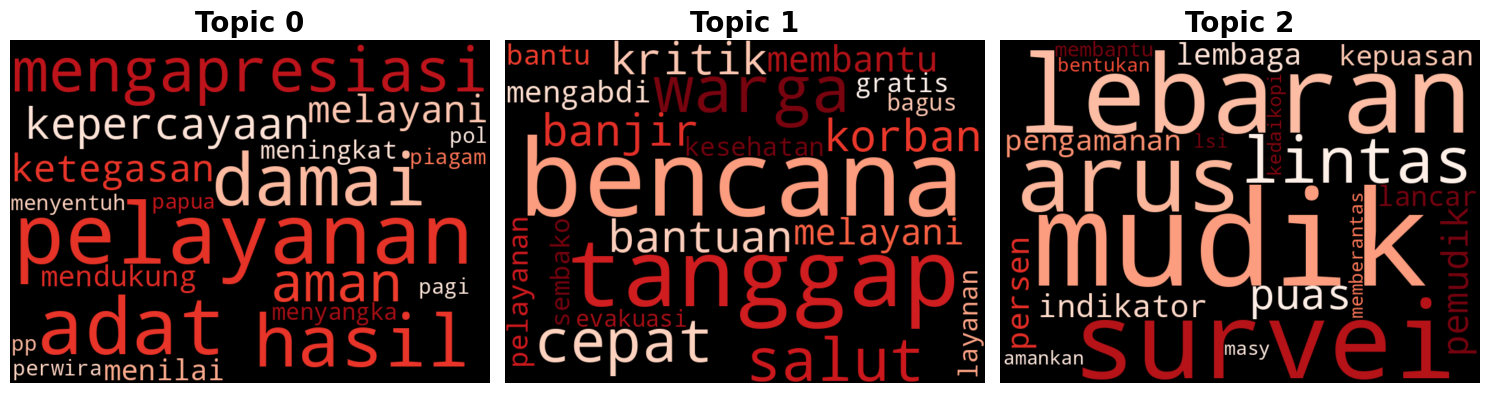

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import math

tm = topic_model_pos_optics
docs = docs_pos
topics = topics_pos_opt
n_words = 20

# CountVectorizer yang digunakan BERTopic
vectorizer = tm.vectorizer_model
vocab = vectorizer.get_feature_names_out()

# Daftar topik (tanpa outlier)
topic_info = tm.get_topic_info()
topic_ids = topic_info.loc[topic_info["Topic"] != -1, "Topic"].tolist()

n_cols = 3
n_rows = math.ceil(len(topic_ids) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)
fig.patch.set_facecolor("white")

if len(topic_ids) == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, tid in enumerate(topic_ids):

    axes[i].set_facecolor("white")

    # Ambil seluruh dokumen pada topik tersebut
    topic_docs = [
        doc for doc, topic in zip(docs, topics)
        if topic == tid
    ]

    if len(topic_docs) == 0:
        axes[i].axis("off")
        continue

    # Hitung frekuensi menggunakan CountVectorizer asli BERTopic
    X = vectorizer.transform(topic_docs)
    counts = X.sum(axis=0).A1

    # Dictionary kata -> frekuensi
    freq = dict(zip(vocab, counts))

    # Hapus kata dengan frekuensi 0
    freq = {k: v for k, v in freq.items() if v > 0}

    # Ambil n kata dengan frekuensi tertinggi
    freq = dict(
        sorted(freq.items(), key=lambda x: x[1], reverse=True)[:n_words]
    )

    wc = WordCloud(
        width=700,
        height=500,
        background_color="black",
        colormap="Reds",
        max_words=n_words,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(freq)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(
        f"Topic {tid}",
        fontsize=20,
        fontweight="bold",
        color="black"
    )
    axes[i].axis("off")

# Matikan subplot yang tidak terpakai
for j in range(len(topic_ids), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

#### Visualisasi

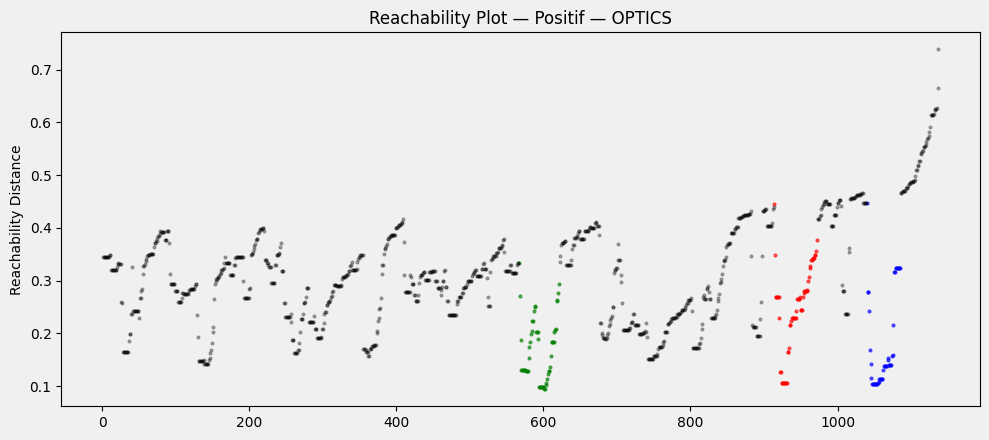

In [ ]:
from sklearn.cluster import OPTICS
import matplotlib.pyplot as plt
import numpy as np

def plot_optics_reachability(tm, label, eps_lines=()):
    clusterer = tm.hdbscan_model  # objek OPTICS tersimpan di sini

    space = np.arange(len(clusterer.reachability_))
    reachability = clusterer.reachability_[clusterer.ordering_]
    labels = clusterer.labels_[clusterer.ordering_]

    fig, ax = plt.subplots(figsize=(10, 4.5))

    # Warna solid khas per cluster (gaya sklearn OPTICS example)
    palette = ['g', 'r', 'b', 'k', 'y', 'c', 'm', 'darkorange', 'purple', 'brown']
    unique_labels = sorted(set(labels) - {-1})

    for klass, color in zip(unique_labels, palette * (len(unique_labels) // len(palette) + 1)):
        xk = space[labels == klass]
        rk = reachability[labels == klass]
        ax.plot(xk, rk, color=color, marker='.', linestyle='', alpha=0.6, markersize=4)

    # Outlier digambar terpisah, abu-abu
    xk_out = space[labels == -1]
    rk_out = reachability[labels == -1]
    ax.plot(xk_out, rk_out, 'k.', alpha=0.3, markersize=4)

    # Garis threshold epsilon (opsional, sesuaikan angkanya)
    for e in eps_lines:
        ax.axhline(e, color='gray', linewidth=1,
                   linestyle='-' if e == max(eps_lines) else '--')

    ax.set_ylabel('Reachability Distance')
    ax.set_title(f'Reachability Plot — {label}')

    fig.patch.set_facecolor('#f0f0f0')
    ax.set_facecolor('#f0f0f0')

    plt.tight_layout()
    plt.show()


plot_optics_reachability(topic_model_pos_optics, "Positif — OPTICS")

#### UMAP

In [ ]:
# ── Helper: visualize documents BERTopic ──────────────────────────
def plot_bertopic_docs(tm, docs, embeddings, label):
    reduced = UMAP(
        n_neighbors=15, n_components=5,
        min_dist=0.05, metric='cosine',
        random_state=42, n_jobs=1
    ).fit_transform(embeddings)

    # Set label custom supaya legend cuma nampilin Topic ID, bukan nama topik
    topic_ids = [tid for tid in tm.get_topics().keys()]
    custom_labels = {tid: ("Outlier" if tid == -1 else str(tid)) for tid in topic_ids}
    tm.set_topic_labels(custom_labels)

    # Bangun palet warna sama seperti Intertopic Distance Map
    df_info = tm.get_topic_info()
    df_resmi = df_info[df_info["Topic"] != -1].sort_values("Topic").reset_index(drop=True)
    jumlah_resmi = len(df_resmi)

    palet_warna = px.colors.qualitative.Alphabet + px.colors.qualitative.Set1
    warna_resmi = (palet_warna * (jumlah_resmi // len(palet_warna) + 1))[:jumlah_resmi]

    map_warna = dict(zip(df_resmi["Topic"], warna_resmi))
    map_warna[-1] = "#808080"

    # Ganti warna khusus Topik 8 (sesuaikan warna hex sesukamu)
    if 8 in map_warna:
        map_warna[8] = "#FF00FF"

    fig = tm.visualize_documents(
        docs,
        reduced_embeddings=reduced,
        custom_labels=True,
        hide_annotations=True,
        title=label,
    )

    # Sesuaikan warna tiap trace topik dengan palet Intertopic Distance Map
    for trace in fig.data:
        tid_str = trace.name
        try:
            tid = -1 if tid_str == "Outlier" else int(tid_str)
        except (ValueError, TypeError):
            continue
        warna = map_warna.get(tid)
        if warna:
            trace.marker.color = warna
        # Pastikan Outlier ikut muncul di legend (kadang disembunyikan BERTopic secara default)
        trace.showlegend = True

    # Perbesar font legend
    fig.update_layout(
        legend=dict(font=dict(size=18)),
        font=dict(size=14),
    )

    fig.show()


plot_bertopic_docs(topic_model_pos_optics, docs_pos, embeddings_pos, "Positif — OPTICS")

#### CTFIDF

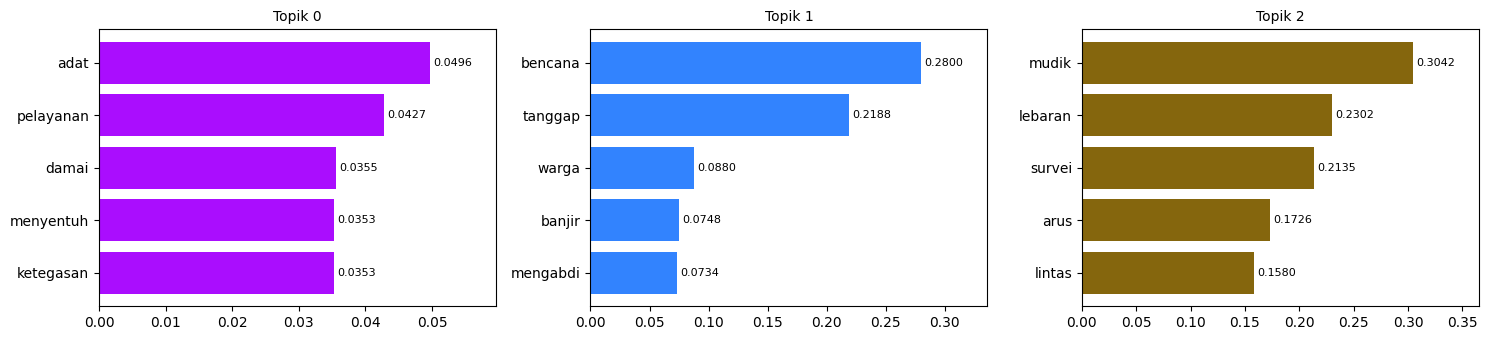

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px

# Ganti tm_hdb_pos sesuai model yang mau ditampilkan
topic_model = topic_model_pos_optics
top_n = 5

# --- Bangun palet warna sama seperti Intertopic Distance Map ---
df_info = topic_model.get_topic_info()
df_resmi = df_info[df_info["Topic"] != -1].sort_values("Topic").reset_index(drop=True)
jumlah_resmi = len(df_resmi)

palet_warna = px.colors.qualitative.Alphabet + px.colors.qualitative.Set1
warna_resmi = (palet_warna * (jumlah_resmi // len(palet_warna) + 1))[:jumlah_resmi]

map_warna = dict(zip(df_resmi["Topic"], warna_resmi))
map_warna[-1] = "#808080"

# --- Barchart c-TF-IDF semua topik, warna mengikuti map_warna ---
topic_ids = [tid for tid in sorted(topic_model.get_topics().keys()) if tid != -1]
n = len(topic_ids)
ncols = 3
nrows = -(-n // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
axes = axes.flatten()

for ax, tid in zip(axes, topic_ids):
    words_scores = topic_model.get_topic(tid)[:top_n]
    words  = [w for w, _ in words_scores][::-1]
    scores = [s for _, s in words_scores][::-1]

    warna_topik = map_warna[tid]
    bars = ax.barh(words, scores, color=warna_topik)
    for bar, score in zip(bars, scores):
        ax.text(
            bar.get_width() + max(scores) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.4f}",
            va="center", ha="left", fontsize=8
        )
    ax.set_title(f"Topik {tid}", fontsize=10)
    ax.set_xlim(0, max(scores) * 1.2)

# Matikan axes kosong kalau jumlah topik tidak pas dengan grid
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("ctfidf_semua_topik.png", dpi=300, bbox_inches="tight")
plt.show()

### OPTICS Negatif

#### Intertopic

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Ambil figure Intertopic Distance Map bawaan BERTopic
fig_map = topic_model_neg_optics.visualize_topics()

# 2. Ambil SELURUH data info topik (termasuk Outlier -1)
df_info = topic_model_neg_optics.get_topic_info()

# Pisahkan topik resmi khusus untuk menghitung palet warna peta kiri
df_resmi = (
    df_info[df_info["Topic"] != -1].sort_values("Topic").reset_index(drop=True)
)
jumlah_resmi = len(df_resmi)

# 3. Siapkan palet warna topik resmi
palet_warna = px.colors.qualitative.Alphabet + px.colors.qualitative.Set1
warna_resmi = (palet_warna * (jumlah_resmi // len(palet_warna) + 1))[
    :jumlah_resmi
]

# Kamus pemetaan warna {ID_Topik: Warna}. Khusus Topik -1 dikunci warna Abu-abu
map_warna = dict(zip(df_resmi["Topic"], warna_resmi))
map_warna[-1] = "#808080"

# 4. Buat kanvas 1 Baris, 2 Kolom
fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.55, 0.45],
    horizontal_spacing=0.08,
)

# 5. Pindahkan komponen peta Intertopic ke kolom kiri (col=1)
for trace in fig_map.data:
    fig.add_trace(trace, row=1, col=1)

# Suntikkan warna hanya ke marker lingkaran resmi
fig.data[0].marker.color = warna_resmi

# 6. Siapkan data Barchart Frekuensi (Semua topik ikut terangkut)
df_bar = df_info.sort_values("Count", ascending=True)
warna_bar = [map_warna[t] for t in df_bar["Topic"]]

# Ubah teks label "-1" menjadi "Outlier (-1)"
label_y = [
    "Outlier (-1)" if t == -1 else f"Topik {t}" for t in df_bar["Topic"]
]

trace_bar = go.Bar(
    x=df_bar["Count"],
    y=label_y,
    orientation="h",
    marker=dict(color=warna_bar),
    text=df_bar["Count"],
    textposition="auto",
    hoverinfo="x+y",
)
fig.add_trace(trace_bar, row=1, col=2)

# --- BAGIAN KUADRAN DI TENGAH PETA INTERTOPIC ---
x_coords = fig.data[0].x
y_coords = fig.data[0].y

tengah_x = (max(x_coords) + min(x_coords)) / 2
tengah_y = (max(y_coords) + min(y_coords)) / 2

# Garis Kuadran Vertikal
fig.add_shape(
    type="line",
    x0=tengah_x, x1=tengah_x,
    y0=min(y_coords), y1=max(y_coords),
    line=dict(color="lightgrey", width=1.5),
    row=1, col=1,
)

# Garis Kuadran Horizontal
fig.add_shape(
    type="line",
    x0=min(x_coords), x1=max(x_coords),
    y0=tengah_y, y1=tengah_y,
    line=dict(color="lightgrey", width=1.5),
    row=1, col=1,
)

# --- PENAMBAHAN TEKS D1, D2, D3, D4 DI POJOK UJUNG GARIS ---
font_kuadran = dict(size=13, color="#606060", family="Arial")

# Ujung Atas -> D1
fig.add_annotation(
    x=tengah_x, y=max(y_coords), text="<b>D1</b>",
    showarrow=False, xanchor="center", yanchor="bottom",
    yshift=8, font=font_kuadran, row=1, col=1
)

# Ujung Kiri -> D4
fig.add_annotation(
    x=min(x_coords), y=tengah_y, text="<b>D2</b>",
    showarrow=False, xanchor="right", yanchor="middle",
    xshift=-8, font=font_kuadran, row=1, col=1
)

# 7. Pengaturan Layout Umum
fig.update_layout(
    title_text="",
    height=600,
    width=1100,
    template="plotly_white",
    showlegend=False,
)

fig.update_xaxes(
    showgrid=False, zeroline=False, showticklabels=False, row=1, col=1
)
fig.update_yaxes(
    showgrid=False, zeroline=False, showticklabels=False, row=1, col=1
)

fig.update_xaxes(title_text="frequency", row=1, col=2)

fig.show()

#### WC

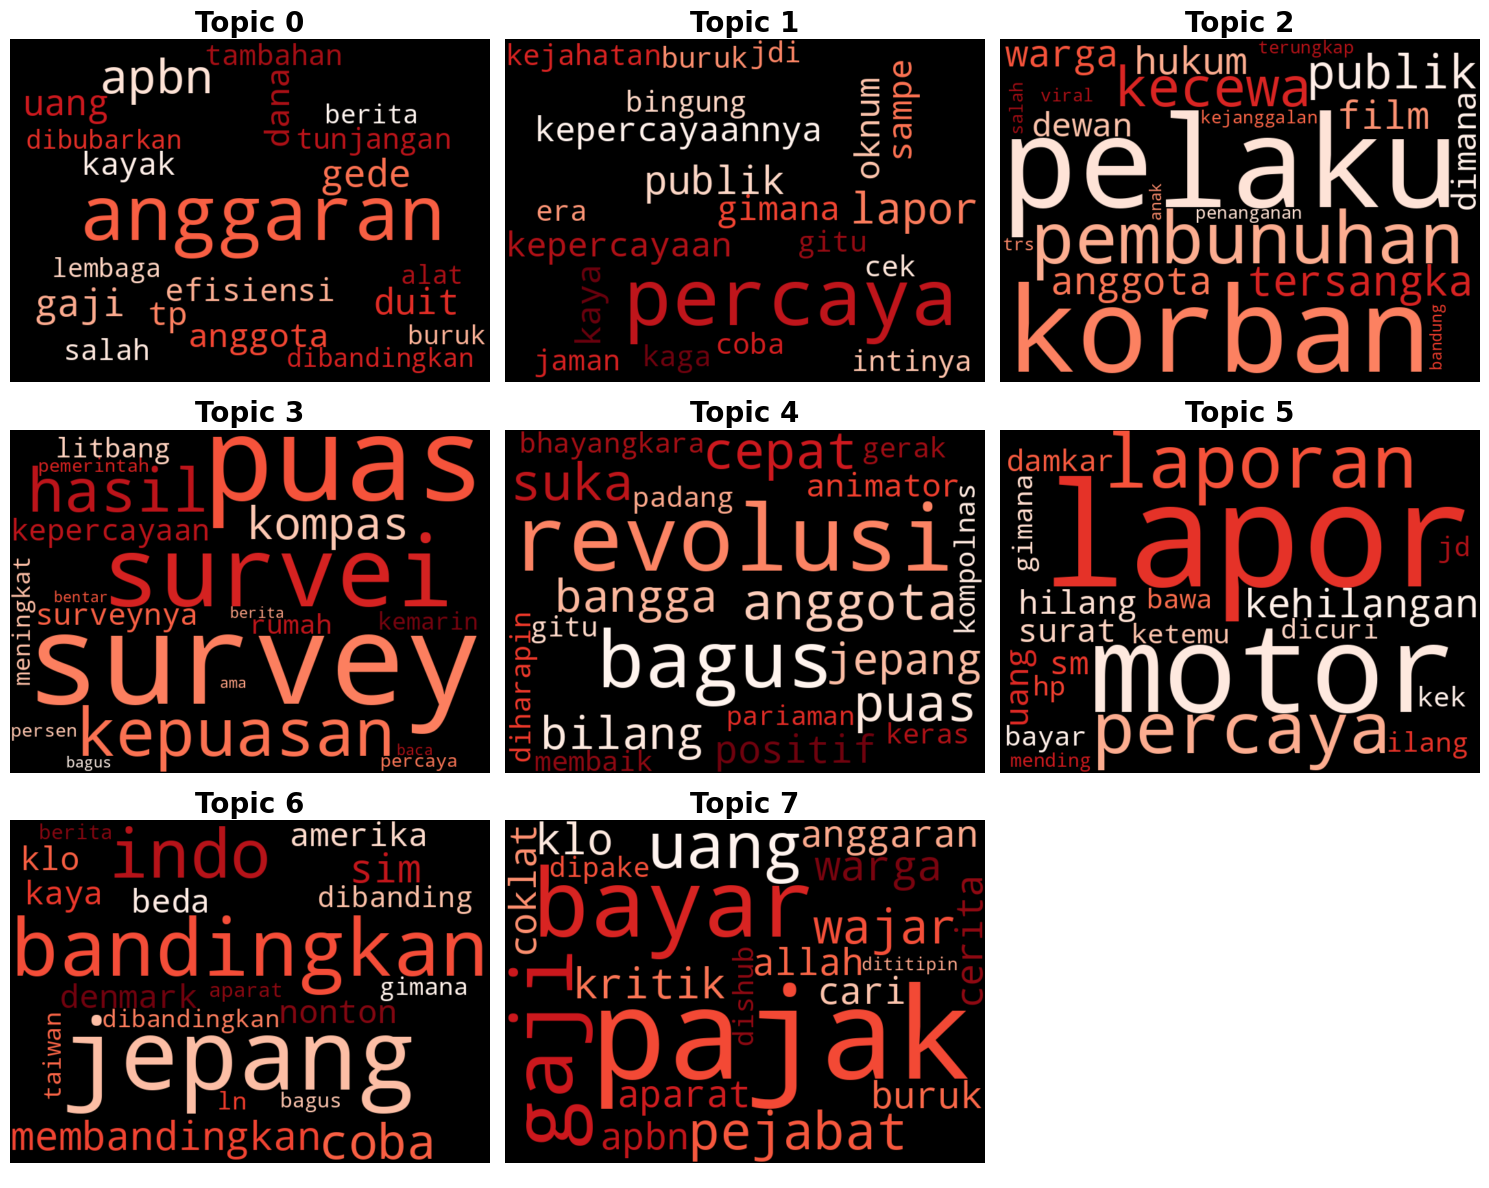

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import math

tm = topic_model_neg_optics
docs = docs_neg
topics = topics_neg_opt
n_words = 20

# CountVectorizer yang digunakan BERTopic
vectorizer = tm.vectorizer_model
vocab = vectorizer.get_feature_names_out()

# Daftar topik (tanpa outlier)
topic_info = tm.get_topic_info()
topic_ids = topic_info.loc[topic_info["Topic"] != -1, "Topic"].tolist()

n_cols = 3
n_rows = math.ceil(len(topic_ids) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)
fig.patch.set_facecolor("white")

if len(topic_ids) == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, tid in enumerate(topic_ids):

    axes[i].set_facecolor("white")

    # Ambil seluruh dokumen pada topik tersebut
    topic_docs = [
        doc for doc, topic in zip(docs, topics)
        if topic == tid
    ]

    if len(topic_docs) == 0:
        axes[i].axis("off")
        continue

    # Hitung frekuensi menggunakan CountVectorizer asli BERTopic
    X = vectorizer.transform(topic_docs)
    counts = X.sum(axis=0).A1

    # Dictionary kata -> frekuensi
    freq = dict(zip(vocab, counts))

    # Hapus kata dengan frekuensi 0
    freq = {k: v for k, v in freq.items() if v > 0}

    # Ambil n kata dengan frekuensi tertinggi
    freq = dict(
        sorted(freq.items(), key=lambda x: x[1], reverse=True)[:n_words]
    )

    wc = WordCloud(
        width=700,
        height=500,
        background_color="black",
        colormap="Reds",
        max_words=n_words,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(freq)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(
        f"Topic {tid}",
        fontsize=20,
        fontweight="bold",
        color="black"
    )
    axes[i].axis("off")

# Matikan subplot yang tidak terpakai
for j in range(len(topic_ids), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

#### Visualisasi

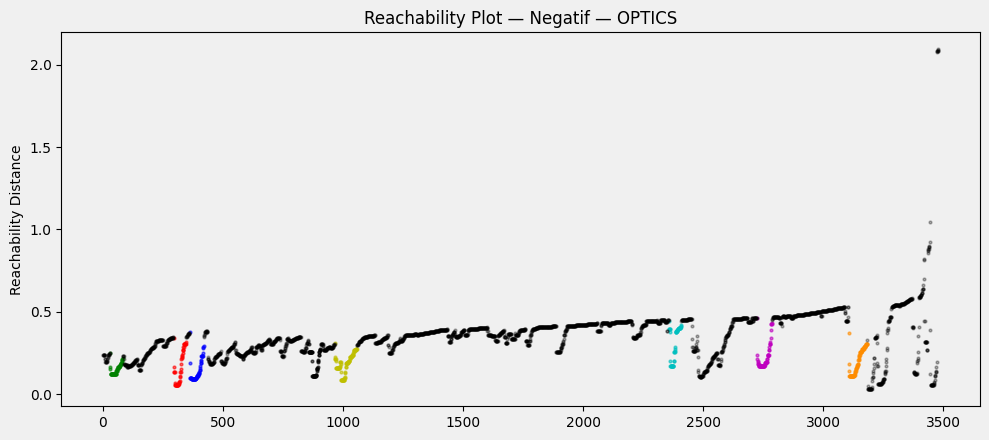

In [ ]:
plot_optics_reachability(topic_model_neg_optics, "Negatif — OPTICS")

#### UMAP

> Add blockquote



In [ ]:
# ── Helper: visualize documents BERTopic ──────────────────────────
def plot_bertopic_docs(tm, docs, embeddings, label):
    reduced = UMAP(
        n_neighbors=15, n_components=5,
        min_dist=0.05, metric='cosine',
        random_state=42, n_jobs=1
    ).fit_transform(embeddings)

    # Set label custom supaya legend cuma nampilin Topic ID, bukan nama topik
    topic_ids = [tid for tid in tm.get_topics().keys()]
    custom_labels = {tid: ("Outlier" if tid == -1 else str(tid)) for tid in topic_ids}
    tm.set_topic_labels(custom_labels)

    # Bangun palet warna sama seperti Intertopic Distance Map
    df_info = tm.get_topic_info()
    df_resmi = df_info[df_info["Topic"] != -1].sort_values("Topic").reset_index(drop=True)
    jumlah_resmi = len(df_resmi)

    palet_warna = px.colors.qualitative.Alphabet + px.colors.qualitative.Set1
    warna_resmi = (palet_warna * (jumlah_resmi // len(palet_warna) + 1))[:jumlah_resmi]

    map_warna = dict(zip(df_resmi["Topic"], warna_resmi))
    map_warna[-1] = "#808080"

    # Ganti warna khusus Topik 8 (sesuaikan warna hex sesukamu)
    if 8 in map_warna:
        map_warna[8] = "#FF00FF"

    fig = tm.visualize_documents(
        docs,
        reduced_embeddings=reduced,
        custom_labels=True,
        hide_annotations=True,
        title=label,
    )

    # Sesuaikan warna tiap trace topik dengan palet Intertopic Distance Map
    for trace in fig.data:
        tid_str = trace.name
        try:
            tid = -1 if tid_str == "Outlier" else int(tid_str)
        except (ValueError, TypeError):
            continue
        warna = map_warna.get(tid)
        if warna:
            trace.marker.color = warna
        # Pastikan Outlier ikut muncul di legend (kadang disembunyikan BERTopic secara default)
        trace.showlegend = True

    # Perbesar font legend
    fig.update_layout(
        legend=dict(font=dict(size=18)),
        font=dict(size=14),
    )

    fig.show()


plot_bertopic_docs(topic_model_neg_optics, docs_neg, embeddings_neg, "Negatif — OPTICS")

#### CTFIDF

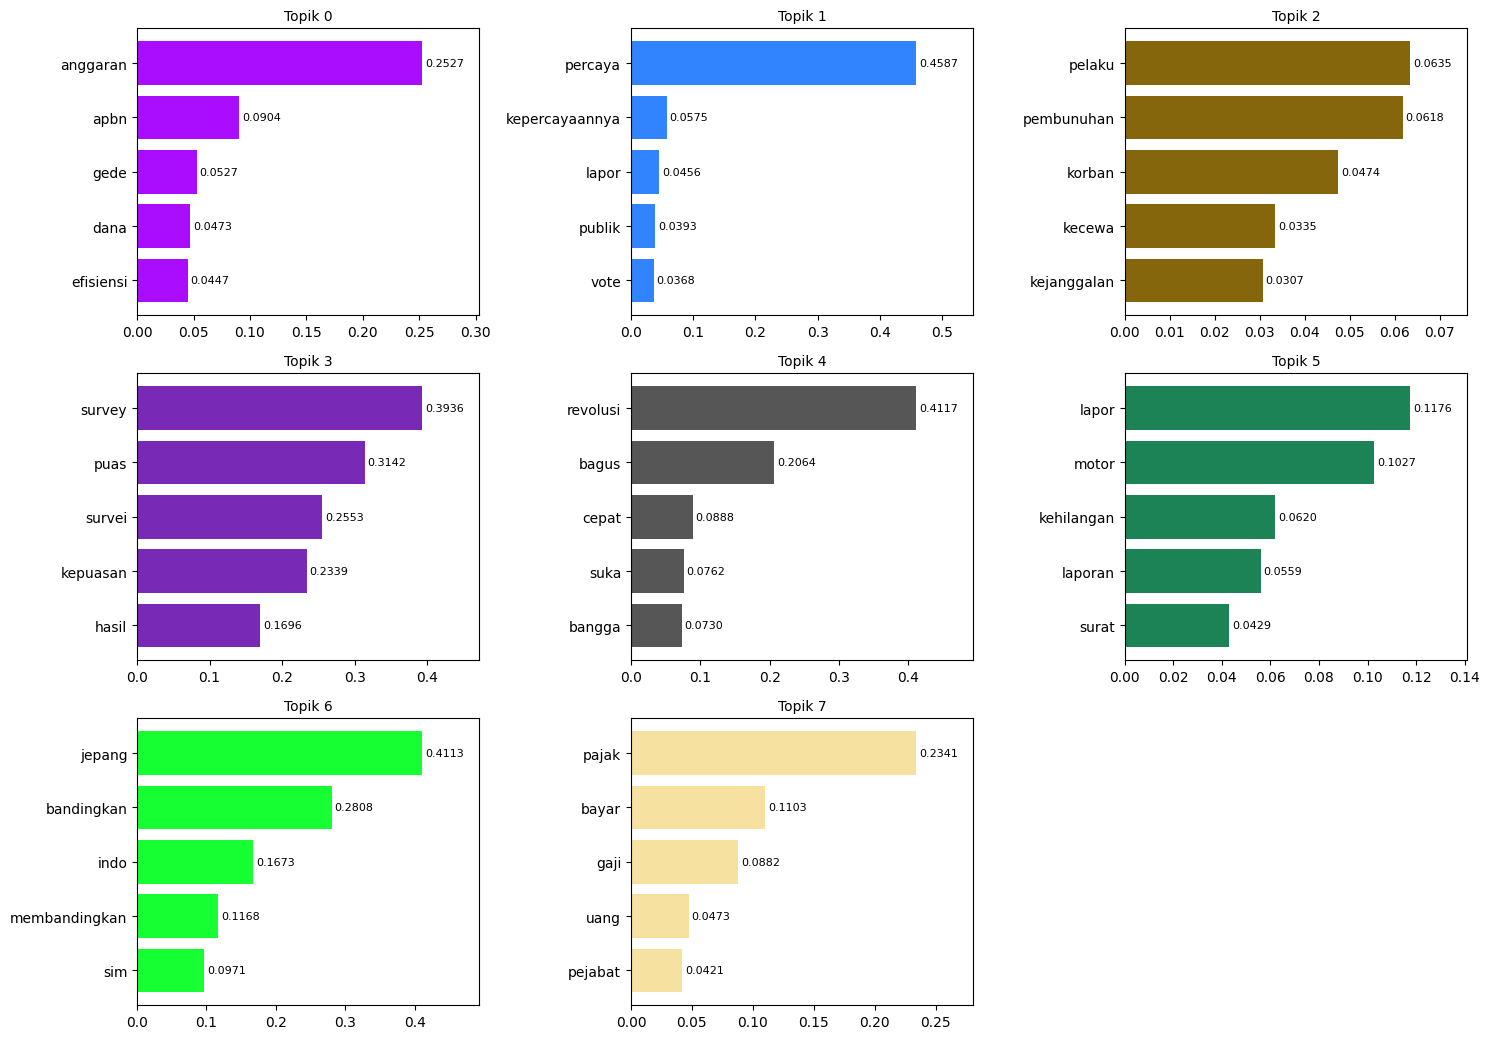

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px

# Ganti tm_hdb_pos sesuai model yang mau ditampilkan
topic_model = topic_model_neg_optics
top_n = 5

# --- Bangun palet warna sama seperti Intertopic Distance Map ---
df_info = topic_model.get_topic_info()
df_resmi = df_info[df_info["Topic"] != -1].sort_values("Topic").reset_index(drop=True)
jumlah_resmi = len(df_resmi)

palet_warna = px.colors.qualitative.Alphabet + px.colors.qualitative.Set1
warna_resmi = (palet_warna * (jumlah_resmi // len(palet_warna) + 1))[:jumlah_resmi]

map_warna = dict(zip(df_resmi["Topic"], warna_resmi))
map_warna[-1] = "#808080"

# --- Barchart c-TF-IDF semua topik, warna mengikuti map_warna ---
topic_ids = [tid for tid in sorted(topic_model.get_topics().keys()) if tid != -1]
n = len(topic_ids)
ncols = 3
nrows = -(-n // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
axes = axes.flatten()

for ax, tid in zip(axes, topic_ids):
    words_scores = topic_model.get_topic(tid)[:top_n]
    words  = [w for w, _ in words_scores][::-1]
    scores = [s for _, s in words_scores][::-1]

    warna_topik = map_warna[tid]
    bars = ax.barh(words, scores, color=warna_topik)
    for bar, score in zip(bars, scores):
        ax.text(
            bar.get_width() + max(scores) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.4f}",
            va="center", ha="left", fontsize=8
        )
    ax.set_title(f"Topik {tid}", fontsize=10)
    ax.set_xlim(0, max(scores) * 1.2)

# Matikan axes kosong kalau jumlah topik tidak pas dengan grid
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("ctfidf_semua_topik.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Simpan Model & Hasil Evaluasi

In [ ]:
from pathlib import Path

SAVE_DIR = Path('/content/drive/MyDrive/Tugas Akhir/bertopic')

SAVE_DIR.mkdir(parents=True, exist_ok=True)

topic_model_pos_hdbscan.save(
    str(SAVE_DIR / 'pos_hdbscan'),
    serialization='safetensors',
    save_ctfidf=True
)

topic_model_pos_optics.save(
    str(SAVE_DIR / 'pos_optics'),
    serialization='safetensors',
    save_ctfidf=True
)

topic_model_neg_hdbscan.save(
    str(SAVE_DIR / 'neg_hdbscan'),
    serialization='safetensors',
    save_ctfidf=True
)

topic_model_neg_optics.save(
    str(SAVE_DIR / 'neg_optics'),
    serialization='safetensors',
    save_ctfidf=True
)

eval_df.to_excel(
    SAVE_DIR / 'evaluation_results.xlsx',
    index=False
)

print('Model dan evaluasi tersimpan di:', SAVE_DIR)

In [ ]:
import pandas as pd
from pathlib import Path

SAVE_DIR = Path('/content/drive/MyDrive/Tugas Akhir/bertopic')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

output_file = SAVE_DIR / "topic_info_bertopic.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    topic_model_pos_hdbscan.get_topic_info().to_excel(
        writer,
        sheet_name="Pos_HDBSCAN",
        index=False
    )

    topic_model_pos_optics.get_topic_info().to_excel(
        writer,
        sheet_name="Pos_OPTICS",
        index=False
    )

    topic_model_neg_hdbscan.get_topic_info().to_excel(
        writer,
        sheet_name="Neg_HDBSCAN",
        index=False
    )

    topic_model_neg_optics.get_topic_info().to_excel(
        writer,
        sheet_name="Neg_OPTICS",
        index=False
    )

print(f"Berhasil disimpan ke: {output_file}")

In [ ]:
!pip install xlsxwriter

In [ ]:
import pandas as pd

# --- Cek dulu urutan & panjangnya cocok, biar gak salah mapping ---
assert len(data_pos) == len(topics_pos_hdb) == len(topics_pos_opt), \
    "Panjang df_pos gak cocok sama topics_pos_* — cek urutan/filtering docs_pos"
assert len(data_neg) == len(topics_neg_hdb) == len(topics_neg_opt), \
    "Panjang df_neg gak cocok sama topics_neg_* — cek urutan/filtering docs_neg"

def build_result_df(df_source, topics, topic_model=None):
    out = df_source[['id_str', 'created_at', 'text']].copy().reset_index(drop=True)
    out['topic_id'] = topics

    if topic_model is not None:
        info = topic_model.get_topic_info().set_index('Topic')['Name']
        out['topic_name'] = out['topic_id'].map(info)

    return out

df_hdbscan_pos = build_result_df(data_pos, topics_pos_hdb, topic_model_pos_hdbscan)
df_hdbscan_neg = build_result_df(data_neg, topics_neg_hdb, topic_model_neg_hdbscan)
df_optics_pos  = build_result_df(data_pos, topics_pos_opt, topic_model_pos_optics)
df_optics_neg  = build_result_df(data_neg, topics_neg_opt, topic_model_neg_optics)

with pd.ExcelWriter('/content/drive/MyDrive/Tugas Akhir/bertopic/hasil_topic_modeling.xlsx', engine='xlsxwriter') as writer:
    df_hdbscan_pos.to_excel(writer, sheet_name='hdbscan-pos', index=False)
    df_hdbscan_neg.to_excel(writer, sheet_name='hdbscan-neg', index=False)
    df_optics_pos.to_excel(writer, sheet_name='optics-pos', index=False)
    df_optics_neg.to_excel(writer, sheet_name='optics-neg', index=False)

print("Tersimpan: /content/hasil_topic_modeling.xlsx")

In [ ]:
import pandas as pd

for name, val in list(globals().items()):
    if isinstance(val, pd.DataFrame):
        print(f"{name:25s} shape={val.shape}  columns={list(val.columns)}")

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# CONTOH PERHITUNGAN UMAP (HASIL INTERNAL UMAP)
# ============================================================

# -------------------------------
# Ambil model UMAP dari BERTopic
# -------------------------------
umap_model = topic_model_pos_hdbscan.umap_model

# -------------------------------
# Pilih satu dokumen contoh
# -------------------------------
doc_idx = 0

print("="*80)
print("DOKUMEN CONTOH")
print("="*80)
print(docs_pos[doc_idx])

# ============================================================
# EMBEDDING AWAL
# ============================================================

embedding_awal = embeddings_pos[doc_idx]

print("\nDimensi embedding :", embedding_awal.shape)

print("\n10 nilai pertama")
print(np.round(embedding_awal[:10],6))

print("\n10 nilai terakhir")
print(np.round(embedding_awal[-10:],6))

# ============================================================
# NEAREST NEIGHBOR
# ============================================================

neighbors = umap_model.knn_indices[doc_idx]
distances = umap_model.knn_dists[doc_idx]

df_neighbor = pd.DataFrame({
    "Rank": np.arange(1,len(neighbors)+1),
    "Neighbor Document": neighbors,
    "Cosine Distance": distances
})

print("\n")
print("="*80)
print("15 NEAREST NEIGHBOR")
print("="*80)
display(df_neighbor)

# ============================================================
# RHO
# ============================================================

rho = umap_model._rhos[doc_idx]

print("\n")
print("="*80)
print("RHO")
print("="*80)
print(rho)

# ============================================================
# SIGMA
# ============================================================

sigma = umap_model._sigmas[doc_idx]

print("\n")
print("="*80)
print("SIGMA")
print("="*80)
print(sigma)

# ============================================================
# MEMBERSHIP p(i,j)
# ============================================================

membership = np.exp(
    -(np.maximum(0, distances-rho))/sigma
)

df_neighbor["Membership p(i,j)"] = membership

print("\n")
print("="*80)
print("FUZZY MEMBERSHIP")
print("="*80)
display(df_neighbor)

# ============================================================
# GRAPH (HASIL SIMETRISASI)
# ============================================================

row = umap_model.graph_[doc_idx]

graph_df = pd.DataFrame({
    "Neighbor Document": row.indices,
    "Symmetric Membership p_sym": row.data
})

print("\n")
print("="*80)
print("FUZZY GRAPH (SETELAH SIMETRISASI)")
print("="*80)
display(graph_df)

# ============================================================
# HASIL REDUKSI DIMENSI
# ============================================================

embedding_umap = umap_model.embedding_[doc_idx]

print("\n")
print("="*80)
print("HASIL REDUKSI DIMENSI (5 DIMENSI)")
print("="*80)
print(np.round(embedding_umap,6))

# ============================================================
# PARAMETER UMAP
# ============================================================

parameter_df = pd.DataFrame({
    "Parameter":[
        "n_neighbors",
        "min_dist",
        "metric",
        "n_components",
        "learning_rate",
        "negative_sample_rate",
        "a",
        "b"
    ],
    "Value":[
        umap_model.n_neighbors,
        umap_model.min_dist,
        umap_model.metric,
        umap_model.n_components,
        umap_model.learning_rate,
        umap_model.negative_sample_rate,
        umap_model.a,
        umap_model.b
    ]
})

print("\n")
print("="*80)
print("PARAMETER UMAP")
print("="*80)
display(parameter_df)

# ============================================================
# EXPORT EXCEL
# ============================================================

with pd.ExcelWriter("contoh_perhitungan_umap_internal.xlsx") as writer:

    pd.DataFrame({
        "Embedding": embedding_awal
    }).to_excel(
        writer,
        sheet_name="Embedding Awal",
        index=False
    )

    df_neighbor.to_excel(
        writer,
        sheet_name="Nearest Neighbor",
        index=False
    )

    graph_df.to_excel(
        writer,
        sheet_name="Fuzzy Graph",
        index=False
    )

    pd.DataFrame({
        "Embedding UMAP": embedding_umap
    }).to_excel(
        writer,
        sheet_name="Embedding 5D",
        index=False
    )

    parameter_df.to_excel(
        writer,
        sheet_name="Parameter",
        index=False
    )

print("\n")
print("="*80)
print("File berhasil disimpan:")
print("contoh_perhitungan_umap_internal.xlsx")
print("="*80)

In [ ]:
print(umap_model.knn_indices)
print(umap_model.knn_dists)

print(type(umap_model.graph_))
print(umap_model.graph_.shape)

print(umap_model._rhos.shape)
print(umap_model._sigmas.shape)

print(umap_model.embedding_.shape)

In [ ]:
row = umap_model.graph_[0]

print(type(row))
print(row.indices[:20])
print(row.data[:20])

In [ ]:
import numpy as np
from transformers import AutoTokenizer

# Load tokenizer ────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained('denaya/indoSBERT-large')

# ── Ambil satu contoh dokumen ─────────────────────────────────────────────
contoh_teks = docs_pos[32]

# ── Tokenisasi ────────────────────────────────────────────────────────────
encoded   = tokenizer(contoh_teks, truncation=True, return_tensors='pt')
tokens    = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])
token_ids = encoded['input_ids'][0].tolist()
attn_mask = encoded['attention_mask'][0].tolist()
n_token   = len(tokens)

# ── Sentence embedding ────────────────────────────────────────────────────
sentence_vec = embeddings_pos[0]  # shape (768,)

# ── Simulasi token embedding N×256 ───────────────────────────────────────
np.random.seed(42)
emb = sentence_vec + np.random.normal(0, 0.01, (n_token, len(sentence_vec)))
emb = emb.astype(np.float32)

# ── Format matriks ────────────────────────────────────────────────────────
def f_val(val):
    return f"{val:9.6f}".replace('.', ',')

mat_str = (
    f"({f_val(emb[0,0])}  {f_val(emb[0,1])}  ⋯  {f_val(emb[0,-2])}  {f_val(emb[0,-1])} \n"
    f" {f_val(emb[1,0])}  {f_val(emb[1,1])}  ⋯  {f_val(emb[1,-2])}  {f_val(emb[1,-1])} \n"
    f"        ⋮                ⋮         ⋱         ⋮                ⋮       \n"
    f" {f_val(emb[-2,0])}  {f_val(emb[-2,1])}  ⋯  {f_val(emb[-2,-2])}  {f_val(emb[-2,-1])} \n"
    f" {f_val(emb[-1,0])}  {f_val(emb[-1,1])}  ⋯  {f_val(emb[-1,-2])}  {f_val(emb[-1,-1])} ) {n_token}×256"
)

# ── Ringkas helper ────────────────────────────────────────────────────────
MAX_SHOW = 6
def ringkas(lst):
    if len(lst) <= MAX_SHOW * 2:
        return str(lst)
    head = str(lst[:MAX_SHOW])[:-1]
    tail = str(lst[-2:])[1:]
    return f"{head}, ..., {tail}"

vec_preview = sentence_vec[:4].tolist() + ['...'] + sentence_vec[-2:].tolist()
vec_str = '[' + ', '.join(f'{v:.6f}' if isinstance(v, float) else str(v) for v in vec_preview) + f']  1×{sentence_vec.shape[0]}'

# ── Susun tabel ───────────────────────────────────────────────────────────
rows = [
    ('Preprocessed post',    contoh_teks),
    ('Tokenisasi',           ringkas(tokens)),
    ('Token ID',             ringkas(token_ids) + f'  1×{n_token}'),
    ('Attention Mask',       ringkas(attn_mask) + f'  1×{n_token}'),
    ('Token Embedding',      mat_str),
    ('Mean Pooling (1×768)', vec_str),
]

df_display = pd.DataFrame(rows, columns=['Tahap', 'Hasil'])

display(df_display.style
    .set_properties(**{
        'text-align'  : 'left',
        'white-space' : 'pre-wrap',
        'max-width'   : '800px',
        'font-size'   : '12px',
        'font-family' : 'monospace',
    })
    .set_table_styles([{
        'selector': 'th',
        'props'   : [('text-align', 'left'), ('background-color', '#1F4E78'),
                     ('color', 'white'), ('font-size', '12px')]
    }])
    .hide(axis='index')
)

In [ ]:
import numpy as np

s0 = embeddings_pos[0]
s32 = embeddings_pos[32]

print("="*80)
print("5 DIMENSI PERTAMA")
print("="*80)

for i in range(5):
    print(
        f"({s0[i]: .6f}) × ({s32[i]: .6f}) = {s0[i]*s32[i]: .6f}"
    )

print("...")
print()

print("="*80)
print("5 DIMENSI TERAKHIR")
print("="*80)

for i in range(len(s0)-5, len(s0)):
    print(
        f"({s0[i]: .6f}) × ({s32[i]: .6f}) = {s0[i]*s32[i]: .6f}"
    )

dot = np.dot(s0, s32)
norm0 = np.linalg.norm(s0)
norm32 = np.linalg.norm(s32)

cos = dot/(norm0*norm32)
dist = 1-cos

print("\n")
print("="*80)
print("RINGKASAN")
print("="*80)
print(f"Dot Product       = {dot:.6f}")
print(f"||s0||            = {norm0:.6f}")
print(f"||s32||           = {norm32:.6f}")
print(f"Cosine Similarity = {cos:.6f}")
print(f"Cosine Distance   = {dist:.6f}")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

# ==========================================================
# CONTOH PERHITUNGAN UMAP
# ==========================================================

# -------------------------------
# Model UMAP
# -------------------------------
umap_model = topic_model_pos_hdbscan.umap_model

# -------------------------------
# Pilih dokumen contoh
# -------------------------------
doc_idx = 0

print("="*80)
print("DOKUMEN CONTOH")
print("="*80)
print(docs_pos[doc_idx])

# ==========================================================
# EMBEDDING AWAL
# ==========================================================

embedding_awal = embeddings_pos[doc_idx]

print("\nEmbedding shape :", embedding_awal.shape)

# ==========================================================
# KNN (REKONSTRUKSI)
# ==========================================================

K = umap_model.n_neighbors

nn = NearestNeighbors(
    n_neighbors=K+1,          # +1 karena dirinya sendiri ikut
    metric="cosine"
)

nn.fit(embeddings_pos)

distances, indices = nn.kneighbors(
    embedding_awal.reshape(1,-1)
)

distances = distances[0][1:]
indices = indices[0][1:]

df_knn = pd.DataFrame({
    "Rank": np.arange(1,K+1),
    "Neighbor": indices,
    "Cosine Distance": distances
})

print("\n")
print("="*80)
print("K NEAREST NEIGHBORS")
print("="*80)
display(df_knn)

# ==========================================================
# RHO
# ==========================================================

rho = umap_model._rhos[doc_idx]

print("\n")
print("="*80)
print("RHO")
print("="*80)
print(rho)

# ==========================================================
# SIGMA
# ==========================================================

sigma = umap_model._sigmas[doc_idx]

print("\n")
print("="*80)
print("SIGMA")
print("="*80)
print(sigma)

# ==========================================================
# MEMBERSHIP (Persamaan 2.36)
# ==========================================================

membership = np.exp(
    -(np.maximum(
        0,
        distances-rho
    ))/sigma
)

df_knn["Membership p(i,j)"] = membership

print("\n")
print("="*80)
print("MEMBERSHIP")
print("="*80)
display(df_knn)

# ==========================================================
# GRAPH (Persamaan 2.37)
# ==========================================================

row = umap_model.graph_[doc_idx]

graph_df = pd.DataFrame({
    "Neighbor": row.indices,
    "Symmetric Membership p_sym": row.data
})

print("\n")
print("="*80)
print("FUZZY GRAPH")
print("="*80)
display(graph_df)

# ==========================================================
# EMBEDDING HASIL UMAP
# ==========================================================

embedding5 = umap_model.embedding_[doc_idx]

embedding5_df = pd.DataFrame({
    "Dimension":[
        "UMAP1",
        "UMAP2",
        "UMAP3",
        "UMAP4",
        "UMAP5"
    ],
    "Value":embedding5
})

print("\n")
print("="*80)
print("HASIL REDUKSI DIMENSI")
print("="*80)
display(embedding5_df)

# ==========================================================
# PARAMETER
# ==========================================================

parameter_df = pd.DataFrame({
    "Parameter":[
        "n_neighbors",
        "metric",
        "min_dist",
        "n_components",
        "rho",
        "sigma",
        "a",
        "b"
    ],
    "Value":[
        umap_model.n_neighbors,
        umap_model.metric,
        umap_model.min_dist,
        umap_model.n_components,
        rho,
        sigma,
        umap_model.a,
        umap_model.b
    ]
})

print("\n")
print("="*80)
print("PARAMETER UMAP")
print("="*80)
display(parameter_df)

# ==========================================================
# EXPORT EXCEL
# ==========================================================

with pd.ExcelWriter("contoh_perhitungan_umap.xlsx") as writer:

    pd.DataFrame({
        "Embedding Awal (256D)":embedding_awal
    }).to_excel(
        writer,
        sheet_name="Embedding Awal",
        index=False
    )

    df_knn.to_excel(
        writer,
        sheet_name="Nearest Neighbor",
        index=False
    )

    graph_df.to_excel(
        writer,
        sheet_name="Fuzzy Graph",
        index=False
    )

    embedding5_df.to_excel(
        writer,
        sheet_name="Embedding 5D",
        index=False
    )

    parameter_df.to_excel(
        writer,
        sheet_name="Parameter",
        index=False
    )

print("\n")
print("="*80)
print("SELESAI")
print("File tersimpan : contoh_perhitungan_umap.xlsx")
print("="*80)

In [ ]:
print(docs_pos[32])